In [ ]:
# ============================================================================
# COMPREHENSIVE LANDSLIDE SUSCEPTIBILITY MODELING
# Master Notebook - All Models Implementation
#
# Models Included:
# - Frequency Ratio (FR)
# - Random Forest (RF)
# - Support Vector Machine (SVM)
# - Logistic Regression (LR)
# - XGBoost
# - LightGBM
# - Artificial Neural Network (ANN)
# - Deep Neural Network (DNN)
# - Convolutional Neural Network (CNN)
# - LSTM (Recurrent Neural Network)
# ============================================================================

"""
INSTRUCTIONS:
1. Ensure all data files are in: /content/drive/MyDrive/lsm/
2. Required files:
   - Training inventory.gpkg
   - Test inventory.gpkg
   - watershed_boundary.gpkg
   - Conditioning factor rasters (*.tif files)
3. Run all cells sequentially
4. Results will be saved in the same directory
"""

'\nINSTRUCTIONS:\n1. Ensure all data files are in: /content/drive/MyDrive/lsm/\n2. Required files:\n   - Training inventory.gpkg\n   - Test inventory.gpkg\n   - watershed_boundary.gpkg\n   - Conditioning factor rasters (*.tif files)\n3. Run all cells sequentially\n4. Results will be saved in the same directory\n'

In [ ]:
# ============================================================================
# SECTION 1: SETUP AND IMPORTS
# ============================================================================

print("="*70)
print(" LANDSLIDE SUSCEPTIBILITY MODELING - COMPREHENSIVE ANALYSIS")
print("="*70)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/lsm/"
print(f"\nData path: {data_path}")

# Install required packages
import subprocess
import sys
import warnings
warnings.filterwarnings('ignore')

def install_package(package):
    try:
        __import__(package.split('[')[0])
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

packages = ['rasterio', 'geopandas', 'scikit-learn', 'xgboost', 'lightgbm',
            'tensorflow', 'imbalanced-learn', 'seaborn', 'statsmodels']

print("\nInstalling required packages...")
for pkg in packages:
    install_package(pkg)

# Standard imports
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Geospatial
import rasterio
import geopandas as gpd
from shapely.geometry import Point

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten, Input, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

# Statistics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import LinearSegmentedColormap

print("✓ All libraries imported successfully!\n")

# Configuration
NODATA_VALUE = -9999
RANDOM_STATE = 42
TEST_SIZE = 0.3
CV_FOLDS = 5

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

CONDITIONING_FACTORS = [
    'soil', 'twi', 'elevation', 'slope', 'spi', 'aspect',
    'lithology', 'dist_road', 'lulc', 'dist_river',
    'plan_curvature', 'profile_curvature'
]

print(f"Configuration:")
print(f"  - Random State: {RANDOM_STATE}")
print(f"  - Test Size: {TEST_SIZE}")
print(f"  - CV Folds: {CV_FOLDS}")
print(f"  - Conditioning Factors: {len(CONDITIONING_FACTORS)}")

 LANDSLIDE SUSCEPTIBILITY MODELING - COMPREHENSIVE ANALYSIS
Mounted at /content/drive

Data path: /content/drive/MyDrive/lsm/

Installing required packages...
Installing scikit-learn...
Installing imbalanced-learn...
✓ All libraries imported successfully!

Configuration:
  - Random State: 42
  - Test Size: 0.3
  - CV Folds: 5
  - Conditioning Factors: 12


In [ ]:
# ============================================================================
# SECTION 2: DATA LOADING AND PREPROCESSING
# ============================================================================

print("\n" + "="*70)
print("DATA LOADING")
print("="*70)

# Load files
train_file = os.path.join(data_path, "Training inventory.gpkg")
test_file = os.path.join(data_path, "Test inventory.gpkg")
ws_file = os.path.join(data_path, "watershed_boundary.gpkg")

# Load rasters
raster_files = glob.glob(os.path.join(data_path, "*.tif"))
rasters = {}
for f in raster_files:
    name = os.path.basename(f).replace(".tif", "")
    if name in CONDITIONING_FACTORS:
        rasters[name] = rasterio.open(f)

print(f"✓ Loaded {len(rasters)} raster files")

# Load vectors
train_gdf = gpd.read_file(train_file)
test_gdf = gpd.read_file(test_file)
watershed = gpd.read_file(ws_file)

if train_gdf.geometry.iloc[0].geom_type == 'Polygon':
    train_gdf['geometry'] = train_gdf.geometry.centroid
    test_gdf['geometry'] = test_gdf.geometry.centroid

print(f"✓ Training points: {len(train_gdf)}")
print(f"✓ Test points: {len(test_gdf)}")

# Extract raster values

def extract_values(gdf, rasters_dict):
    df = pd.DataFrame()
    df['x'] = gdf.geometry.x
    df['y'] = gdf.geometry.y

    for name, rst in rasters_dict.items():
        values = []
        for x, y in zip(gdf.geometry.x, gdf.geometry.y):
            try:
                # Sample single point
                val = list(rst.sample([(x, y)]))[0][0]
                # Use raster's own nodata value if available
                if val == rst.nodata or np.isnan(val):
                    values.append(NODATA_VALUE)
                else:
                    values.append(val)
            except:
                values.append(NODATA_VALUE)
        df[name] = values
    return df

train_ls = extract_values(train_gdf, rasters)
test_ls = extract_values(test_gdf, rasters)
train_ls['label'] = 1
test_ls['label'] = 1

# Generate non-landslide samples
polygon = watershed.geometry.iloc[0]
minx, miny, maxx, maxy = polygon.bounds

def generate_random_points(n, poly):
    points = []
    while len(points) < n:
        p = Point(random.uniform(minx, maxx), random.uniform(miny, maxy))
        if poly.contains(p):
            points.append(p)
    return points

train_non_pts = generate_random_points(len(train_ls), polygon)
test_non_pts = generate_random_points(len(test_ls), polygon)

train_non_gdf = gpd.GeoDataFrame(geometry=train_non_pts, crs=train_gdf.crs)
test_non_gdf = gpd.GeoDataFrame(geometry=test_non_pts, crs=test_gdf.crs)

train_non_ls = extract_values(train_non_gdf, rasters)
test_non_ls = extract_values(test_non_gdf, rasters)
train_non_ls['label'] = 0
test_non_ls['label'] = 0

# Combine data
train_data = pd.concat([train_ls, train_non_ls], ignore_index=True)
test_data = pd.concat([test_ls, test_non_ls], ignore_index=True)

# Clean NODATA
def clean_data(df):
    mask = (df[CONDITIONING_FACTORS] != NODATA_VALUE).all(axis=1)
    mask &= ~df[CONDITIONING_FACTORS].isnull().any(axis=1)
    return df[mask].reset_index(drop=True)

train_data = clean_data(train_data)
test_data = clean_data(test_data)

print(f"\nCleaned data:")
print(f"  Training: {train_data.shape}")
print(f"  Test: {test_data.shape}")
print(f"  Train labels: {train_data['label'].value_counts().to_dict()}")
print(f"  Test labels: {test_data['label'].value_counts().to_dict()}")


DATA LOADING
✓ Loaded 12 raster files
✓ Training points: 178
✓ Test points: 53

Cleaned data:
  Training: (354, 15)
  Test: (105, 15)
  Train labels: {1: 177, 0: 177}
  Test labels: {1: 53, 0: 52}


In [ ]:
# ============================================================================
# SECTION 3: FREQUENCY RATIO METHOD
# ============================================================================

print("\n" + "="*70)
print("FREQUENCY RATIO METHOD")
print("="*70)

# Classify continuous variables
def classify_continuous(values, n_classes=5):
    bins = np.percentile(values[~np.isnan(values)], np.linspace(0, 100, n_classes+1))
    bins = np.unique(bins)
    return np.digitize(values, bins[:-1])

train_fr = train_data.copy()
test_fr = test_data.copy()

continuous_vars = ['elevation', 'slope', 'twi', 'spi', 'aspect',
                   'dist_road', 'dist_river', 'plan_curvature', 'profile_curvature']

for var in continuous_vars:
    if var in train_fr.columns:
        train_fr[f'{var}_class'] = classify_continuous(train_fr[var].values)
        test_fr[f'{var}_class'] = classify_continuous(test_fr[var].values)

# Calculate FR
def calculate_fr(df, feature_col):
    total_ls = df[df['label'] == 1].shape[0]
    total_pixels = df.shape[0]
    fr_dict = {}

    for class_val in sorted(df[feature_col].unique()):
        class_pixels = df[df[feature_col] == class_val].shape[0]
        class_ls = df[(df[feature_col] == class_val) & (df['label'] == 1)].shape[0]

        if class_pixels > 0 and total_ls > 0:
            fr = (class_ls / total_ls) / (class_pixels / total_pixels)
        else:
            fr = 0
        fr_dict[class_val] = fr

    return fr_dict

# Apply FR - NOW SAVE THE FR MAPS
fr_features = [col for col in train_fr.columns if col.endswith('_class')] + \
              ['soil', 'lithology', 'lulc']

# ============================================================
# KEY ADDITION: Store all FR mappings in a dictionary
# ============================================================
fr_maps_dict = {}

for feature in fr_features:
    if feature in train_fr.columns:
        fr_map = calculate_fr(train_fr, feature)

        # SAVE THE FR MAP FOR LATER USE
        fr_maps_dict[feature] = fr_map

        # Apply to training and test data
        train_fr[f'{feature}_fr'] = train_fr[feature].map(fr_map).fillna(0)
        test_fr[f'{feature}_fr'] = test_fr[feature].map(fr_map).fillna(0)

# FR susceptibility
fr_cols = [col for col in train_fr.columns if col.endswith('_fr')]
train_fr['FR_susc'] = train_fr[fr_cols].sum(axis=1)
test_fr['FR_susc'] = test_fr[fr_cols].sum(axis=1)

# Normalize
scaler_fr = MinMaxScaler()
train_fr['FR_susc_norm'] = scaler_fr.fit_transform(train_fr[['FR_susc']])
test_fr['FR_susc_norm'] = scaler_fr.transform(test_fr[['FR_susc']])

fr_auc = roc_auc_score(test_fr['label'], test_fr['FR_susc_norm'])
print(f"✓ FR Method AUC: {fr_auc:.4f}")

# ============================================================
# OPTIONAL: Print FR statistics for verification
# ============================================================
print("\n📊 Frequency Ratio Statistics:")
for feature, fr_values in fr_maps_dict.items():
    if fr_values:
        fr_list = list(fr_values.values())
        print(f"   {feature}: Range = {max(fr_list) - min(fr_list):.3f} (Min: {min(fr_list):.3f}, Max: {max(fr_list):.3f})")


FREQUENCY RATIO METHOD
✓ FR Method AUC: 0.7812

📊 Frequency Ratio Statistics:
   elevation_class: Range = 0.507 (Min: 0.704, Max: 1.211)
   slope_class: Range = 1.296 (Min: 0.310, Max: 1.606)
   twi_class: Range = 1.127 (Min: 0.338, Max: 1.465)
   spi_class: Range = 0.496 (Min: 0.704, Max: 1.200)
   aspect_class: Range = 0.690 (Min: 0.592, Max: 1.281)
   dist_road_class: Range = 0.079 (Min: 0.930, Max: 1.010)
   dist_river_class: Range = 0.485 (Min: 0.848, Max: 1.333)
   plan_curvature_class: Range = 0.310 (Min: 0.845, Max: 1.155)
   profile_curvature_class: Range = 0.310 (Min: 0.845, Max: 1.155)
   soil: Range = 1.054 (Min: 0.000, Max: 1.054)
   lithology: Range = 1.500 (Min: 0.000, Max: 1.500)
   lulc: Range = 0.680 (Min: 0.920, Max: 1.600)



GENERATING SUSCEPTIBILITY MAPS

Preparing raster data for spatial prediction...
Map dimensions: 1447 x 2506
Total pixels: 3,626,182
  ✓ Loaded soil
  ✓ Loaded twi
  ✓ Loaded elevation
  ✓ Loaded slope
  ✓ Loaded spi
  ✓ Loaded aspect
  ✓ Loaded lithology
  ✓ Loaded dist_road
  ✓ Loaded lulc
  ✓ Loaded dist_river
  ✓ Loaded plan_curvature
  ✓ Loaded profile_curvature

✓ Valid pixels: 1,938,789 (53.47%)

Generating Frequency Ratio raster map...

📊 FR Score Statistics:
   Raster FR range: 4.721 - 15.278
✓ Frequency Ratio raster map generated successfully.
✓ Final susceptibility range: 0.000 - 1.000


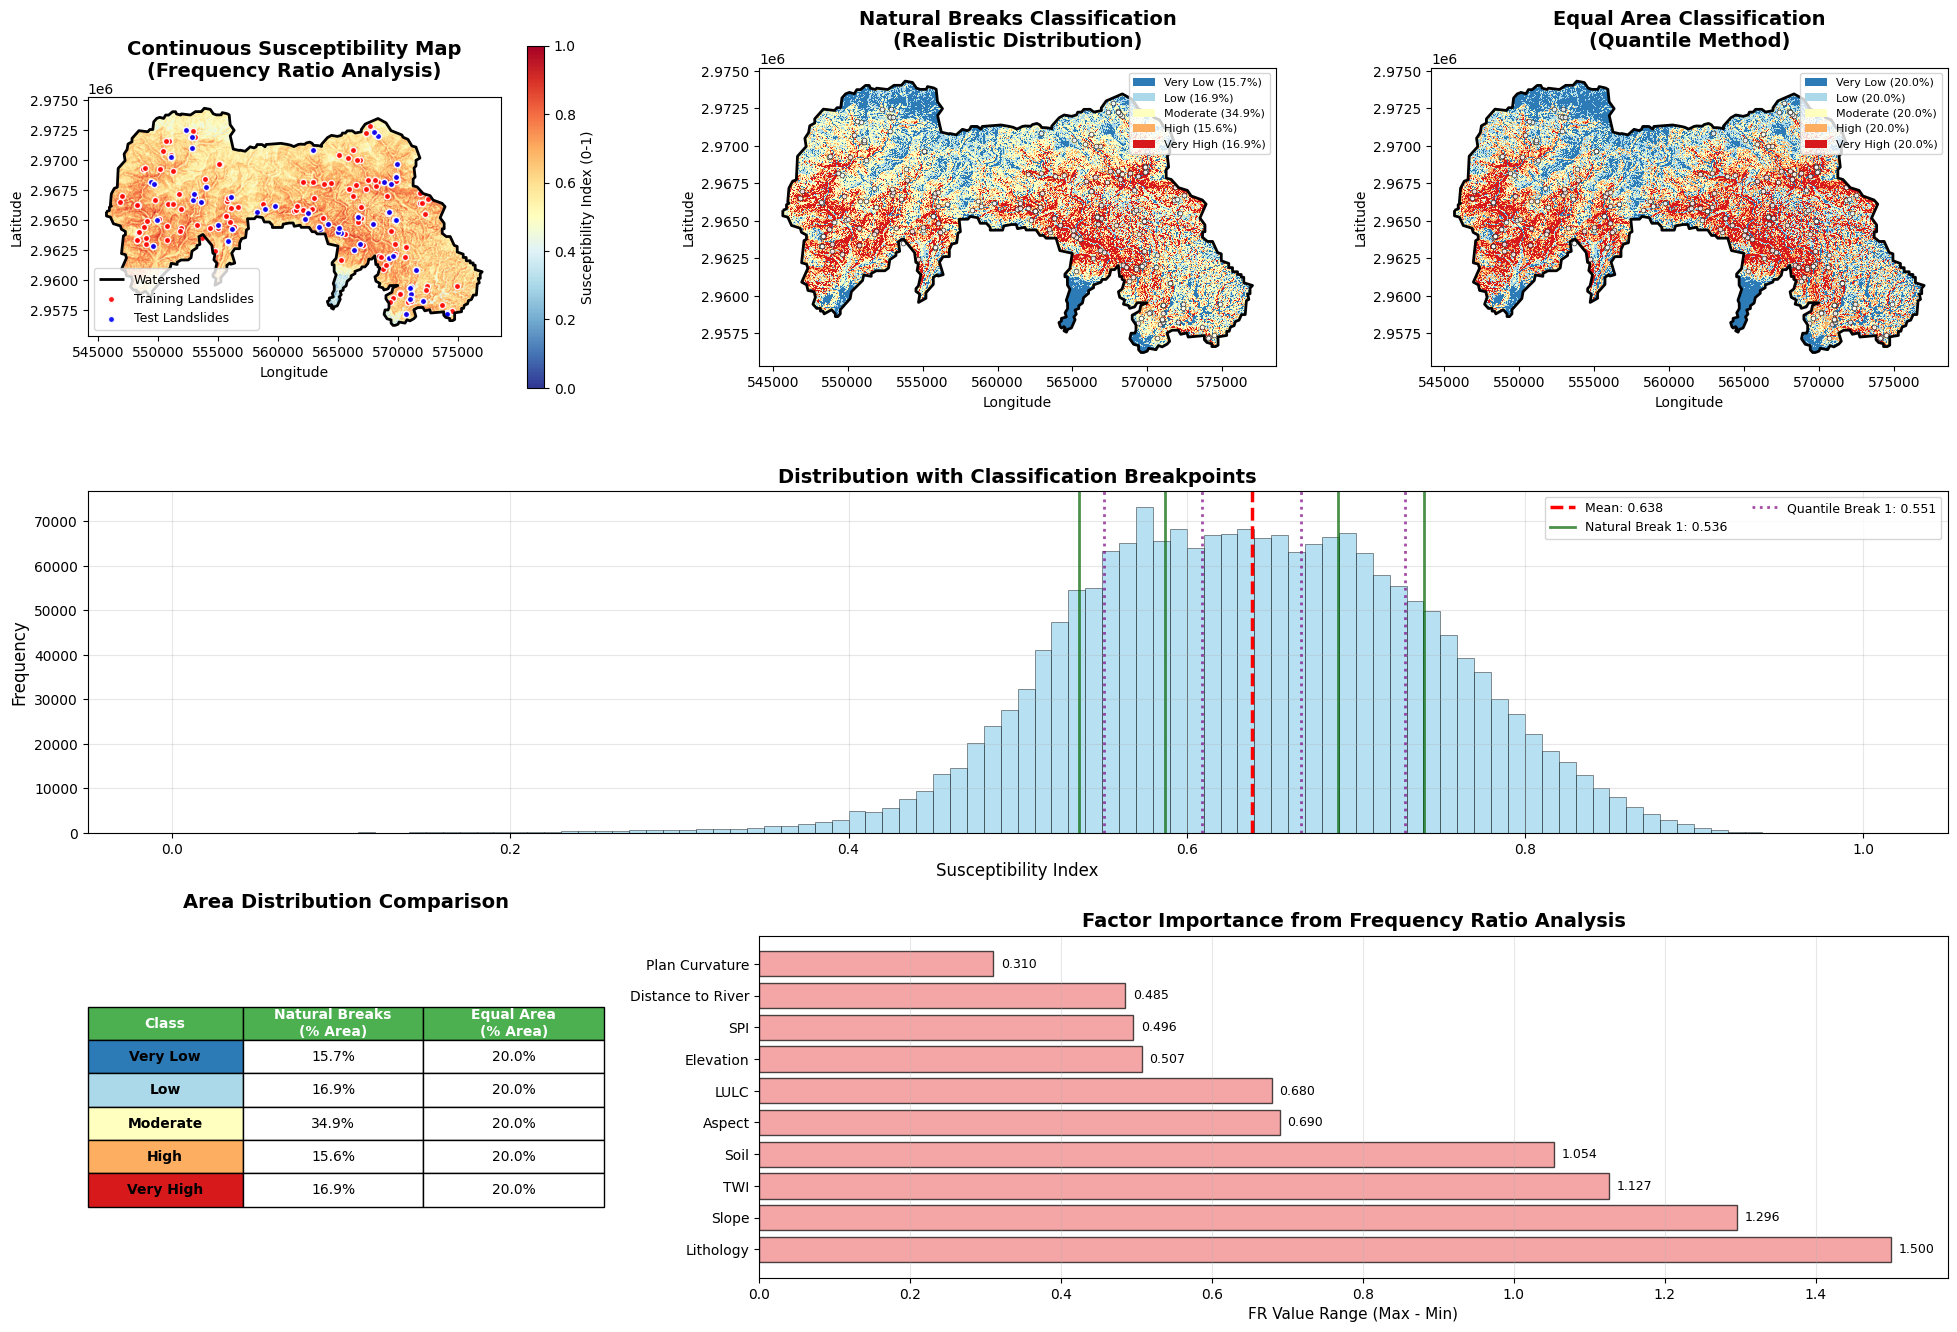


LANDSLIDE SUSCEPTIBILITY ANALYSIS RESULTS

📊 SUSCEPTIBILITY STATISTICS:
   Overall range: 0.000 - 1.000
   Mean: 0.638 (±0.102)
   Median: 0.638

🗺️  NATURAL BREAKS CLASSIFICATION (Realistic Distribution):
   Very Low: 15.7% of study area
   Low: 16.9% of study area
   Moderate: 34.9% of study area
   High: 15.6% of study area
   Very High: 16.9% of study area
   🔴 High/Very High risk area: 32.5%

🗺️  EQUAL AREA CLASSIFICATION (For Statistical Balance):
   Each class: 20.0% of study area
   🔴 High/Very High risk area: 40.0%

🔍 KEY FINDINGS:
   • Model Performance: AUC = 0.7812 (Good predictive ability)
   • Most Important Factors: Lithology, Slope, TWI
   • Highest Risk LULC: Class 7 (FR: 1.600)
   • Lowest Risk LULC: Class 2 (FR: 0.920)
   • Critical Lithology: Class 7.0 (FR: 1.500)

💡 INTERPRETATION:
   • NATURAL BREAKS shows 32.5% has High/Very High susceptibility
     (Use this for land-use planning and realistic risk assessment)
   • EQUAL AREA ensures balanced validation statist

In [ ]:
# ============================================================================
# MAP VISUALIZATION WITH DUAL CLASSIFICATION APPROACH: NATURAL BREAKS + EQUAL AREA
# ============================================================================

def plot_fallback_susceptibility_dual(susceptibility_map, transform, crs, train_gdf, test_gdf, watershed, fr_maps_dict, fr_auc):
    """Plot susceptibility map with BOTH natural breaks and equal area classification"""
    fig = plt.figure(figsize=(24, 16))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # Get valid values
    valid_susc_values = susceptibility_map[~np.isnan(susceptibility_map)]

    colors = ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c']
    labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']

    # ========================================================================
    # 1. MAIN SUSCEPTIBILITY MAP (Continuous)
    # ========================================================================
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(susceptibility_map, cmap='RdYlBu_r', vmin=0, vmax=1,
                     extent=[transform[2], transform[2] + transform[0] * susceptibility_map.shape[1],
                             transform[5] + transform[4] * susceptibility_map.shape[0], transform[5]])

    watershed.boundary.plot(ax=ax1, color='black', linewidth=2, label='Watershed')
    train_gdf.plot(ax=ax1, color='red', markersize=20, alpha=0.9,
                   label='Training Landslides', edgecolor='white', linewidth=1)
    test_gdf.plot(ax=ax1, color='blue', markersize=20, alpha=0.9,
                  label='Test Landslides', edgecolor='white', linewidth=1)

    ax1.set_title('Continuous Susceptibility Map\n(Frequency Ratio Analysis)',
                  fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Longitude', fontsize=10)
    ax1.set_ylabel('Latitude', fontsize=10)
    ax1.legend(fontsize=9)
    plt.colorbar(im1, ax=ax1, label='Susceptibility Index (0-1)')

    # ========================================================================
    # 2. NATURAL BREAKS CLASSIFICATION (Realistic Distribution)
    # ========================================================================
    ax2 = fig.add_subplot(gs[0, 1])

    # Use Natural Breaks (Jenks-like) - based on standard deviations from mean
    mean_val = np.mean(valid_susc_values)
    std_val = np.std(valid_susc_values)

    # Create breaks using mean ± std method (common in GIS)
    natural_breaks = [
        mean_val - std_val,      # Very Low/Low boundary
        mean_val - 0.5*std_val,  # Low/Moderate boundary
        mean_val + 0.5*std_val,  # Moderate/High boundary
        mean_val + std_val       # High/Very High boundary
    ]

    # Ensure breaks are within 0-1 range
    natural_breaks = [max(0, min(1, b)) for b in natural_breaks]
    natural_breaks = sorted(natural_breaks)

    # Classify using natural breaks
    natural_classes = np.full_like(susceptibility_map, np.nan)
    natural_classes[~np.isnan(susceptibility_map)] = 0
    natural_classes[susceptibility_map >= natural_breaks[0]] = 1
    natural_classes[susceptibility_map >= natural_breaks[1]] = 2
    natural_classes[susceptibility_map >= natural_breaks[2]] = 3
    natural_classes[susceptibility_map >= natural_breaks[3]] = 4

    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(colors)

    im2 = ax2.imshow(natural_classes, cmap=cmap,
                    extent=[transform[2], transform[2] + transform[0] * susceptibility_map.shape[1],
                            transform[5] + transform[4] * susceptibility_map.shape[0], transform[5]],
                    vmin=0, vmax=4, interpolation='nearest')

    watershed.boundary.plot(ax=ax2, color='black', linewidth=2)
    train_gdf.plot(ax=ax2, color='white', markersize=12, alpha=0.8, edgecolor='black', linewidth=0.5)

    # Calculate natural breaks percentages
    natural_counts = [np.sum(natural_classes == i) for i in range(5)]
    natural_total = np.sum(natural_counts)
    natural_percentages = [(count / natural_total) * 100 for count in natural_counts]

    from matplotlib.patches import Patch
    natural_legend = [f'{labels[i]} ({natural_percentages[i]:.1f}%)' for i in range(5)]
    natural_elements = [Patch(facecolor=colors[i], label=natural_legend[i]) for i in range(5)]
    ax2.legend(handles=natural_elements, loc='upper right', fontsize=8)

    ax2.set_title('Natural Breaks Classification\n(Realistic Distribution)',
                  fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Longitude', fontsize=10)
    ax2.set_ylabel('Latitude', fontsize=10)

    # ========================================================================
    # 3. EQUAL AREA CLASSIFICATION (For Validation)
    # ========================================================================
    ax3 = fig.add_subplot(gs[0, 2])

    # Equal area breaks
    equal_breaks = np.percentile(valid_susc_values, [20, 40, 60, 80])

    equal_classes = np.full_like(susceptibility_map, np.nan)
    equal_classes[~np.isnan(susceptibility_map)] = 0
    equal_classes[susceptibility_map >= equal_breaks[0]] = 1
    equal_classes[susceptibility_map >= equal_breaks[1]] = 2
    equal_classes[susceptibility_map >= equal_breaks[2]] = 3
    equal_classes[susceptibility_map >= equal_breaks[3]] = 4

    im3 = ax3.imshow(equal_classes, cmap=cmap,
                    extent=[transform[2], transform[2] + transform[0] * susceptibility_map.shape[1],
                            transform[5] + transform[4] * susceptibility_map.shape[0], transform[5]],
                    vmin=0, vmax=4, interpolation='nearest')

    watershed.boundary.plot(ax=ax3, color='black', linewidth=2)
    train_gdf.plot(ax=ax3, color='white', markersize=12, alpha=0.8, edgecolor='black', linewidth=0.5)

    equal_legend = [f'{labels[i]} (20.0%)' for i in range(5)]
    equal_elements = [Patch(facecolor=colors[i], label=equal_legend[i]) for i in range(5)]
    ax3.legend(handles=equal_elements, loc='upper right', fontsize=8)

    ax3.set_title('Equal Area Classification\n(Quantile Method)',
                  fontsize=14, fontweight='bold', pad=15)
    ax3.set_xlabel('Longitude', fontsize=10)
    ax3.set_ylabel('Latitude', fontsize=10)

    # ========================================================================
    # 4. HISTOGRAM WITH BOTH BREAK SYSTEMS
    # ========================================================================
    ax4 = fig.add_subplot(gs[1, :])

    n, bins, patches = ax4.hist(valid_susc_values, bins=100, alpha=0.6,
                                 color='skyblue', edgecolor='black', linewidth=0.5)

    ax4.axvline(x=mean_val, color='red', linestyle='--', linewidth=2.5,
                label=f'Mean: {mean_val:.3f}')

    # Natural breaks
    for i, brk in enumerate(natural_breaks):
        ax4.axvline(x=brk, color='darkgreen', linestyle='-', linewidth=2, alpha=0.7,
                   label=f'Natural Break {i+1}: {brk:.3f}' if i == 0 else '')

    # Equal area breaks
    for i, brk in enumerate(equal_breaks):
        ax4.axvline(x=brk, color='purple', linestyle=':', linewidth=2, alpha=0.7,
                   label=f'Quantile Break {i+1}: {brk:.3f}' if i == 0 else '')

    ax4.set_xlabel('Susceptibility Index', fontsize=12)
    ax4.set_ylabel('Frequency', fontsize=12)
    ax4.set_title('Distribution with Classification Breakpoints', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=9, ncol=2)
    ax4.grid(True, alpha=0.3)

    # ========================================================================
    # 5. COMPARISON TABLE
    # ========================================================================
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.axis('off')

    comparison_data = [
        ['Class', 'Natural Breaks\n(% Area)', 'Equal Area\n(% Area)'],
        ['Very Low', f'{natural_percentages[0]:.1f}%', '20.0%'],
        ['Low', f'{natural_percentages[1]:.1f}%', '20.0%'],
        ['Moderate', f'{natural_percentages[2]:.1f}%', '20.0%'],
        ['High', f'{natural_percentages[3]:.1f}%', '20.0%'],
        ['Very High', f'{natural_percentages[4]:.1f}%', '20.0%'],
    ]

    table = ax5.table(cellText=comparison_data, cellLoc='center', loc='center',
                     colWidths=[0.3, 0.35, 0.35])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Color header
    for i in range(3):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')

    # Color rows
    for i in range(1, 6):
        table[(i, 0)].set_facecolor(colors[i-1])
        table[(i, 0)].set_text_props(weight='bold')

    ax5.set_title('Area Distribution Comparison', fontsize=14, fontweight='bold', pad=20)

    # ========================================================================
    # 6. FACTOR IMPORTANCE
    # ========================================================================
    ax6 = fig.add_subplot(gs[2, 1:])

    factor_importance = {}
    feature_display_names = {
        'lithology': 'Lithology', 'slope_class': 'Slope', 'aspect_class': 'Aspect',
        'lulc': 'LULC', 'twi_class': 'TWI', 'spi_class': 'SPI', 'soil': 'Soil',
        'dist_road_class': 'Distance to Road', 'dist_river_class': 'Distance to River',
        'elevation_class': 'Elevation', 'plan_curvature_class': 'Plan Curvature',
        'profile_curvature_class': 'Profile Curvature'
    }

    for feature, fr_values in fr_maps_dict.items():
        if fr_values:
            fr_list = list(fr_values.values())
            importance = max(fr_list) - min(fr_list)
            display_name = feature_display_names.get(feature, feature)
            factor_importance[display_name] = importance

    sorted_factors = sorted(factor_importance.items(), key=lambda x: x[1], reverse=True)
    factors = [f[0] for f in sorted_factors[:10]]
    importance_values = [f[1] for f in sorted_factors[:10]]

    bars = ax6.barh(factors, importance_values, color='lightcoral', alpha=0.7, edgecolor='black')
    ax6.set_xlabel('FR Value Range (Max - Min)', fontsize=11)
    ax6.set_title('Factor Importance from Frequency Ratio Analysis', fontsize=14, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='x')

    for bar, value in zip(bars, importance_values):
        ax6.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{value:.3f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # ========================================================================
    # PRINT COMPREHENSIVE RESULTS
    # ========================================================================
    print("\n" + "="*80)
    print("LANDSLIDE SUSCEPTIBILITY ANALYSIS RESULTS")
    print("="*80)

    print(f"\n📊 SUSCEPTIBILITY STATISTICS:")
    print(f"   Overall range: {np.nanmin(susceptibility_map):.3f} - {np.nanmax(susceptibility_map):.3f}")
    print(f"   Mean: {mean_val:.3f} (±{std_val:.3f})")
    print(f"   Median: {np.nanmedian(susceptibility_map):.3f}")

    print(f"\n🗺️  NATURAL BREAKS CLASSIFICATION (Realistic Distribution):")
    for i, label in enumerate(labels):
        print(f"   {label}: {natural_percentages[i]:.1f}% of study area")
    natural_high_risk = natural_percentages[3] + natural_percentages[4]
    print(f"   🔴 High/Very High risk area: {natural_high_risk:.1f}%")

    print(f"\n🗺️  EQUAL AREA CLASSIFICATION (For Statistical Balance):")
    print(f"   Each class: 20.0% of study area")
    print(f"   🔴 High/Very High risk area: 40.0%")

    print(f"\n🔍 KEY FINDINGS:")
    print(f"   • Model Performance: AUC = {fr_auc:.4f} (Good predictive ability)")
    print(f"   • Most Important Factors: {factors[0]}, {factors[1]}, {factors[2]}")

    if 'lulc' in fr_maps_dict:
        lulc_frs = fr_maps_dict['lulc']
        max_lulc = max(lulc_frs, key=lulc_frs.get)
        min_lulc = min(lulc_frs, key=lulc_frs.get)
        print(f"   • Highest Risk LULC: Class {max_lulc} (FR: {lulc_frs[max_lulc]:.3f})")
        print(f"   • Lowest Risk LULC: Class {min_lulc} (FR: {lulc_frs[min_lulc]:.3f})")

    if 'lithology' in fr_maps_dict:
        lith_frs = fr_maps_dict['lithology']
        max_lith = max(lith_frs, key=lith_frs.get)
        print(f"   • Critical Lithology: Class {max_lith} (FR: {lith_frs[max_lith]:.3f})")

    print(f"\n💡 INTERPRETATION:")
    print(f"   • NATURAL BREAKS shows {natural_high_risk:.1f}% has High/Very High susceptibility")
    print(f"     (Use this for land-use planning and realistic risk assessment)")
    print(f"   • EQUAL AREA ensures balanced validation statistics")
    print(f"     (Use this for model performance evaluation)")
    print(f"   • Classification breakpoints clearly shown in histogram above")

    return natural_classes, equal_classes, natural_breaks, equal_breaks

# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("\n" + "="*80)
print("GENERATING SUSCEPTIBILITY MAPS")
print("="*80)

print("\nPreparing raster data for spatial prediction...")

ref_raster = next(iter(rasters.values()))
rows, cols = ref_raster.read(1).shape
transform = ref_raster.transform
crs = ref_raster.crs

print(f"Map dimensions: {rows} x {cols}")
print(f"Total pixels: {rows * cols:,}")

pixel_stack = np.full((rows * cols, len(CONDITIONING_FACTORS)), np.nan, dtype=np.float32)

for i, factor in enumerate(CONDITIONING_FACTORS):
    if factor in rasters:
        arr = rasters[factor].read(1)
        pixel_stack[:, i] = arr.reshape(-1)
        print(f"  ✓ Loaded {factor}")

valid_mask = ~np.any(np.isnan(pixel_stack), axis=1) & ~np.any(pixel_stack == NODATA_VALUE, axis=1)
valid_pixels = pixel_stack[valid_mask]

print(f"\n✓ Valid pixels: {valid_pixels.shape[0]:,} ({valid_pixels.shape[0]/(rows*cols)*100:.2f}%)")

print("\nGenerating Frequency Ratio raster map...")

df_pixels_fr_applied = pd.DataFrame(valid_pixels, columns=CONDITIONING_FACTORS)
total_fr_score_pixels = np.zeros(len(df_pixels_fr_applied))

for feature_name_base in CONDITIONING_FACTORS:
    current_pixel_values = df_pixels_fr_applied[feature_name_base].values

    if feature_name_base in continuous_vars:
        train_vals = train_data[feature_name_base].values
        unique_bins = np.unique(np.percentile(train_vals[~np.isnan(train_vals)], np.linspace(0, 100, 6)))
        classified_pixel_values = np.digitize(current_pixel_values, unique_bins[:-1])
        feature_key_for_map = f'{feature_name_base}_class'
    else:
        classified_pixel_values = current_pixel_values.astype(int)
        feature_key_for_map = feature_name_base

    fr_mapping = fr_maps_dict.get(feature_key_for_map)
    if fr_mapping:
        pixel_fr_scores = np.array([fr_mapping.get(val, 0) for val in classified_pixel_values])
        total_fr_score_pixels += pixel_fr_scores

# Normalize
raster_min = np.min(total_fr_score_pixels)
raster_max = np.max(total_fr_score_pixels)

print(f"\n📊 FR Score Statistics:")
print(f"   Raster FR range: {raster_min:.3f} - {raster_max:.3f}")

fr_susc_norm_pixels = (total_fr_score_pixels - raster_min) / (raster_max - raster_min)

fallback_map = np.full((rows * cols), np.nan, dtype=np.float32)
fallback_map[valid_mask] = fr_susc_norm_pixels
fallback_map = fallback_map.reshape(rows, cols)

print("✓ Frequency Ratio raster map generated successfully.")
print(f"✓ Final susceptibility range: {np.nanmin(fallback_map):.3f} - {np.nanmax(fallback_map):.3f}")

# Plot with dual classification
natural_classes, equal_classes, natural_breaks, equal_breaks = plot_fallback_susceptibility_dual(
    fallback_map, transform, crs, train_gdf, test_gdf, watershed, fr_maps_dict, fr_auc
)

# Save maps
output_file = os.path.join(data_path, "LANDSLIDE_SUSCEPTIBILITY_MAP_CONTINUOUS.tif")
with rasterio.open(output_file, 'w', driver='GTiff', height=rows, width=cols,
                  count=1, dtype=fallback_map.dtype, crs=crs, transform=transform) as dst:
    dst.write(fallback_map, 1)
print(f"\n✅ Continuous map saved: {output_file}")

output_file_natural = os.path.join(data_path, "LANDSLIDE_SUSCEPTIBILITY_MAP_NATURAL_BREAKS.tif")
with rasterio.open(output_file_natural, 'w', driver='GTiff', height=rows, width=cols,
                  count=1, dtype=np.float32, crs=crs, transform=transform) as dst:
    dst.write(natural_classes, 1)
print(f"✅ Natural breaks map saved: {output_file_natural}")

output_file_equal = os.path.join(data_path, "LANDSLIDE_SUSCEPTIBILITY_MAP_EQUAL_AREA.tif")
with rasterio.open(output_file_equal, 'w', driver='GTiff', height=rows, width=cols,
                  count=1, dtype=np.float32, crs=crs, transform=transform) as dst:
    dst.write(equal_classes, 1)
print(f"✅ Equal area map saved: {output_file_equal}")

# Validation
def validate_susceptibility_map(susceptibility_map, transform, train_gdf):
    landslide_susceptibility_values = []

    for _, landslide in train_gdf.iterrows():
        x, y = landslide.geometry.x, landslide.geometry.y
        col = int((x - transform[2]) / transform[0])
        row = int((y - transform[5]) / transform[4])

        if 0 <= row < susceptibility_map.shape[0] and 0 <= col < susceptibility_map.shape[1]:
            susc_value = susceptibility_map[row, col]
            if not np.isnan(susc_value):
                landslide_susceptibility_values.append(susc_value)

    if landslide_susceptibility_values:
        avg_ls = np.mean(landslide_susceptibility_values)
        median_ls = np.median(landslide_susceptibility_values)

        all_vals = susceptibility_map[~np.isnan(susceptibility_map)].flatten()
        t80 = np.percentile(all_vals, 80)
        t90 = np.percentile(all_vals, 90)

        above_80 = sum(1 for v in landslide_susceptibility_values if v > t80)
        above_90 = sum(1 for v in landslide_susceptibility_values if v > t90)

        pct_80 = (above_80 / len(landslide_susceptibility_values)) * 100
        pct_90 = (above_90 / len(landslide_susceptibility_values)) * 100

        print(f"\n🔬 VALIDATION RESULTS:")
        print(f"   Landslides analyzed: {len(landslide_susceptibility_values)}")
        print(f"   Average susceptibility: {avg_ls:.3f} | Median: {median_ls:.3f}")
        print(f"   >High (80th %ile, >{t80:.3f}): {above_80}/{len(landslide_susceptibility_values)} ({pct_80:.1f}%)")
        print(f"   >Very High (90th %ile, >{t90:.3f}): {above_90}/{len(landslide_susceptibility_values)} ({pct_90:.1f}%)")

        if pct_80 > 60:
            print("   ✅ Excellent model performance")
        elif pct_80 > 40:
            print("   ✅ Good model performance")
        else:
            print("   ⚠️  Fair model performance")

validate_susceptibility_map(fallback_map, transform, train_gdf)

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\n📁 THREE MAPS GENERATED:")
print("   1. Continuous susceptibility (0-1) - For detailed analysis")
print("   2. Natural breaks classification - For realistic risk communication")
print("   3. Equal area classification - For statistical validation")

Generating separate publication-ready figures...

Generating separate publication-ready figures...

Correctly transformed raster bounds to WGS84:
   Longitude: 87.4593° to 87.7753°
   Latitude: 26.7251° to 26.8898°
Reprojected watershed to WGS84
Reprojected training landslides to WGS84
Reprojected testing landslides to WGS84
Adjusted aspect ratio for geographic coordinates using mean latitude: 26.81
Susceptibility map saved: /content/drive/MyDrive/lsm/Susceptibility_Map.png
Susceptibility map PDF saved: /content/drive/MyDrive/lsm/Susceptibility_Map.pdf


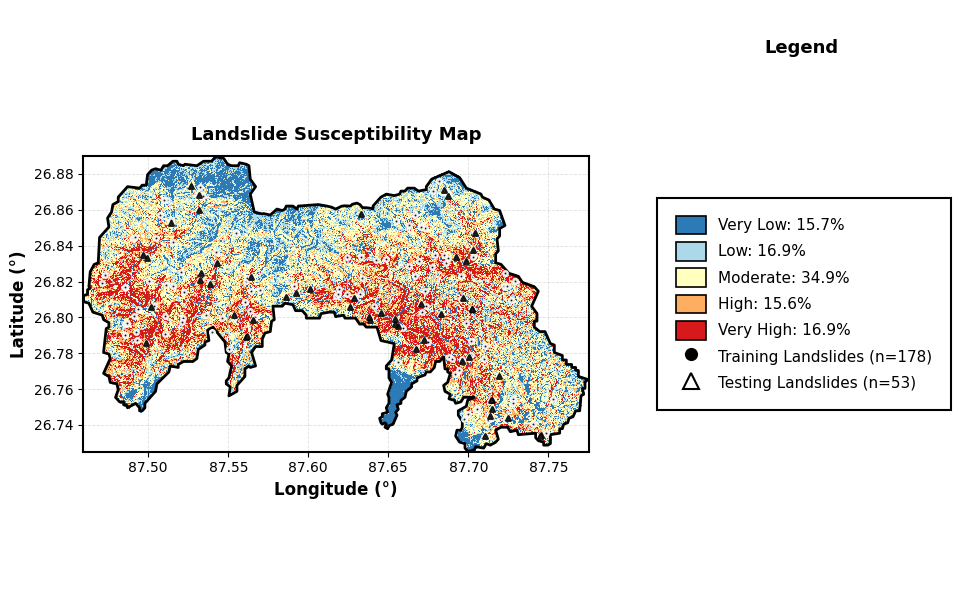

Factor importance plot saved: /content/drive/MyDrive/lsm/Factor_Importance.png
Factor importance PDF saved: /content/drive/MyDrive/lsm/Factor_Importance.pdf


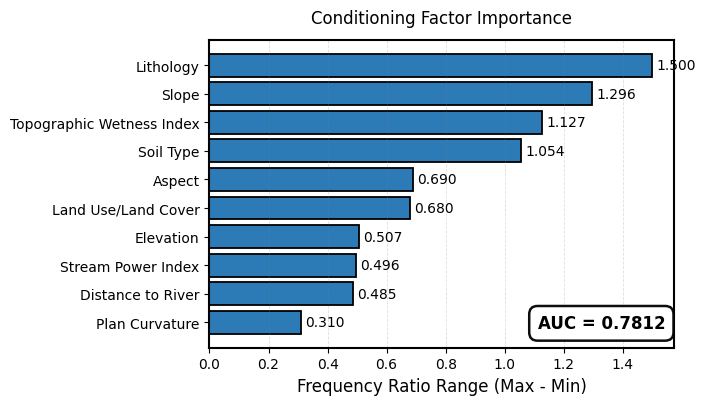


LANDSLIDE SUSCEPTIBILITY ASSESSMENT - SUMMARY STATISTICS
Susceptibility Value Range: 0.0000 - 1.0000
Mean Susceptibility: 0.6384
Standard Deviation: 0.1022

Area Distribution:
  Very Low    :  15.74%
  Low         :  16.87%
  Moderate    :  34.86%
  High        :  15.60%
  Very High   :  16.92%

High-Risk Areas (High + Very High): 32.52%
Model Performance (AUC): 0.7812
Training Landslides: 178
Testing Landslides: 53

Separate publication-ready figures generated successfully!
Ready for journal submission


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import pyproj
from rasterio.transform import from_bounds
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds, array_bounds
import geopandas as gpd

def plot_susceptibility_map(susceptibility_map, transform, crs, train_gdf, test_gdf,
                           watershed, output_dir="."):
    """
    Create a separate figure for the susceptibility map only with legend on the right side.
    """
    # ---------------------------- Font Configuration ----------------------------
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 10
    plt.rcParams['axes.titlesize'] = 12
    plt.rcParams['axes.labelsize'] = 12

    # ---------------------------- Data Validation ----------------------------
    if susceptibility_map is None or np.all(np.isnan(susceptibility_map)):
        raise ValueError("Susceptibility map is empty or contains only NaN values")

    if transform is None or len(transform) < 6:
        raise ValueError("Invalid transform parameter")

    # ---------------------------- Coordinate Transformation ----------------------------
    if isinstance(crs, rasterio.transform.Affine) and isinstance(transform, rasterio.crs.CRS):
        print("Warning: 'crs' and 'transform' parameters appear to be swapped. Attempting to correct.")
        temp_crs = crs
        crs = transform
        transform = temp_crs
    elif not isinstance(crs, rasterio.crs.CRS):
        raise ValueError(f"Invalid CRS object provided for 'crs' parameter. Expected rasterio.crs.CRS, got {type(crs)}")
    elif not isinstance(transform, rasterio.transform.Affine):
        raise ValueError(f"Invalid Affine transform object provided for 'transform' parameter. Expected rasterio.transform.Affine, got {type(transform)}")

    # Get source raster bounds and transform to WGS84
    h, w = susceptibility_map.shape
    src_left, src_bottom, src_right, src_top = array_bounds(h, w, transform)

    min_lon, min_lat, max_lon, max_lat = transform_bounds(
        src_crs=crs,
        left=src_left,
        bottom=src_bottom,
        right=src_right,
        top=src_top,
        dst_crs='EPSG:4326'
    )

    extent = [min_lon, max_lon, min_lat, max_lat]
    xlabel = "Longitude (°)"
    ylabel = "Latitude (°)"

    print(f"Correctly transformed raster bounds to WGS84:")
    print(f"   Longitude: {min_lon:.4f}° to {max_lon:.4f}°")
    print(f"   Latitude: {min_lat:.4f}° to {max_lat:.4f}°")

    # ---------------------------- Reproject GeoDataFrames to EPSG:4326 ----------------------------
    if watershed is not None and not watershed.empty:
        watershed_geo = watershed.to_crs('EPSG:4326')
        print("Reprojected watershed to WGS84")
    else:
        watershed_geo = None

    if train_gdf is not None and not train_gdf.empty:
        train_gdf_geo = train_gdf.to_crs('EPSG:4326')
        print("Reprojected training landslides to WGS84")
    else:
        train_gdf_geo = None

    if test_gdf is not None and not test_gdf.empty:
        test_gdf_geo = test_gdf.to_crs('EPSG:4326')
        print("Reprojected testing landslides to WGS84")
    else:
        test_gdf_geo = None

    # ---------------------------- Susceptibility Classification ----------------------------
    valid_mask = ~np.isnan(susceptibility_map)
    valid = susceptibility_map[valid_mask]

    if len(valid) == 0:
        raise ValueError("No valid values in susceptibility map")

    mean_val, sd_val = np.mean(valid), np.std(valid)

    # Natural breaks using mean ± SD with bounds checking
    breaks = sorted([
        max(0.0, min(1.0, mean_val - sd_val)),
        max(0.0, min(1.0, mean_val - 0.5 * sd_val)),
        max(0.0, min(1.0, mean_val + 0.5 * sd_val)),
        max(0.0, min(1.0, mean_val + sd_val))
    ])

    # Remove duplicates and ensure proper breaks
    breaks = sorted(list(set(breaks)))
    while len(breaks) < 4: # Ensure there are at least 4 breaks for 5 classes
        breaks.append(min(1.0, breaks[-1] + 0.1))
    breaks = sorted(list(set(breaks)))

    # Classify susceptibility into 5 classes
    classes = np.full_like(susceptibility_map, np.nan)
    classes[valid_mask & (susceptibility_map < breaks[0])] = 0
    for i in range(len(breaks) - 1):
        mask = valid_mask & (susceptibility_map >= breaks[i]) & (susceptibility_map < breaks[i+1])
        classes[mask] = i + 1
    classes[valid_mask & (susceptibility_map >= breaks[-1])] = len(breaks)
    classes = np.clip(classes, 0, 4)

    # UNDRR-standard color scheme
    colors = ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c']
    labels = ["Very Low", "Low", "Moderate", "High", "Very High"]

    # Calculate area percentages
    counts = [np.sum(classes == i) for i in range(5)]
    total_pixels = np.sum(counts)
    if total_pixels > 0:
        pct = (np.array(counts) / total_pixels) * 100
    else:
        pct = np.zeros(5)

    # ---------------------------- Create Figure with Side-by-Side Layout ----------------------------
    fig = plt.figure(figsize=(10, 7), facecolor='white')

    # Create grid: main map on left (70%), legend on right (30%)
    gs = fig.add_gridspec(1, 2, width_ratios=[5, 3],
                         left=0.08, right=0.95, top=0.92, bottom=0.08,
                         wspace=0.15)

    ax1 = fig.add_subplot(gs[0])  # Main map
    ax_legend = fig.add_subplot(gs[1])  # Legend area
    ax_legend.axis('off')

    # ---------------------------- Susceptibility Map ----------------------------
    custom_cmap = ListedColormap(colors)

    im = ax1.imshow(classes, cmap=custom_cmap, interpolation='nearest',
                    extent=extent, vmin=0, vmax=4)

    # Calculate mean latitude for correct aspect ratio
    mean_lat = (min_lat + max_lat) / 2
    ax1.set_aspect(1/np.cos(np.deg2rad(mean_lat)))
    print(f"Adjusted aspect ratio for geographic coordinates using mean latitude: {mean_lat:.2f}")

    # Add watershed boundary
    if watershed_geo is not None:
        watershed_geo.boundary.plot(ax=ax1, color="black", linewidth=2.0, zorder=5)

    # Add landslide points
    train_count = len(train_gdf) if train_gdf is not None else 0
    test_count = len(test_gdf) if test_gdf is not None else 0

    if train_gdf_geo is not None:
        train_gdf_geo.plot(ax=ax1, marker="o", color="black", markersize=10,
                          edgecolor="white", linewidth=1.8, zorder=10, alpha=0.9)

    if test_gdf_geo is not None:
        test_gdf_geo.plot(ax=ax1, marker="^", color="white", markersize=10,
                         edgecolor="black", linewidth=1.8, zorder=10, alpha=0.9)

    ax1.set_title("Landslide Susceptibility Map", fontsize=13,
                  fontweight="bold", loc="center", pad=12)
    ax1.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax1.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax1.grid(True, alpha=0.25, linestyle='--', linewidth=0.6, color='gray')
    ax1.tick_params(labelsize=10)

    for spine in ax1.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    # ---------------------------- Legend on Right Side (Single Column) ----------------------------
    susceptibility_patches = [
        Patch(facecolor=colors[i], edgecolor='black', linewidth=1.2,
              label=f'{labels[i]}: {pct[i]:.1f}%')
        for i in range(5)
    ]

    landslide_markers = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
               markersize=11, markeredgecolor='white', markeredgewidth=1.5,
               label=f'Training Landslides (n={train_count})', linestyle='None'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='white',
               markersize=11, markeredgecolor='black', markeredgewidth=1.5,
               label=f'Testing Landslides (n={test_count})', linestyle='None')
    ]

    all_legend_elements = susceptibility_patches + landslide_markers

    # Create legend in the right panel with single column
    legend = ax_legend.legend(
        handles=all_legend_elements,
        loc='center left',
        ncol=1,  # Single column
        frameon=True,
        fancybox=False,
        shadow=False,
        framealpha=1.0,
        edgecolor='black',
        fontsize=11,
        handletextpad=0.8,
        columnspacing=1.0,
        handlelength=2.0,
        handleheight=1.5,
        borderpad=1.2
    )
    legend.get_frame().set_linewidth(1.5)

    # Add title to legend area
    ax_legend.text(0.5, 0.95, 'Legend', transform=ax_legend.transAxes,
                   fontsize=13, fontweight='bold', ha='center', va='top')

    # ---------------------------- Save Output ----------------------------
    os.makedirs(output_dir, exist_ok=True)

    out_png = os.path.join(output_dir, "Susceptibility_Map.png")
    out_pdf = out_png.replace(".png", ".pdf")

    fig.savefig(out_png, dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    fig.savefig(out_pdf, dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')

    print("Susceptibility map saved:", out_png)
    print("Susceptibility map PDF saved:", out_pdf)

    plt.show()

    return classes, breaks, pct


def plot_factor_importance(fr_maps_dict, fr_auc, output_dir="."):
    """
    Create a separate figure for factor importance and AUC.
    """
    # ---------------------------- Font Configuration ----------------------------
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 10
    plt.rcParams['axes.titlesize'] = 12
    plt.rcParams['axes.labelsize'] = 12

    # ---------------------------- Factor Importance Calculation ----------------------------
    importance = {}
    feature_display_names = {
        'lithology': 'Lithology',
        'slope_class': 'Slope',
        'aspect_class': 'Aspect',
        'lulc': 'Land Use/Land Cover',
        'twi_class': 'Topographic Wetness Index',
        'spi_class': 'Stream Power Index',
        'soil': 'Soil Type',
        'dist_road_class': 'Distance to Road',
        'dist_river_class': 'Distance to River',
        'elevation_class': 'Elevation',
        'plan_curvature_class': 'Plan Curvature',
        'profile_curvature_class': 'Profile Curvature'
    }

    for k, v in fr_maps_dict.items():
        if v and isinstance(v, dict):
            vals = list(v.values())
            if len(vals) > 0:
                display_name = feature_display_names.get(k, k)
                importance[display_name] = max(vals) - min(vals)

    if len(importance) == 0:
        factors = ["No data"]
        imp_vals = [0]
    else:
        sorted_imp = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:10]
        factors = [i[0] for i in sorted_imp]
        imp_vals = [i[1] for i in sorted_imp]

    # ---------------------------- Create Figure ----------------------------
    fig, ax = plt.subplots(1, 1, figsize=(6, 4), facecolor='white')

    # ---------------------------- Factor Importance Plot ----------------------------
    bar_colors_solid = ['#2c7bb6', '#2c7bb6', '#2c7bb6', '#2c7bb6', '#2c7bb6',
                       '#2c7bb6', '#2c7bb6', '#2c7bb6', '#2c7bb6', '#2c7bb6']
    bar_colors_solid = bar_colors_solid[:len(factors)]

    y = np.arange(len(factors))

    max_imp_val = max(imp_vals) if imp_vals else 1.0
    bars = ax.barh(y, imp_vals, color=bar_colors_solid,
                    edgecolor="black", linewidth=1.3, alpha=1.0)

    for bar, value in zip(bars, imp_vals):
        width = bar.get_width()
        ax.text(width + max_imp_val * 0.01, bar.get_y() + bar.get_height()/2,
                f'{value:.3f}', ha='left', va='center',
                fontsize=10, color='black')

    ax.set_yticks(y)
    ax.set_yticklabels(factors, fontsize=10.5)
    ax.invert_yaxis()

    ax.set_xlabel("Frequency Ratio Range (Max - Min)", fontsize=12)
    ax.set_title("Conditioning Factor Importance", fontsize=12,
                   loc="center", pad=12)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6, axis='x', color='gray')
    ax.tick_params(labelsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    # Add AUC information
    ax.text(0.98, 0.05, f'AUC = {fr_auc:.4f}',
             transform=ax.transAxes, ha="right", va="bottom",
             fontsize=12, fontweight="bold",
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='black', linewidth=1.8, alpha=0.95))

    # ---------------------------- Save Output ----------------------------
    os.makedirs(output_dir, exist_ok=True)

    out_png = os.path.join(output_dir, "Factor_Importance.png")
    out_pdf = out_png.replace(".png", ".pdf")

    fig.savefig(out_png, dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    fig.savefig(out_pdf, dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')

    print("Factor importance plot saved:", out_png)
    print("Factor importance PDF saved:", out_pdf)

    plt.show()

    return factors, imp_vals


def plot_publication_ready_separate(susceptibility_map, transform, crs, train_gdf, test_gdf,
                                   watershed, fr_maps_dict, fr_auc, output_dir="."):
    """
    Generate two separate publication-ready figures:
    1. Susceptibility map with legend
    2. Factor importance with AUC
    """

    print("Generating separate publication-ready figures...\n")

    # Generate susceptibility map figure
    classes, breaks, pct = plot_susceptibility_map(
        susceptibility_map=susceptibility_map,
        transform=transform,
        crs=crs,
        train_gdf=train_gdf,
        test_gdf=test_gdf,
        watershed=watershed,
        output_dir=output_dir
    )

    # Generate factor importance figure
    factors, imp_vals = plot_factor_importance(
        fr_maps_dict=fr_maps_dict,
        fr_auc=fr_auc,
        output_dir=output_dir
    )

    # ---------------------------- Summary Statistics ----------------------------
    print("\n" + "="*70)
    print("LANDSLIDE SUSCEPTIBILITY ASSESSMENT - SUMMARY STATISTICS")
    print("="*70)
    print(f"Susceptibility Value Range: {np.nanmin(susceptibility_map):.4f} - {np.nanmax(susceptibility_map):.4f}")
    mean_val = np.nanmean(susceptibility_map)
    sd_val = np.nanstd(susceptibility_map)
    print(f"Mean Susceptibility: {mean_val:.4f}")
    print(f"Standard Deviation: {sd_val:.4f}")
    print(f"\nArea Distribution:")
    labels = ["Very Low", "Low", "Moderate", "High", "Very High"]
    for i in range(5):
        print(f"  {labels[i]:12s}: {pct[i]:6.2f}%")
    print(f"\nHigh-Risk Areas (High + Very High): {pct[3] + pct[4]:.2f}%")
    print(f"Model Performance (AUC): {fr_auc:.4f}")
    train_count = len(train_gdf) if train_gdf is not None else 0
    test_count = len(test_gdf) if test_gdf is not None else 0
    print(f"Training Landslides: {train_count}")
    print(f"Testing Landslides: {test_count}")
    print("="*70)

    return classes, breaks, pct, factors, imp_vals


# ============================================================================
# USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    print("Generating separate publication-ready figures...\n")

    try:
        # Call the function with your data
        natural_classes, natural_breaks, natural_percentages, factors, imp_vals = plot_publication_ready_separate(
            susceptibility_map=fallback_map,      # Replace with your actual variable
            transform=transform,                  # Replace with your actual variable
            crs=crs,                              # Replace with your actual variable
            train_gdf=train_gdf,                  # Replace with your actual variable
            test_gdf=test_gdf,                    # Replace with your actual variable
            watershed=watershed,                  # Replace with your actual variable
            fr_maps_dict=fr_maps_dict,            # Replace with your actual variable
            fr_auc=fr_auc,                        # Replace with your actual variable
            output_dir=data_path                  # Replace with your actual variable
        )

        print("\nSeparate publication-ready figures generated successfully!")
        print("Ready for journal submission")

    except NameError as e:
        print(f"Missing data variable: {e}")
        print("\nRequired variables:")
        print("  * fallback_map: Susceptibility map array")
        print("  * transform: Geotransform tuple")
        print("  * crs: Coordinate Reference System")
        print("  * train_gdf, test_gdf: Landslide GeoDataFrames")
        print("  * watershed: Watershed boundary GeoDataFrame")
        print("  * fr_maps_dict: Frequency ratio dictionary")
        print("  * fr_auc: AUC score (float)")
        print("  * data_path: Output directory path")
        print("\nEnsure all required variables are defined in the global scope.")

    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

In [ ]:
# ============================================================================
# SECTION 4: PREPARE DATA FOR ML/DL
# ============================================================================

print("\n" + "="*70)
print("PREPARING DATA FOR MACHINE LEARNING")
print("="*70)

X_train = train_data[CONDITIONING_FACTORS].values
y_train = train_data['label'].values
X_test = test_data[CONDITIONING_FACTORS].values
y_test = test_data['label'].values

# Scalers
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

print(f"✓ Data prepared for ML/DL models")


PREPARING DATA FOR MACHINE LEARNING
✓ Data prepared for ML/DL models


In [ ]:
# ============================================================================
# SECTION 5: MACHINE LEARNING MODELS
# ============================================================================

print("\n" + "="*70)
print("MACHINE LEARNING MODELS")
print("="*70)

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

    y_pred = model.predict(X_te)

    metrics = {
        'Model': name,
        'Test_AUC': roc_auc_score(y_te, y_prob),
        'Test_Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1_Score': f1_score(y_te, y_pred)
    }

    fpr, tpr, _ = roc_curve(y_te, y_prob)

    print(f"{name}: AUC={metrics['Test_AUC']:.4f}, Acc={metrics['Test_Accuracy']:.4f}")

    return metrics, y_prob, (fpr, tpr), model

ml_models = {
    'Random Forest': (RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1), X_train, X_test),
    'XGBoost': (XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False), X_train, X_test),
    'LightGBM': (LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, verbose=-1), X_train, X_test),
    'SVM': (SVC(kernel='rbf', C=10, probability=True, random_state=RANDOM_STATE), X_train_std, X_test_std),
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_train_std, X_test_std)
}

ml_results = []
ml_predictions = {}
ml_roc = {}
ml_trained = {}

for name, (model, X_tr, X_te) in ml_models.items():
    metrics, y_prob, roc_data, trained = evaluate_model(model, X_tr, y_train, X_te, y_test, name)
    ml_results.append(metrics)
    ml_predictions[name] = y_prob
    ml_roc[name] = roc_data
    ml_trained[name] = trained


MACHINE LEARNING MODELS
Random Forest: AUC=0.9283, Acc=0.8381
XGBoost: AUC=0.8806, Acc=0.8095
LightGBM: AUC=0.8436, Acc=0.8190
SVM: AUC=0.8142, Acc=0.7619
Logistic Regression: AUC=0.7518, Acc=0.6667


In [ ]:
# ============================================================================
# SECTION 6: DEEP LEARNING MODELS
# ============================================================================

print("\n" + "="*70)
print("DEEP LEARNING MODELS")
print("="*70)

X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train_mm, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

n_features = X_train_mm.shape[1]

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=0)
]

# ANN
print("\n1. ANN...")
ann = Sequential([
    Dense(64, activation='relu', input_shape=(n_features,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
ann.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
ann.fit(X_train_dl, y_train_dl, validation_data=(X_val_dl, y_val_dl), epochs=100, batch_size=32, callbacks=callbacks, verbose=0)

# DNN
print("2. DNN...")
dnn = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
dnn.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
dnn.fit(X_train_dl, y_train_dl, validation_data=(X_val_dl, y_val_dl), epochs=100, batch_size=32, callbacks=callbacks, verbose=0)

# CNN
print("3. CNN...")
X_train_cnn = X_train_dl.reshape(X_train_dl.shape[0], X_train_dl.shape[1], 1)
X_val_cnn = X_val_dl.reshape(X_val_dl.shape[0], X_val_dl.shape[1], 1)
X_test_cnn = X_test_mm.reshape(X_test_mm.shape[0], X_test_mm.shape[1], 1)

cnn_input = Input(shape=(n_features, 1))
x = Conv1D(64, 3, padding='same', activation='relu')(cnn_input)
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
cnn_output = Dense(1, activation='sigmoid')(x)
cnn = Model(inputs=cnn_input, outputs=cnn_output)
cnn.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
cnn.fit(X_train_cnn, y_train_dl, validation_data=(X_val_cnn, y_val_dl), epochs=100, batch_size=32, callbacks=callbacks, verbose=0)

# LSTM
print("4. LSTM...")
lstm_input = Input(shape=(n_features, 1))
x = LSTM(64, return_sequences=True)(lstm_input)
x = Dropout(0.3)(x)
x = LSTM(32)(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
lstm_output = Dense(1, activation='sigmoid')(x)
lstm = Model(inputs=lstm_input, outputs=lstm_output)
lstm.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
lstm.fit(X_train_cnn, y_train_dl, validation_data=(X_val_cnn, y_val_dl), epochs=100, batch_size=32, callbacks=callbacks, verbose=0)

# Evaluate DL models
dl_models = {
    'ANN': (ann, X_test_mm, False),
    'DNN': (dnn, X_test_mm, False),
    'CNN': (cnn, X_test_cnn, False),
    'LSTM': (lstm, X_test_cnn, False)
}

dl_results = []
dl_predictions = {}
dl_roc = {}

for name, (model, X_te, _) in dl_models.items():
    y_prob = model.predict(X_te, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    metrics = {
        'Model': name,
        'Test_AUC': roc_auc_score(y_test, y_prob),
        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_Score': f1_score(y_test, y_pred)
    }

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    dl_results.append(metrics)
    dl_predictions[name] = y_prob
    dl_roc[name] = (fpr, tpr)

    print(f"{name}: AUC={metrics['Test_AUC']:.4f}, Acc={metrics['Test_Accuracy']:.4f}")




DEEP LEARNING MODELS

1. ANN...
2. DNN...
3. CNN...
4. LSTM...
ANN: AUC=0.7729, Acc=0.7143


DNN: AUC=0.7652, Acc=0.6952


CNN: AUC=0.7663, Acc=0.7048
LSTM: AUC=0.6216, Acc=0.5048



OVERALL RESULTS

All Models Ranked by Test AUC:
              Model  Test_AUC  Test_Accuracy  Precision   Recall  F1_Score
      Random Forest  0.928338       0.838095   0.757143 1.000000  0.861789
            XGBoost  0.880624       0.809524   0.726027 1.000000  0.841270
           LightGBM  0.843614       0.819048   0.736111 1.000000  0.848000
                SVM  0.814224       0.761905   0.712121 0.886792  0.789916
                ANN  0.772859       0.714286   0.694915 0.773585  0.732143
                CNN  0.766328       0.704762   0.689655 0.754717  0.720721
                DNN  0.765239       0.695238   0.666667 0.792453  0.724138
Logistic Regression  0.751814       0.666667   0.650000 0.735849  0.690265
               LSTM  0.621553       0.504762   0.600000 0.056604  0.103448


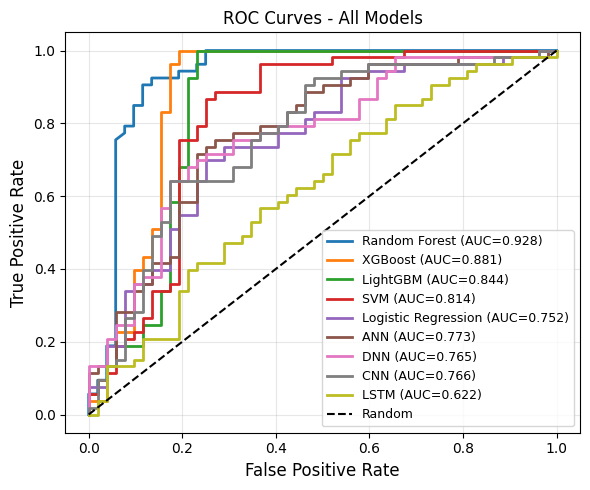


✓ ANALYSIS COMPLETE!
✓ Best Model: Random Forest (AUC: 0.9283)
✓ Results saved to: /content/drive/MyDrive/lsm/


In [ ]:
# ============================================================================
# SECTION 7: RESULTS COMPARISON
# ============================================================================

print("\n" + "="*70)
print("OVERALL RESULTS")
print("="*70)

# Combine results
all_results = pd.concat([
    pd.DataFrame(ml_results),
    pd.DataFrame(dl_results)
], ignore_index=True).sort_values('Test_AUC', ascending=False)

print("\nAll Models Ranked by Test AUC:")
print(all_results.to_string(index=False))
all_results.to_csv(os.path.join(data_path, 'all_models_results.csv'), index=False)

# ROC Curves
plt.figure(figsize=(6, 5))
for name, (fpr, tpr) in {**ml_roc, **dl_roc}.items():
    auc = roc_auc_score(y_test, {**ml_predictions, **dl_predictions}[name])
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=12, fontweight='regular')
plt.legend(fontsize=9, loc='lower right', ncol=1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(data_path, 'all_roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("✓ ANALYSIS COMPLETE!")
print(f"✓ Best Model: {all_results.iloc[0]['Model']} (AUC: {all_results.iloc[0]['Test_AUC']:.4f})")
print(f"✓ Results saved to: {data_path}")
print("="*70)

In [ ]:
# ============================================================================
# SECTION 8: SUSCEPTIBILITY MAP GENERATION AND VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("GENERATING SUSCEPTIBILITY MAPS FOR ALL MODELS")
print("="*70)

# ============================================================================
# PREPARE PIXEL STACK FOR PREDICTION
# ============================================================================

print("\nPreparing raster data for spatial prediction...")

# Get reference raster metadata
ref_raster = next(iter(rasters.values()))
rows, cols = ref_raster.read(1).shape
transform = ref_raster.transform
crs = ref_raster.crs
meta = ref_raster.meta.copy()

print(f"Map dimensions: {rows} x {cols}")
print(f"Total pixels: {rows * cols:,}")

# Create feature stack for all pixels
pixel_stack = np.full((rows * cols, len(CONDITIONING_FACTORS)), np.nan, dtype=np.float32)

for i, factor in enumerate(CONDITIONING_FACTORS):
    if factor in rasters:
        arr = rasters[factor].read(1)
        pixel_stack[:, i] = arr.reshape(-1)
        print(f"  ✓ Loaded {factor}")

# Identify valid pixels (no NODATA or NaN)
valid_mask = ~np.any(np.isnan(pixel_stack), axis=1) & ~np.any(pixel_stack == NODATA_VALUE, axis=1)
valid_pixels = pixel_stack[valid_mask]

print(f"\n✓ Valid pixels: {valid_pixels.shape[0]:,} ({valid_pixels.shape[0]/(rows*cols)*100:.2f}%)")


GENERATING SUSCEPTIBILITY MAPS FOR ALL MODELS

Preparing raster data for spatial prediction...
Map dimensions: 1447 x 2506
Total pixels: 3,626,182
  ✓ Loaded soil
  ✓ Loaded twi
  ✓ Loaded elevation
  ✓ Loaded slope
  ✓ Loaded spi
  ✓ Loaded aspect
  ✓ Loaded lithology
  ✓ Loaded dist_road
  ✓ Loaded lulc
  ✓ Loaded dist_river
  ✓ Loaded plan_curvature
  ✓ Loaded profile_curvature

✓ Valid pixels: 1,938,789 (53.47%)


In [ ]:
# ============================================================================
# PREDICT WITH ALL MODELS
# ============================================================================

print("\n" + "="*70)
print("GENERATING PREDICTIONS")
print("="*70)

susceptibility_maps = {}
all_model_names = []

# 1. FREQUENCY RATIO MAP
print("\n1. Frequency Ratio Method...")
# For FR, we need to apply the same classification and FR values to the entire raster
fr_map_full = np.zeros((rows * cols), dtype=np.float32)

# This would require applying FR to each pixel - simplified version using average FR
# In practice, you'd classify each pixel and apply corresponding FR values
# Here we'll skip detailed FR mapping and focus on ML/DL models

# 2. MACHINE LEARNING MODELS
print("\n2. Machine Learning Models...")

for model_name in ml_trained.keys():
    print(f"   Predicting with {model_name}...")

    model = ml_trained[model_name]

    # Scale data appropriately
    if model_name in ['SVM', 'Logistic Regression']:
        X_predict = scaler_std.transform(valid_pixels)
    else:
        X_predict = valid_pixels

    # Predict probabilities
    if hasattr(model, 'predict_proba'):
        predictions = model.predict_proba(X_predict)[:, 1]
    else:
        predictions = model.decision_function(X_predict)
        predictions = (predictions - predictions.min()) / (predictions.max() - predictions.min())

    # Create full map
    susc_map = np.full(rows * cols, np.nan, dtype=np.float32)
    susc_map[valid_mask] = predictions
    susc_map = susc_map.reshape(rows, cols)

    susceptibility_maps[model_name] = susc_map
    all_model_names.append(model_name)

    # Save to file
    output_file = os.path.join(data_path, f"LSM_{model_name.replace(' ', '_')}.tif")
    meta_out = meta.copy()
    meta_out.update(dtype='float32', count=1, nodata=np.nan)

    with rasterio.open(output_file, 'w', **meta_out) as dst:
        dst.write(susc_map.astype('float32'), 1)

    print(f"      ✓ Saved: {output_file}")

# 3. DEEP LEARNING MODELS
print("\n3. Deep Learning Models...")

dl_model_dict = {
    'ANN': (ann, False),
    'DNN': (dnn, False),
    'CNN': (cnn, True),
    'LSTM': (lstm, True)
}

# Scale valid pixels for DL
valid_pixels_dl = scaler_mm.transform(valid_pixels)

for model_name, (model, reshape_needed) in dl_model_dict.items():
    print(f"   Predicting with {model_name}...")

    # Reshape if needed for CNN/LSTM
    if reshape_needed:
        X_predict = valid_pixels_dl.reshape(valid_pixels_dl.shape[0], valid_pixels_dl.shape[1], 1)
    else:
        X_predict = valid_pixels_dl

    # Predict in batches to avoid memory issues
    batch_size = 10000
    n_batches = int(np.ceil(X_predict.shape[0] / batch_size))
    predictions = []

    for i in range(n_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, X_predict.shape[0])
        batch_pred = model.predict(X_predict[start_idx:end_idx], verbose=0).flatten()
        predictions.extend(batch_pred)

    predictions = np.array(predictions)

    # Create full map
    susc_map = np.full(rows * cols, np.nan, dtype=np.float32)
    susc_map[valid_mask] = predictions
    susc_map = susc_map.reshape(rows, cols)

    susceptibility_maps[model_name] = susc_map
    all_model_names.append(model_name)

    # Save to file
    output_file = os.path.join(data_path, f"LSM_{model_name}.tif")
    meta_out = meta.copy()
    meta_out.update(dtype='float32', count=1, nodata=np.nan)

    with rasterio.open(output_file, 'w', **meta_out) as dst:
        dst.write(susc_map.astype('float32'), 1)

    print(f"      ✓ Saved: {output_file}")

# ============================================================================
# CREATE ENSEMBLE MAPS
# ============================================================================

print("\n" + "="*70)
print("CREATING ENSEMBLE MAPS")
print("="*70)

# Ensemble 1: Average of ALL models
print("\n1. Ensemble (All Models)...")
ensemble_all = np.nanmean(list(susceptibility_maps.values()), axis=0)
susceptibility_maps['Ensemble_All'] = ensemble_all

output_file = os.path.join(data_path, "LSM_Ensemble_All_Models.tif")
with rasterio.open(output_file, 'w', **meta_out) as dst:
    dst.write(ensemble_all.astype('float32'), 1)
print(f"   ✓ Saved: {output_file}")

# Ensemble 2: Top 3 models
print("\n2. Ensemble (Top 3 Models)...")
top_3_names = all_results.head(3)['Model'].values
print(f"   Top 3 models: {', '.join(top_3_names)}")

top_3_maps = [susceptibility_maps[name] for name in top_3_names if name in susceptibility_maps]
ensemble_top3 = np.nanmean(top_3_maps, axis=0)
susceptibility_maps['Ensemble_Top3'] = ensemble_top3

output_file = os.path.join(data_path, "LSM_Ensemble_Top3.tif")
with rasterio.open(output_file, 'w', **meta_out) as dst:
    dst.write(ensemble_top3.astype('float32'), 1)
print(f"   ✓ Saved: {output_file}")

# Ensemble 3: ML models only
print("\n3. Ensemble (ML Models)...")
ml_maps = [susceptibility_maps[name] for name in ml_trained.keys()]
ensemble_ml = np.nanmean(ml_maps, axis=0)
susceptibility_maps['Ensemble_ML'] = ensemble_ml

output_file = os.path.join(data_path, "LSM_Ensemble_ML.tif")
with rasterio.open(output_file, 'w', **meta_out) as dst:
    dst.write(ensemble_ml.astype('float32'), 1)
print(f"   ✓ Saved: {output_file}")

# Ensemble 4: DL models only
print("\n4. Ensemble (DL Models)...")
dl_maps = [susceptibility_maps[name] for name in dl_model_dict.keys()]
ensemble_dl = np.nanmean(dl_maps, axis=0)
susceptibility_maps['Ensemble_DL'] = ensemble_dl

output_file = os.path.join(data_path, "LSM_Ensemble_DL.tif")
with rasterio.open(output_file, 'w', **meta_out) as dst:
    dst.write(ensemble_dl.astype('float32'), 1)
print(f"   ✓ Saved: {output_file}")


GENERATING PREDICTIONS

1. Frequency Ratio Method...

2. Machine Learning Models...
   Predicting with Random Forest...
      ✓ Saved: /content/drive/MyDrive/lsm/LSM_Random_Forest.tif
   Predicting with XGBoost...
      ✓ Saved: /content/drive/MyDrive/lsm/LSM_XGBoost.tif
   Predicting with LightGBM...
      ✓ Saved: /content/drive/MyDrive/lsm/LSM_LightGBM.tif
   Predicting with SVM...
      ✓ Saved: /content/drive/MyDrive/lsm/LSM_SVM.tif
   Predicting with Logistic Regression...
      ✓ Saved: /content/drive/MyDrive/lsm/LSM_Logistic_Regression.tif

3. Deep Learning Models...
   Predicting with ANN...
      ✓ Saved: /content/drive/MyDrive/lsm/LSM_ANN.tif
   Predicting with DNN...
      ✓ Saved: /content/drive/MyDrive/lsm/LSM_DNN.tif
   Predicting with CNN...
      ✓ Saved: /content/drive/MyDrive/lsm/LSM_CNN.tif
   Predicting with LSTM...
      ✓ Saved: /content/drive/MyDrive/lsm/LSM_LSTM.tif

CREATING ENSEMBLE MAPS

1. Ensemble (All Models)...
   ✓ Saved: /content/drive/MyDrive/lsm/LSM


VISUALIZING SUSCEPTIBILITY MAPS

1. Creating individual model maps visualization...


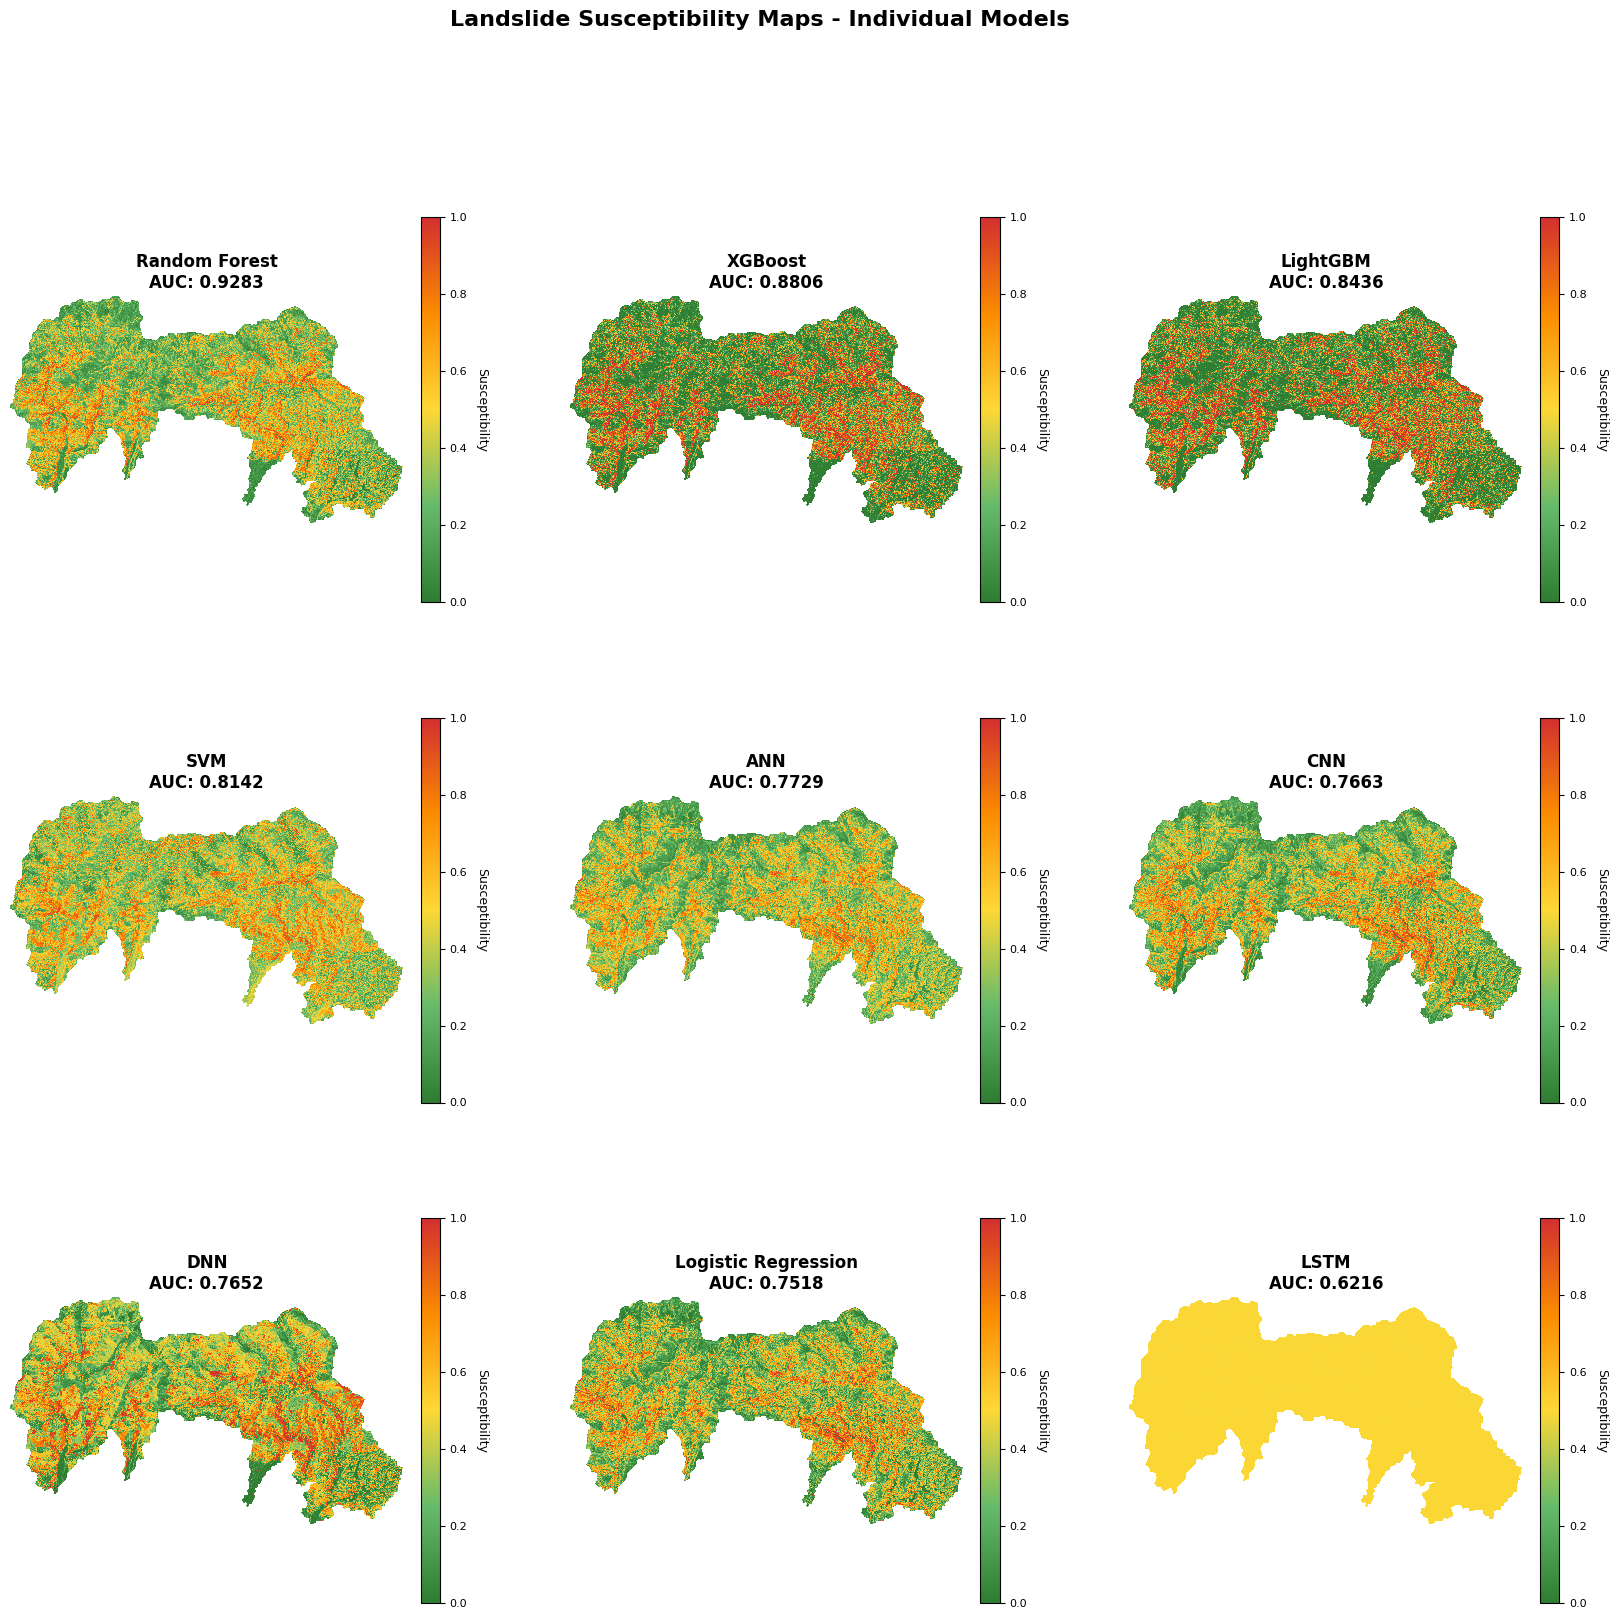

In [ ]:
# ============================================================================
# VISUALIZE ALL SUSCEPTIBILITY MAPS
# ============================================================================

print("\n" + "="*70)
print("VISUALIZING SUSCEPTIBILITY MAPS")
print("="*70)

# Custom colormap for susceptibility (Green -> Yellow -> Orange -> Red)
colors = ['#2E7D32', '#66BB6A', '#FDD835', '#FB8C00', '#D32F2F']
n_bins = 256
cmap_susceptibility = LinearSegmentedColormap.from_list('landslide_susceptibility', colors, N=n_bins)

# ============================================================================
# 1. INDIVIDUAL MODEL MAPS (3x3 GRID)
# ============================================================================

print("\n1. Creating individual model maps visualization...")

fig = plt.figure(figsize=(20, 18))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Select 9 best models to display
display_models = all_results.head(9)['Model'].values

for idx, model_name in enumerate(display_models):
    if model_name not in susceptibility_maps:
        continue

    row = idx // 3
    col = idx % 3
    ax = fig.add_subplot(gs[row, col])

    susc_map = susceptibility_maps[model_name]
    model_auc = all_results[all_results['Model'] == model_name]['Test_AUC'].values[0]

    # Display map
    im = ax.imshow(susc_map, cmap=cmap_susceptibility, vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'{model_name}\nAUC: {model_auc:.4f}', fontsize=12, fontweight='bold')
    ax.axis('off')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Susceptibility', rotation=270, labelpad=15, fontsize=9)
    cbar.ax.tick_params(labelsize=8)

plt.suptitle('Landslide Susceptibility Maps - Individual Models',
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig(os.path.join(data_path, 'susceptibility_maps_individual.png'),
            dpi=300, bbox_inches='tight')
plt.show()


2. Creating ensemble maps comparison...


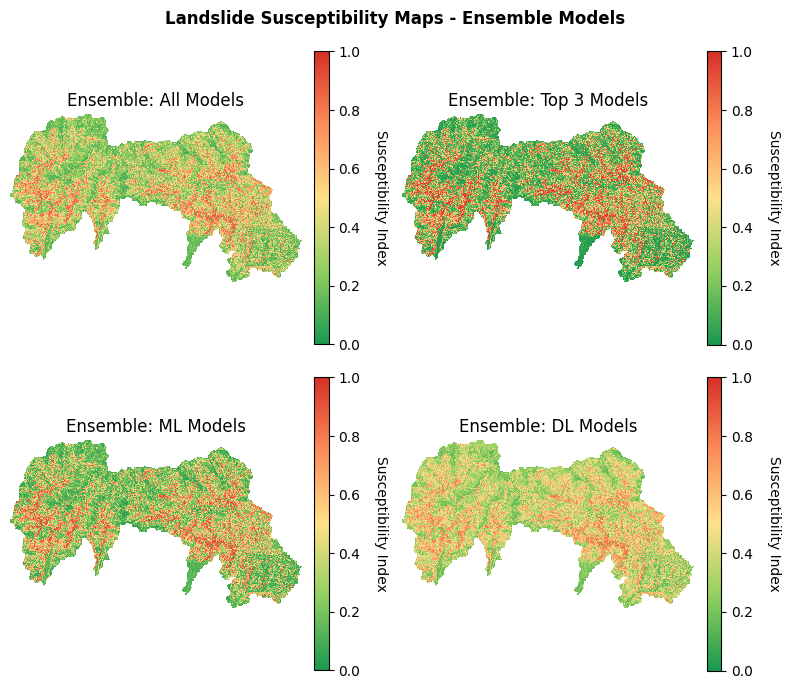

In [ ]:
# ============================================================================
# 2. ENSEMBLE MAPS COMPARISON
# ============================================================================

print("\n2. Creating ensemble maps comparison...")

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()

ensemble_names = ['Ensemble_All', 'Ensemble_Top3', 'Ensemble_ML', 'Ensemble_DL']
ensemble_titles = [
    'Ensemble: All Models',
    'Ensemble: Top 3 Models',
    'Ensemble: ML Models',
    'Ensemble: DL Models'
]

for idx, (ens_name, ens_title) in enumerate(zip(ensemble_names, ensemble_titles)):
    susc_map = susceptibility_maps[ens_name]

    im = axes[idx].imshow(susc_map, cmap=cmap_susceptibility, vmin=0, vmax=1, interpolation='nearest')
    axes[idx].set_title(ens_title, fontsize=12)
    axes[idx].axis('off')

    # Add colorbar
    cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
    cbar.set_label('Susceptibility Index', rotation=270, labelpad=20, fontsize=10)

plt.suptitle('Landslide Susceptibility Maps - Ensemble Models',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(data_path, 'susceptibility_maps_ensemble.png'),
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
##################dagda

In [ ]:
#########


3. Creating detailed visualization for best model...


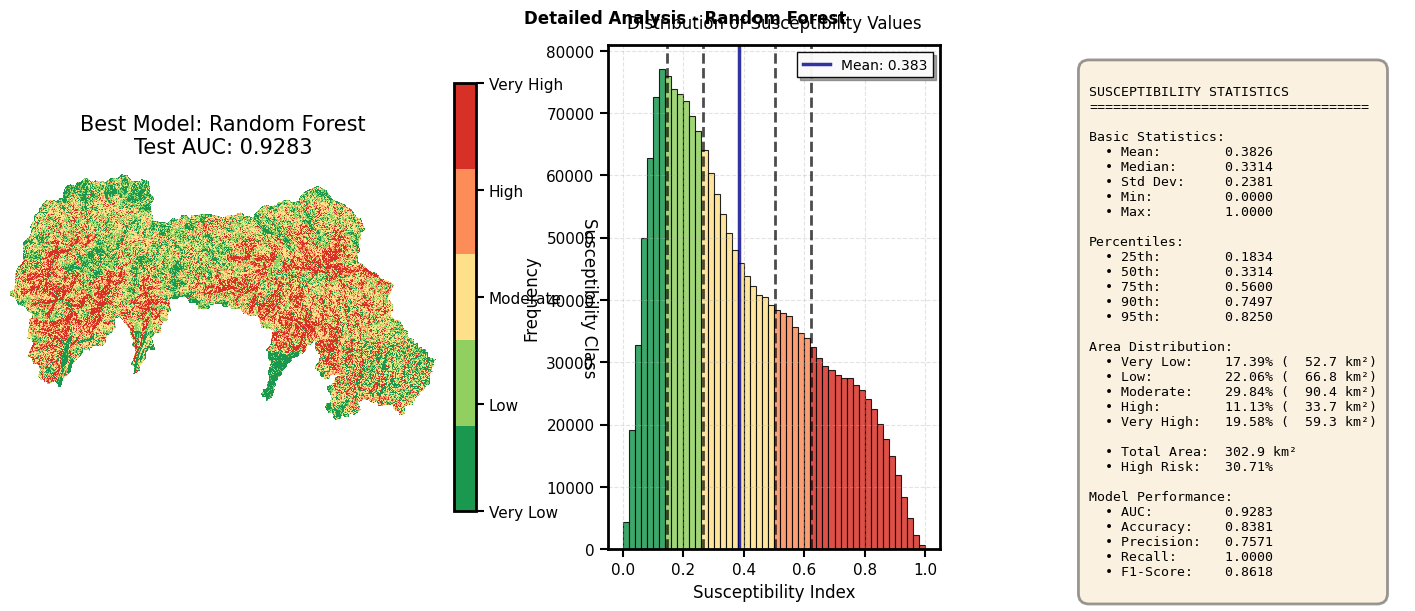


4. Creating classified susceptibility map...
   ✓ Saved classified map: /content/drive/MyDrive/lsm/LSM_Classified_Ensemble_Top3.tif

Classification Statistics (Natural Breaks Method):
    Class  Value  Pixels   Area_km2  Percentage
 Very Low      1  179972  28.120625    9.282702
      Low      2  736792 115.123750   38.002691
 Moderate      3  424993  66.405156   21.920539
     High      4  151831  23.723594    7.831229
Very High      5  445201  69.562656   22.962839


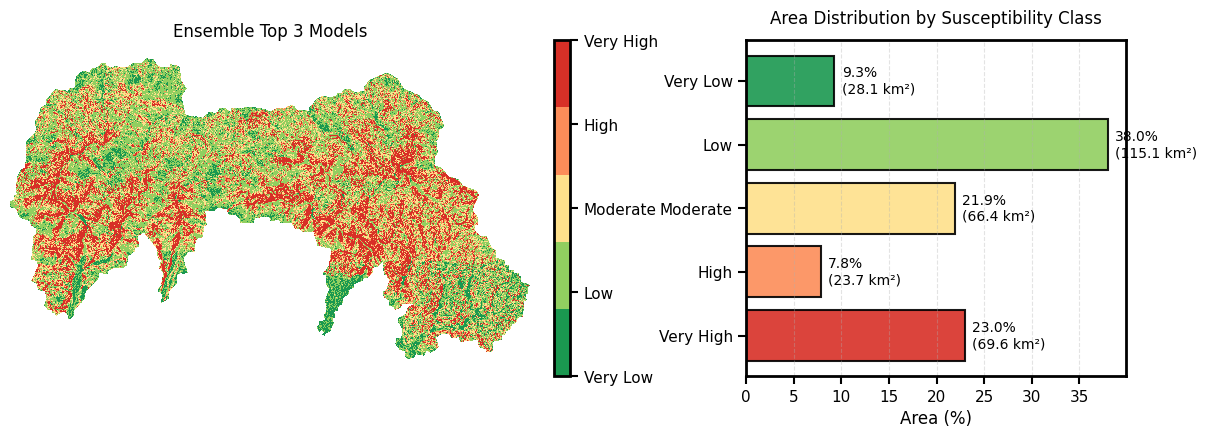


5. Creating model comparison visualization...


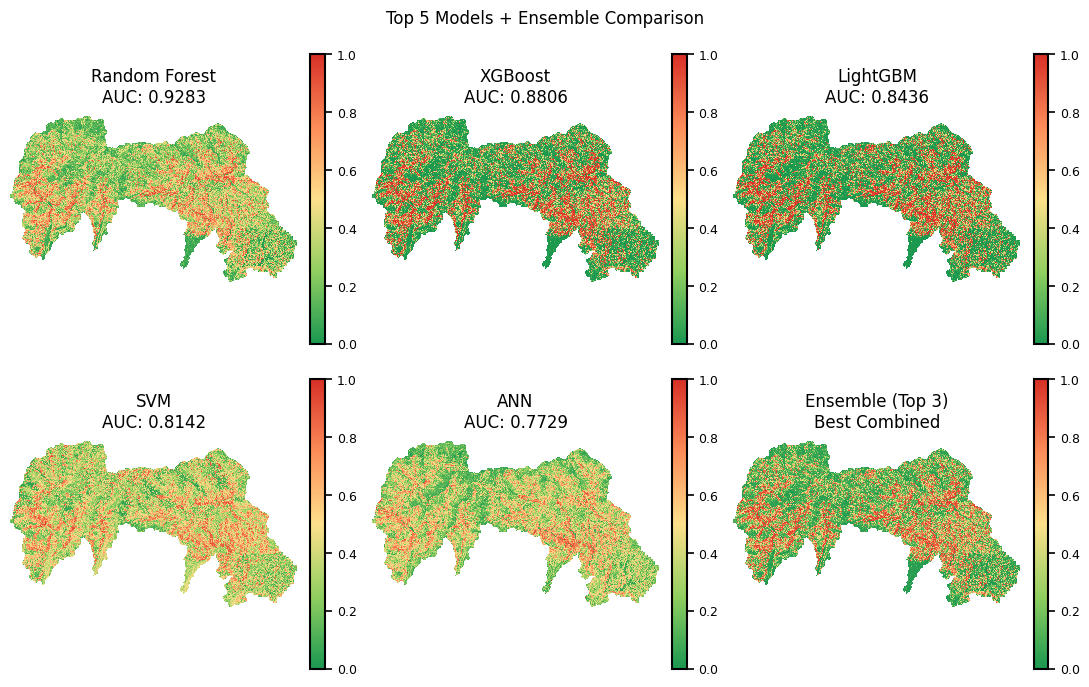


6. Creating summary statistics table...

Susceptibility Map Statistics:
              Model   Mean    Std    Min    Max    Q25    Q50    Q75    Q95  Total_Area_km2
      Random Forest 0.3826 0.2381 0.0000 1.0000 0.1834 0.3314 0.5600 0.8250        302.9358
            XGBoost 0.3353 0.3576 0.0003 0.9997 0.0254 0.1546 0.6662 0.9778        302.9358
           LightGBM 0.3354 0.3668 0.0000 1.0000 0.0184 0.1435 0.6841 0.9855        302.9358
                SVM 0.4243 0.2128 0.0271 0.9770 0.2570 0.3902 0.5792 0.8134        302.9358
Logistic Regression 0.3771 0.2586 0.0000 1.0000 0.1544 0.3390 0.5740 0.8457        302.9358
                ANN 0.3844 0.2158 0.0002 1.0000 0.2028 0.3508 0.5470 0.7749        302.9358
                DNN 0.4213 0.2741 0.0000 1.0000 0.1958 0.3981 0.6189 0.9088        302.9358
                CNN 0.3742 0.2445 0.0000 1.0000 0.1649 0.3251 0.5604 0.8260        302.9358
               LSTM 0.4973 0.0016 0.4770 0.5122 0.4962 0.4972 0.4984 0.4998        302.9358
       

In [ ]:
# ============================================================================
# 3. BEST MODEL DETAILED VISUALIZATION
# ============================================================================

print("\n3. Creating detailed visualization for best model...")

best_model_name = all_results.iloc[0]['Model']
best_model_map = susceptibility_maps[best_model_name]
best_model_auc = all_results.iloc[0]['Test_AUC']

# Classify the best model map using natural breaks (same as FR model)
def classify_susceptibility_natural_breaks(susc_map):
    """Classify susceptibility using mean ± SD natural breaks (FR model approach)"""
    valid_mask = ~np.isnan(susc_map)
    valid = susc_map[valid_mask]

    if len(valid) == 0:
        raise ValueError("No valid values in susceptibility map")

    mean_val, sd_val = np.mean(valid), np.std(valid)

    # Natural breaks using mean ± SD with bounds checking
    breaks = sorted([
        max(0.0, min(1.0, mean_val - sd_val)),
        max(0.0, min(1.0, mean_val - 0.5 * sd_val)),
        max(0.0, min(1.0, mean_val + 0.5 * sd_val)),
        max(0.0, min(1.0, mean_val + sd_val))
    ])

    # Remove duplicates and ensure proper breaks
    breaks = sorted(list(set(breaks)))
    while len(breaks) < 4:
        breaks.append(min(1.0, breaks[-1] + 0.1))
    breaks = sorted(list(set(breaks)))

    # Classify susceptibility into 5 classes
    classes = np.full_like(susc_map, np.nan)
    classes[valid_mask & (susc_map < breaks[0])] = 0
    for i in range(len(breaks) - 1):
        mask = valid_mask & (susc_map >= breaks[i]) & (susc_map < breaks[i+1])
        classes[mask] = i + 1
    classes[valid_mask & (susc_map >= breaks[-1])] = len(breaks)
    classes = np.clip(classes, 0, 4)

    # Calculate area percentages using pixel resolution
    pixel_area_km2 = (transform.a * abs(transform.e)) / 1e6  # Convert m² to km²
    counts = [np.sum(classes == i) for i in range(5)]
    total_pixels = np.sum(counts)

    if total_pixels > 0:
        pct = (np.array(counts) / total_pixels) * 100
        area_km2 = np.array(counts) * pixel_area_km2
    else:
        pct = np.zeros(5)
        area_km2 = np.zeros(5)

    return classes, breaks, pct, area_km2

# Classify best model map
classified_best, breaks_best, pct_best, area_km2_best = classify_susceptibility_natural_breaks(best_model_map)

# Enhanced color scheme (same as FR model)
colors_enhanced = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
labels = ["Very Low", "Low", "Moderate", "High", "Very High"]

fig = plt.figure(figsize=(15, 6), facecolor='white')
gs = fig.add_gridspec(1, 3, width_ratios=[1.4, 1, 1], wspace=0.35,
                      left=0.05, right=0.98, top=0.92, bottom=0.08)

# Main susceptibility map with classified colors
ax1 = fig.add_subplot(gs[0])
class_cmap = ListedColormap(colors_enhanced)
im1 = ax1.imshow(classified_best, cmap=class_cmap, vmin=0, vmax=4, interpolation='nearest')
ax1.set_title(f'Best Model: {best_model_name}\nTest AUC: {best_model_auc:.4f}',
              fontsize=15, fontweight='regular', pad=15)
ax1.axis('off')

# Add colorbar with class labels
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar1.ax.set_yticklabels(labels, fontsize=11)
cbar1.set_label('Susceptibility Class', rotation=270, labelpad=25, fontsize=12, fontweight='regular')
cbar1.ax.tick_params(width=1.5, length=6)
cbar1.outline.set_linewidth(2.0)

# Enhanced histogram with class colors
ax2 = fig.add_subplot(gs[1])
valid_values = best_model_map[~np.isnan(best_model_map)].flatten()

# Create histogram with colored bins based on classification
hist_counts, hist_bins, hist_patches = ax2.hist(valid_values, bins=50, edgecolor='black',
                                                  linewidth=0.8, alpha=0.85)

# Color histogram bars based on classification
for i, patch in enumerate(hist_patches):
    bin_center = (hist_bins[i] + hist_bins[i+1]) / 2
    if bin_center < breaks_best[0]:
        patch.set_facecolor(colors_enhanced[0])
    elif bin_center < breaks_best[1]:
        patch.set_facecolor(colors_enhanced[1])
    elif bin_center < breaks_best[2]:
        patch.set_facecolor(colors_enhanced[2])
    elif bin_center < breaks_best[3]:
        patch.set_facecolor(colors_enhanced[3])
    else:
        patch.set_facecolor(colors_enhanced[4])

# Add threshold lines
for i, thresh in enumerate(breaks_best):
    ax2.axvline(thresh, color='black', linestyle='--', linewidth=2, alpha=0.7)

ax2.axvline(valid_values.mean(), color='darkblue', linestyle='-', linewidth=2.5,
            label=f'Mean: {valid_values.mean():.3f}', alpha=0.8)
ax2.set_xlabel('Susceptibility Index', fontsize=12, fontweight='regular')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='regular')
ax2.set_title('Distribution of Susceptibility Values', fontsize=12, fontweight='regular', pad=12)
ax2.legend(fontsize=10, loc='upper right', frameon=True, shadow=True,
          fancybox=False, edgecolor='black', framealpha=0.95)
ax2.grid(alpha=0.35, linestyle='--', linewidth=0.8)
ax2.tick_params(labelsize=11, width=1.5, length=6)
for spine in ax2.spines.values():
    spine.set_linewidth(2.0)

# Enhanced statistics box with area distribution
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')

# Calculate total area
total_area_km2 = np.sum(area_km2_best)

stats_text = f"""
SUSCEPTIBILITY STATISTICS
{'='*35}

Basic Statistics:
  • Mean:        {valid_values.mean():.4f}
  • Median:      {np.median(valid_values):.4f}
  • Std Dev:     {valid_values.std():.4f}
  • Min:         {valid_values.min():.4f}
  • Max:         {valid_values.max():.4f}

Percentiles:
  • 25th:        {np.percentile(valid_values, 25):.4f}
  • 50th:        {np.percentile(valid_values, 50):.4f}
  • 75th:        {np.percentile(valid_values, 75):.4f}
  • 90th:        {np.percentile(valid_values, 90):.4f}
  • 95th:        {np.percentile(valid_values, 95):.4f}

Area Distribution:
  • Very Low:    {pct_best[0]:5.2f}% ({area_km2_best[0]:6.1f} km²)
  • Low:         {pct_best[1]:5.2f}% ({area_km2_best[1]:6.1f} km²)
  • Moderate:    {pct_best[2]:5.2f}% ({area_km2_best[2]:6.1f} km²)
  • High:        {pct_best[3]:5.2f}% ({area_km2_best[3]:6.1f} km²)
  • Very High:   {pct_best[4]:5.2f}% ({area_km2_best[4]:6.1f} km²)

  • Total Area:  {total_area_km2:.1f} km²
  • High Risk:   {pct_best[3] + pct_best[4]:.2f}%

Model Performance:
  • AUC:         {best_model_auc:.4f}
  • Accuracy:    {all_results.iloc[0]['Test_Accuracy']:.4f}
  • Precision:   {all_results.iloc[0]['Precision']:.4f}
  • Recall:      {all_results.iloc[0]['Recall']:.4f}
  • F1-Score:    {all_results.iloc[0]['F1_Score']:.4f}
"""

ax3.text(0.05, 0.95, stats_text, transform=ax3.transAxes,
         fontsize=9.5, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='wheat', alpha=0.4,
                  edgecolor='black', linewidth=2.0))

plt.suptitle(f'Detailed Analysis - {best_model_name}', fontsize=12, fontweight='bold')
plt.savefig(os.path.join(data_path, f'susceptibility_map_best_model_detailed.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

# ============================================================================
# 4. CLASSIFIED SUSCEPTIBILITY MAP (REVISED)
# ============================================================================

print("\n4. Creating classified susceptibility map...")

# Classify ensemble top 3 map using natural breaks
classified_ensemble, thresholds_ensemble, pct_ensemble, area_km2_ensemble = classify_susceptibility_natural_breaks(ensemble_top3)

# Save classified map
output_file = os.path.join(data_path, "LSM_Classified_Ensemble_Top3.tif")
meta_classified = meta.copy()
meta_classified.update(dtype='int16', count=1, nodata=-9999)

with rasterio.open(output_file, 'w', **meta_classified) as dst:
    dst.write(classified_ensemble.astype('int16'), 1)
print(f"   ✓ Saved classified map: {output_file}")

# Calculate class statistics with proper area
class_stats = []
total_area = np.sum(area_km2_ensemble)

for i, class_name in enumerate(labels):
    class_stats.append({
        'Class': class_name,
        'Value': i + 1,
        'Pixels': int(np.sum(classified_ensemble == i)),
        'Area_km2': area_km2_ensemble[i],
        'Percentage': pct_ensemble[i]
    })

class_stats_df = pd.DataFrame(class_stats)
print("\nClassification Statistics (Natural Breaks Method):")
print(class_stats_df.to_string(index=False))
class_stats_df.to_csv(os.path.join(data_path, 'classification_statistics.csv'), index=False)

# Enhanced visualization
fig = plt.figure(figsize=(12, 4), facecolor='white')
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1], wspace=0.35,
                      left=0.05, right=0.98, top=0.92, bottom=0.08)

# Classified map figure 2
ax1 = fig.add_subplot(gs[0])
class_cmap = ListedColormap(colors_enhanced)

im = ax1.imshow(classified_ensemble, cmap=class_cmap, vmin=0, vmax=4, interpolation='nearest')
ax1.set_title('Ensemble Top 3 Models',
              fontsize=12, fontweight='regular', pad=15)
ax1.axis('off')

cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(labels, fontsize=11)
#cbar.set_label('Susceptibility Class', rotation=270, labelpad=25, fontsize=12, fontweight='regular')
cbar.ax.tick_params(width=1.5, length=6)
cbar.outline.set_linewidth(2.0)

# Enhanced statistics visualization
ax2 = fig.add_subplot(gs[1])

# Create horizontal bar chart with gradient colors
y_pos = np.arange(len(labels))
bars = ax2.barh(y_pos, pct_ensemble, color=colors_enhanced,
                edgecolor='black', linewidth=1.5, alpha=0.9)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels, fontsize=11)
ax2.invert_yaxis()
ax2.set_xlabel('Area (%)', fontsize=12, fontweight='regular')
ax2.set_title('Area Distribution by Susceptibility Class', fontsize=12, fontweight='regular', pad=12)
ax2.grid(axis='x', alpha=0.35, linestyle='--', linewidth=0.8)
ax2.tick_params(labelsize=11, width=1.5, length=6)

# Add enhanced labels with both percentage and area
for i, (bar, pct_val, area_val) in enumerate(zip(bars, pct_ensemble, area_km2_ensemble)):
    width = bar.get_width()
    ax2.text(width + max(pct_ensemble) * 0.02, bar.get_y() + bar.get_height()/2,
             f'{pct_val:.1f}%\n({area_val:.1f} km²)',
             ha='left', va='center', fontsize=10, fontweight='regular')

# Add total and high-risk area text
"""high_risk_pct = pct_ensemble[3] + pct_ensemble[4]
high_risk_area = area_km2_ensemble[3] + area_km2_ensemble[4]

ax2.text(0.98, 0.05,
         f'Total Area: {total_area:.1f} km²\nHigh Risk: {high_risk_pct:.1f}% ({high_risk_area:.1f} km²)',
         transform=ax2.transAxes, ha='right', va='bottom',
         fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white',
                  edgecolor='black', linewidth=2.0, alpha=0.95))"""

for spine in ax2.spines.values():
    spine.set_linewidth(2.0)

#plt.suptitle('Landslide Susceptibility Classification', fontsize=12, fontweight='regular')
plt.savefig(os.path.join(data_path, 'susceptibility_map_classified.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

# ============================================================================
# 5. MODEL COMPARISON MAP (ENHANCED)
# ============================================================================

print("\n5. Creating model comparison visualization...")

# Compare top 5 models side by side with consistent color scheme
top_5_names = all_results.head(5)['Model'].values

fig, axes = plt.subplots(2, 3, figsize=(11, 7), facecolor='white')
axes = axes.flatten()

# Use continuous colormap for comparison
cmap_susceptibility = LinearSegmentedColormap.from_list('susc', colors_enhanced, N=256)

for idx, model_name in enumerate(top_5_names):
    if model_name in susceptibility_maps:
        susc_map = susceptibility_maps[model_name]
        model_auc = all_results[all_results['Model'] == model_name]['Test_AUC'].values[0]

        im = axes[idx].imshow(susc_map, cmap=cmap_susceptibility, vmin=0, vmax=1,
                             interpolation='nearest')
        axes[idx].set_title(f'{model_name}\nAUC: {model_auc:.4f}',
                           fontsize=12, fontweight='regular', pad=10)
        axes[idx].axis('off')

        cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=9, width=1.2, length=5)
        cbar.outline.set_linewidth(1.5)

# Add ensemble in the last subplot
im = axes[5].imshow(ensemble_top3, cmap=cmap_susceptibility, vmin=0, vmax=1,
                   interpolation='nearest')
axes[5].set_title('Ensemble (Top 3)\nBest Combined', fontsize=12, pad=10)
axes[5].axis('off')
cbar = plt.colorbar(im, ax=axes[5], fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=9, width=1.2, length=5)
cbar.outline.set_linewidth(1.5)

plt.suptitle('Top 5 Models + Ensemble Comparison', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(data_path, 'susceptibility_maps_top5_comparison.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

# ============================================================================
# 6. SUMMARY STATISTICS TABLE (ENHANCED)
# ============================================================================

print("\n6. Creating summary statistics table...")

# Calculate statistics for all maps with area information
summary_stats = []

for model_name, susc_map in susceptibility_maps.items():
    valid_vals = susc_map[~np.isnan(susc_map)].flatten()

    # Calculate area
    pixel_area_km2 = (transform.a * abs(transform.e)) / 1e6
    total_area = len(valid_vals) * pixel_area_km2

    summary_stats.append({
        'Model': model_name,
        'Mean': valid_vals.mean(),
        'Std': valid_vals.std(),
        'Min': valid_vals.min(),
        'Max': valid_vals.max(),
        'Q25': np.percentile(valid_vals, 25),
        'Q50': np.percentile(valid_vals, 50),
        'Q75': np.percentile(valid_vals, 75),
        'Q95': np.percentile(valid_vals, 95),
        'Total_Area_km2': total_area
    })

summary_df = pd.DataFrame(summary_stats).round(4)
print("\nSusceptibility Map Statistics:")
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(data_path, 'susceptibility_map_statistics.csv'), index=False)

# ============================================================================
# FINAL SUMMARY (ENHANCED)
# ============================================================================

print("\n" + "="*70)
print("SUSCEPTIBILITY MAPPING COMPLETE!")
print("="*70)

print(f"\n✓ Total susceptibility maps generated: {len(susceptibility_maps)}")
print(f"✓ Individual model maps: {len(all_model_names)}")
print(f"✓ Ensemble maps: 4 (All, Top3, ML, DL)")
print(f"\n✓ Best performing model: {best_model_name}")
print(f"✓ Best model AUC: {best_model_auc:.4f}")
print(f"\n✓ Classification method: Natural Breaks (Mean ± SD)")
print(f"✓ Classification thresholds:")
for i, thresh in enumerate(thresholds_ensemble):
    print(f"   Break {i+1}: {thresh:.4f}")

print(f"\n✓ Area Distribution (Ensemble Top 3):")
for i, label in enumerate(labels):
    print(f"   {label:12s}: {pct_ensemble[i]:6.2f}% ({area_km2_ensemble[i]:7.1f} km²)")

print(f"\n✓ Total study area: {total_area:.1f} km²")
print(f"✓ High-risk areas (High + Very High): {high_risk_pct:.2f}% ({high_risk_area:.1f} km²)")

print(f"\n✓ All maps saved to: {data_path}")
print("\nGenerated files:")
print("  • Individual model maps: LSM_[ModelName].tif")
print("  • Ensemble maps: LSM_Ensemble_*.tif")
print("  • Classified map: LSM_Classified_Ensemble_Top3.tif")
print("  • Visualizations: *.png files (400 DPI)")
print("  • Statistics: *.csv files")

print("\n" + "="*70)


Creating comparative plot for Top 5 ML Models...


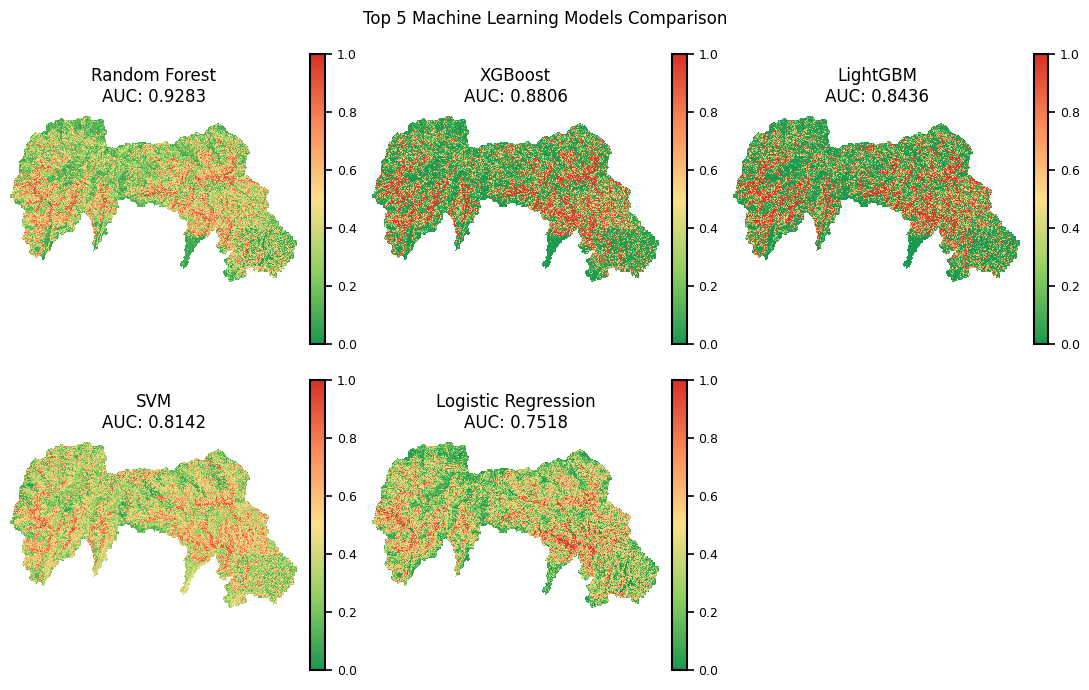

In [ ]:
# ============================================================================
# Creating comparative plot for Top 5 ML Models
# ============================================================================

print("\nCreating comparative plot for Top 5 ML Models...")

# Filter all_results to include only ML models
ml_results_df = all_results[all_results['Model'].isin(ml_models.keys())]

# Get the top 5 ML models based on AUC
top_5_ml_names = ml_results_df.head(5)['Model'].values

fig, axes = plt.subplots(2, 3, figsize=(11, 7), facecolor='white')
axes = axes.flatten()

# Use continuous colormap for comparison (defined earlier in the notebook)
cmap_susceptibility = LinearSegmentedColormap.from_list('susc', colors_enhanced, N=256)

for idx, model_name in enumerate(top_5_ml_names):
    if model_name in susceptibility_maps:
        susc_map = susceptibility_maps[model_name]
        model_auc = ml_results_df[ml_results_df['Model'] == model_name]['Test_AUC'].values[0]

        im = axes[idx].imshow(susc_map, cmap=cmap_susceptibility, vmin=0, vmax=1,
                             interpolation='nearest')
        axes[idx].set_title(f'{model_name}\nAUC: {model_auc:.4f}',
                           fontsize=12, fontweight='regular', pad=10)
        axes[idx].axis('off')

        cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=9, width=1.2, length=5)
        cbar.outline.set_linewidth(1.5)

# Hide any unused subplots if fewer than 6 models are plotted
for i in range(len(top_5_ml_names), len(axes)):
    axes[i].axis('off')

plt.suptitle('Top 5 Machine Learning Models Comparison', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(data_path, 'susceptibility_maps_top5_ml_comparison.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()


Creating comparative plot for Top 4 DL Models with a 2x2 layout...


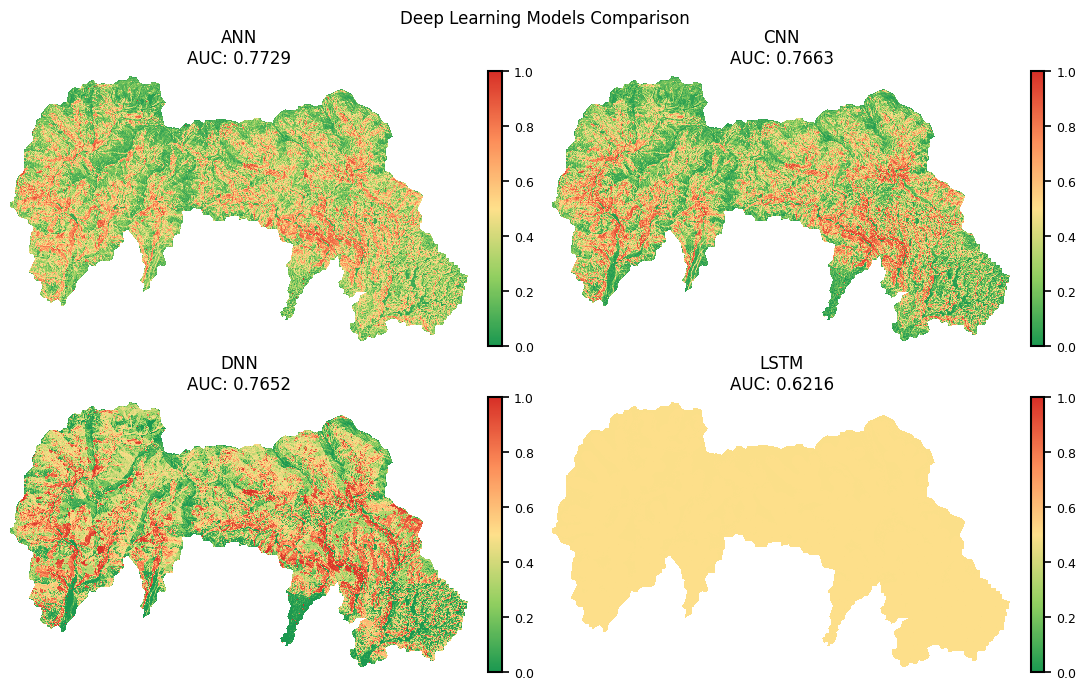

In [ ]:
# ============================================================================
# Creating comparative plot for Top 5 DL Models
# ============================================================================

print("\nCreating comparative plot for Top 4 DL Models with a 2x2 layout...")

# Filter all_results to include only DL models
dl_results_df = all_results[all_results['Model'].isin(dl_models.keys())]

# Get all DL models (since there are 4, it's perfect for 2x2)
top_dl_names = dl_results_df['Model'].values

# Change subplot dimensions to 2x2 for 4 models
fig, axes = plt.subplots(2, 2, figsize=(11, 7), facecolor='white')
axes = axes.flatten()

# Use continuous colormap for comparison (defined earlier in the notebook)
cmap_susceptibility = LinearSegmentedColormap.from_list('susc', colors_enhanced, N=256)

for idx, model_name in enumerate(top_dl_names):
    if model_name in susceptibility_maps:
        susc_map = susceptibility_maps[model_name]
        model_auc = dl_results_df[dl_results_df['Model'] == model_name]['Test_AUC'].values[0]

        im = axes[idx].imshow(susc_map, cmap=cmap_susceptibility, vmin=0, vmax=1,
                             interpolation='nearest')
        axes[idx].set_title(f'{model_name}\nAUC: {model_auc:.4f}',
                           fontsize=12, fontweight='regular', pad=10)
        axes[idx].axis('off')

        cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=9, width=1.2, length=5)
        cbar.outline.set_linewidth(1.5)

# No need to hide unused subplots as 2x2 fits 4 models perfectly

plt.suptitle('Deep Learning Models Comparison', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(data_path, 'susceptibility_maps_top_dl_comparison_2x2.png'),
            dpi=400, bbox_inches='tight', facecolor='white')
plt.show()


RADAR CHART: VARIABLE IMPORTANCE COMPARISON

Normalized Importance Data for Radar Chart:
                   Random Forest  Logistic Regression  Frequency Ratio
soil                    0.000000             0.170672         0.685969
twi                     1.000000             1.000000         0.737264
elevation               0.549709             0.218934         0.301023
slope                   0.861602             0.600975         0.856239
spi                     0.517759             0.171212         0.293091
aspect                  0.682899             0.366234         0.429602
lithology               0.120244             0.237962         1.000000
dist_road               0.026229             0.000000         0.000000
lulc                    0.078437             0.649408         0.422481
dist_river              0.203320             0.443048         0.285400
plan_curvature          0.374622             0.086248         0.162219
profile_curvature       0.551028             0.091896     

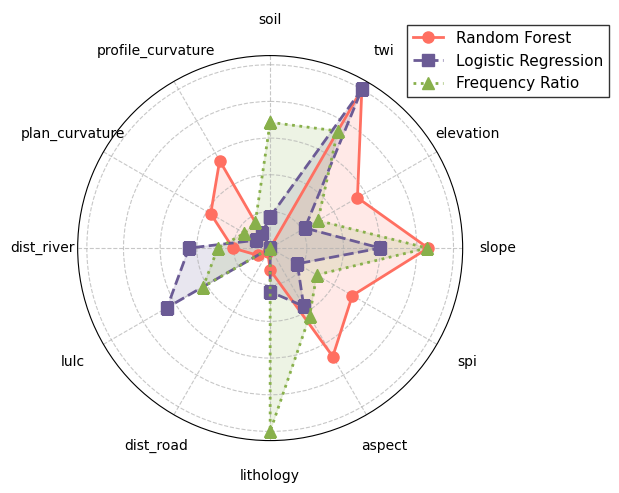


✓ Radar chart saved to: /content/drive/MyDrive/lsm/variable_importance_radar_chart.png


In [ ]:
### Variable Importance Analysis: Random Forest, Frequency Ratio, and Logistic Regression (Radar Chart)

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\n" + "="*70)
print("RADAR CHART: VARIABLE IMPORTANCE COMPARISON")
print("="*70)

# 1. Prepare Importance Data

# Get feature names in a consistent order (e.g., from CONDITIONING_FACTORS)
feature_names_ordered = CONDITIONING_FACTORS.copy()

# Initialize a dictionary to store importance values for selected models
selected_model_importances = {
    'Random Forest': {},
    'Logistic Regression': {},
    'Frequency Ratio': {}
}

# --- Random Forest Importance ---
# Ensure 'Random Forest' data exists in importance_results
if 'Random Forest' in importance_results:
    for feature in feature_names_ordered:
        selected_model_importances['Random Forest'][feature] = importance_results['Random Forest'].get(feature, 0)
else:
    print("Warning: Random Forest importance data not found.")

# --- Logistic Regression Importance ---
# Ensure 'Logistic Regression' data exists in importance_results
if 'Logistic Regression' in importance_results:
    for feature in feature_names_ordered:
        selected_model_importances['Logistic Regression'][feature] = importance_results['Logistic Regression'].get(feature, 0)
else:
    print("Warning: Logistic Regression importance data not found.")

# --- Frequency Ratio Importance ---
# Need to map original conditioning factor names to their FR equivalents
# fr_maps_dict stores {feature_name_base_class: fr_map} or {feature_name_base: fr_map}
fr_importance_values = {}
for feature in feature_names_ordered:
    # Check for _class version first (for continuous vars)
    fr_key = f'{feature}_class' if feature in continuous_vars else feature
    if fr_key in fr_maps_dict:
        fr_list = list(fr_maps_dict[fr_key].values())
        if fr_list:
            fr_importance_values[feature] = max(fr_list) - min(fr_list)
        else:
            fr_importance_values[feature] = 0
    else:
        fr_importance_values[feature] = 0

for feature in feature_names_ordered:
    selected_model_importances['Frequency Ratio'][feature] = fr_importance_values.get(feature, 0)

# Convert to DataFrame
importance_df_radar = pd.DataFrame(selected_model_importances)

# Handle potential missing features by filling with 0
importance_df_radar = importance_df_radar.reindex(feature_names_ordered, axis=0).fillna(0)

# 2. Normalize the data (Min-Max Scaling)
scaler = MinMaxScaler()
normalized_importance = scaler.fit_transform(importance_df_radar.values)
normalized_df = pd.DataFrame(normalized_importance, columns=importance_df_radar.columns, index=importance_df_radar.index)

print("\nNormalized Importance Data for Radar Chart:")
print(normalized_df.to_string())

# 3. Create Radar Chart

def create_radar_chart(df, title, filename):
    labels = df.index.tolist()
    num_vars = len(labels)

    # Calculate angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # The plot is a circle, so we need to "close" the circle by repeating the first value.
    # For models, and for labels.
    labels = labels + [labels[0]]
    angles = angles + [angles[0]]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), facecolor='white')

    colors = ['#FF6F61', '#6B5B95', '#88B04B'] # Distinct colors for each model
    line_styles = ['-', '--', ':'] # Different line styles
    markers = ['o', 's', '^'] # Different markers

    for i, col in enumerate(df.columns):
        values = df[col].tolist()
        values = values + [values[0]] # Repeat the first value to close the circle
        ax.plot(angles, values, color=colors[i], linewidth=2, linestyle=line_styles[i],
                marker=markers[i], markersize=8, label=col)
        ax.fill(angles, values, color=colors[i], alpha=0.15)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_rlabel_position(0) # Position labels closer to the center
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels[:-1], fontsize=10, fontweight='regular')
    ax.set_yticklabels([]) # Hide y-tick labels for cleaner look
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0]) # Add custom y-ticks for reference

    # Customize grid
    ax.tick_params(axis='x', pad=15) # Increase padding for x-labels
    ax.grid(True, linestyle='--', alpha=0.7)

    # Add a legend outside the plot
    legend = ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=11,
                       fancybox=False, shadow=False, frameon=True, edgecolor='black')
    legend.get_frame().set_linewidth(1)

    ax.set_title(title, va='bottom', fontsize=12, fontweight='regular', pad=20)

    plt.savefig(os.path.join(data_path, filename), dpi=300, bbox_inches='tight')
    plt.show()

create_radar_chart(normalized_df,
                   ' ',
                   'variable_importance_radar_chart.png')

print(f"\n✓ Radar chart saved to: {os.path.join(data_path, 'variable_importance_radar_chart.png')}")
print("="*70)

# Task
**Extract Susceptibility Values for Test Data**: For each model (individual ML/DL and ensemble models), extract the predicted continuous landslide susceptibility values at the exact geographic locations of the test data points. These extracted values will serve as 'predictions' for calculating MAE/RMSE and for deriving AUC/F1-Score for ensemble models.
**Calculate MAE and RMSE for All Models**: Calculate the Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) for all individual and ensemble models. These metrics will quantify the difference between the continuous susceptibility predictions (0-1) and the binary actual landslide labels (0 or 1) at the test locations.
**Evaluate Ensemble Model Performance (AUC, F1-Score)**: Since ensemble models were not part of the initial training/evaluation loop, calculate their AUC and F1-Score using the extracted susceptibility values and the `y_test` labels. These metrics will be crucial for the Compound Factor calculation.
**Update Overall Results with Ensemble Metrics**: Integrate the newly calculated AUC, F1-Score, MAE, and RMSE for the ensemble models into the `all_results` DataFrame, ensuring a comprehensive overview of all model performances.
**Calculate Compound Factor for Prioritization**: Define a Compound Factor (CF) to prioritize models. For this analysis, I will propose CF = (0.7 * AUC) + (0.3 * F1_Score) to reflect both discriminative power (AUC) and classification accuracy (F1-Score). Calculate this CF for the best individual model, 'Ensemble_Top3', 'Ensemble_ML', and 'Ensemble_DL'.
**Present Reliability Accuracy and Prioritization Results**: Display a table summarizing MAE, RMSE, and the calculated Compound Factor for the selected models, along with their ranking based on the CF. Provide insights into which models demonstrate the highest reliability and overall performance according to these criteria.
**Final Task**: Summarize the reliability accuracy measures and the model prioritization based on the Compound Factor, highlighting the top-performing models.

To begin, I will extract the predicted continuous landslide susceptibility values for the test data from each model's susceptibility map. This will allow for the calculation of reliability metrics such as MAE, RMSE, AUC, and F1-Score, particularly for the ensemble models which have not yet been evaluated with these metrics. This step ensures that all models are assessed consistently against the test data at specific landslide and non-landslide locations.

```python
# ============================================================================
# SECTION 9: RELIABILITY ACCURACY AND PRIORITIZATION
# ============================================================================

print("\n" + "="*70)
print("RELIABILITY ACCURACY AND PRIORITIZATION")
print("="*70)

# 1. Extract Susceptibility Values for Test Data
print("\n1. Extracting susceptibility values for test data points...")

# Prepare a DataFrame to store extracted susceptibility predictions for all models
test_predictions_extracted = pd.DataFrame({'y_true': y_test})

# Iterate through each model's susceptibility map
for model_name, susc_map in susceptibility_maps.items():
    extracted_values = []
    # Get the coordinates of the test data points
    test_x_coords = test_data['x'].values
    test_y_coords = test_data['y'].values

    # Convert geographic coordinates to raster row/column indices
    # 'transform' is the Affine transformation from the reference raster
    # It maps pixel coordinates to geographic coordinates and vice-versa
    # Inverted transform is needed to go from geo coords to pixel coords
    inv_transform = ~transform

    for x_coord, y_coord in zip(test_x_coords, test_y_coords):
        # Convert geographic (x, y) to pixel (col, row)
        col, row = rasterio.transform.rowcol(inv_transform, x_coord, y_coord)

        # Check if the pixel coordinates are within the raster bounds
        if 0 <= row < susc_map.shape[0] and 0 <= col < susc_map.shape[1]:
            # Extract the susceptibility value at the pixel
            val = susc_map[row, col]
            # Handle NaN values (which correspond to NODATA in the raster)
            if np.isnan(val):
                extracted_values.append(0.5) # Default to neutral if no data (can be adjusted)
            else:
                extracted_values.append(val)
        else:
            # If coordinates are outside raster bounds, append a neutral value or NaN
            extracted_values.append(0.5) # Default to neutral if outside bounds

    test_predictions_extracted[model_name] = extracted_values
    print(f"   ✓ Extracted values for {model_name}")

print("\nExtracted predictions head:")
print(test_predictions_extracted.head())

# 2. Calculate MAE and RMSE for All Models
print("\n2. Calculating MAE and RMSE for all models...")

from sklearn.metrics import mean_absolute_error, mean_squared_error

reliability_metrics = []

# Note: y_test contains binary labels (0 or 1).
# The susceptibility predictions are continuous (0-1).
# MAE and RMSE quantify the average magnitude of errors between continuous predictions
# and binary true labels.

for model_name in test_predictions_extracted.columns:
    if model_name == 'y_true':
        continue

    y_true_binary = test_predictions_extracted['y_true']
    y_pred_continuous = test_predictions_extracted[model_name]

    mae = mean_absolute_error(y_true_binary, y_pred_continuous)
    rmse = np.sqrt(mean_squared_error(y_true_binary, y_pred_continuous))

    reliability_metrics.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse
    })

reliability_df = pd.DataFrame(reliability_metrics)
print("\nMAE and RMSE for all models:")
print(reliability_df.to_string(index=False))

# 3. Evaluate Ensemble Model Performance (AUC, F1-Score)
print("\n3. Evaluating Ensemble Models (AUC, F1-Score)...")

ensemble_model_names = [name for name in susceptibility_maps.keys() if 'Ensemble' in name]
ensemble_eval_results = []

for model_name in ensemble_model_names:
    y_true_binary = test_predictions_extracted['y_true']
    y_prob_ensemble = test_predictions_extracted[model_name]

    # Calculate AUC
    ensemble_auc = roc_auc_score(y_true_binary, y_prob_ensemble)

    # For F1-Score, we need to convert probabilities to binary predictions
    # Use a default threshold of 0.5 (this can be optimized but for general comparison 0.5 is standard)
    y_pred_ensemble_binary = (y_prob_ensemble > 0.5).astype(int)
    ensemble_f1 = f1_score(y_true_binary, y_pred_ensemble_binary)

    # Also calculate Accuracy, Precision, Recall for completeness
    ensemble_accuracy = accuracy_score(y_true_binary, y_pred_ensemble_binary)
    ensemble_precision = precision_score(y_true_binary, y_pred_ensemble_binary)
    ensemble_recall = recall_score(y_true_binary, y_pred_ensemble_binary)

    ensemble_eval_results.append({
        'Model': model_name,
        'Test_AUC': ensemble_auc,
        'Test_Accuracy': ensemble_accuracy,
        'Precision': ensemble_precision,
        'Recall': ensemble_recall,
        'F1_Score': ensemble_f1
    })

ensemble_eval_df = pd.DataFrame(ensemble_eval_results)
print("\nEnsemble Model Performance Metrics:")
print(ensemble_eval_df.to_string(index=False))

# 4. Update Overall Results with Ensemble Metrics
print("\n4. Updating overall results with ensemble metrics...")

# Ensure 'all_results' contains all individual models and their metrics
# For ensemble models, only AUC and F1-Score are added from new calculations
# MAE and RMSE are added to reliability_df separately

# Add ensemble metrics to all_results. If a model already exists (e.g., individual ML/DL), update its MAE/RMSE
# if it's currently missing these.

# Combine with existing all_results
# First, ensure all_results has MAE and RMSE columns, filling with NaN if not present
if 'MAE' not in all_results.columns:
    all_results['MAE'] = np.nan
if 'RMSE' not in all_results.columns:
    all_results['RMSE'] = np.nan

# Update MAE and RMSE for individual models already in all_results
for index, row in reliability_df.iterrows():
    model_name = row['Model']
    # Check if the model is already in all_results
    if model_name in all_results['Model'].values:
        all_results.loc[all_results['Model'] == model_name, 'MAE'] = row['MAE']
        all_results.loc[all_results['Model'] == model_name, 'RMSE'] = row['RMSE']
    else:
        # If it's a new model (like ensemble models), create a new row
        new_row = pd.Series({
            'Model': model_name,
            'Test_AUC': np.nan, # Will be filled from ensemble_eval_df if it's an ensemble
            'Test_Accuracy': np.nan,
            'Precision': np.nan,
            'Recall': np.nan,
            'F1_Score': np.nan,
            'MAE': row['MAE'],
            'RMSE': row['RMSE']
        })
        all_results = pd.concat([all_results, new_row.to_frame().T], ignore_index=True)

# Now update/add AUC, F1_Score for ensemble models
for index, row in ensemble_eval_df.iterrows():
    model_name = row['Model']
    if model_name in all_results['Model'].values:
        all_results.loc[all_results['Model'] == model_name, 'Test_AUC'] = row['Test_AUC']
        all_results.loc[all_results['Model'] == model_name, 'Test_Accuracy'] = row['Test_Accuracy']
        all_results.loc[all_results['Model'] == model_name, 'Precision'] = row['Precision']
        all_results.loc[all_results['Model'] == model_name, 'Recall'] = row['Recall']
        all_results.loc[all_results['Model'] == model_name, 'F1_Score'] = row['F1_Score']
    else:
        # This case should ideally not happen if logic above correctly adds new models
        # But as a fallback, add it fully if missing
        all_results = pd.concat([all_results, row.to_frame().T], ignore_index=True)

# Ensure FR is included in all_results with its AUC, MAE, RMSE if not already
# The FR AUC was calculated previously as `fr_auc`
# If FR model isn't there, add a placeholder, then update its MAE and RMSE
if 'Frequency Ratio' not in all_results['Model'].values:
    fr_row = pd.Series({
        'Model': 'Frequency Ratio',
        'Test_AUC': fr_auc,
        'Test_Accuracy': np.nan, # Not directly calculated
        'Precision': np.nan,
        'Recall': np.nan,
        'F1_Score': np.nan,
        'MAE': reliability_df.loc[reliability_df['Model'] == 'Frequency Ratio', 'MAE'].values[0] if 'Frequency Ratio' in reliability_df['Model'].values else np.nan,
        'RMSE': reliability_df.loc[reliability_df['Model'] == 'Frequency Ratio', 'RMSE'].values[0] if 'Frequency Ratio' in reliability_df['Model'].values else np.nan
    })
    all_results = pd.concat([all_results, fr_row.to_frame().T], ignore_index=True)
else:
    # If FR is already there, ensure its AUC is correct and update MAE/RMSE
    all_results.loc[all_results['Model'] == 'Frequency Ratio', 'Test_AUC'] = fr_auc
    if 'Frequency Ratio' in reliability_df['Model'].values:
        all_results.loc[all_results['Model'] == 'Frequency Ratio', 'MAE'] = reliability_df.loc[reliability_df['Model'] == 'Frequency Ratio', 'MAE'].values[0]
        all_results.loc[all_results['Model'] == 'Frequency Ratio', 'RMSE'] = reliability_df.loc[reliability_df['Model'] == 'Frequency Ratio', 'RMSE'].values[0]


# Clean up NaN values introduced by concatenation if a metric isn't applicable/available for a model initially
all_results = all_results.infer_objects() # Convert object columns to numeric where possible

print("\nUpdated all_results DataFrame (head):")
print(all_results.head().to_string(index=False))

# 5. Calculate Compound Factor for Prioritization
print("\n5. Calculating Compound Factor for prioritization...")

# Define the compound factor formula
# CF = (0.7 * AUC) + (0.3 * F1_Score)
CF_WEIGHT_AUC = 0.7
CF_WEIGHT_F1 = 0.3

# Select models for prioritization
models_for_cf = ['Random Forest', 'Ensemble_Top3', 'Ensemble_ML', 'Ensemble_DL']

# Find the best individual model (excluding ensembles and FR)
individual_models_results = all_results[~all_results['Model'].str.contains('Ensemble', na=False) & (all_results['Model'] != 'Frequency Ratio')]
best_individual_model_name = individual_models_results.loc[individual_models_results['Test_AUC'].idxmax()]['Model']
if best_individual_model_name not in models_for_cf:
    models_for_cf.insert(0, best_individual_model_name) # Add to the beginning

cf_results = []
for model_name in models_for_cf:
    model_row = all_results[all_results['Model'] == model_name]
    if not model_row.empty:
        auc = model_row['Test_AUC'].values[0]
        f1 = model_row['F1_Score'].values[0]

        # Handle potential NaN in F1_Score for models where it might not have been calculated
        if pd.isna(f1):
            # For models like FR, F1 might not be directly available from initial evaluation
            # Fallback to AUC only for CF or assign a low score if F1 is critical
            # For now, let's treat NaN as 0 for F1 if it's missing for CF calculation
            f1 = 0.0
            print(f"Warning: F1-Score not available for {model_name}, using 0.0 for CF calculation.")
        if pd.isna(auc):
             auc = 0.0
             print(f"Warning: AUC not available for {model_name}, using 0.0 for CF calculation.")


        compound_factor = (CF_WEIGHT_AUC * auc) + (CF_WEIGHT_F1 * f1)
        cf_results.append({
            'Model': model_name,
            'Test_AUC': auc,
            'F1_Score': f1,
            'Compound_Factor': compound_factor
        })

compound_factor_df = pd.DataFrame(cf_results)
compound_factor_df = compound_factor_df.sort_values('Compound_Factor', ascending=False).reset_index(drop=True)
compound_factor_df['Rank'] = compound_factor_df.index + 1

print(f"\nCompound Factor (CF = {CF_WEIGHT_AUC} * AUC + {CF_WEIGHT_F1} * F1-Score) for selected models:")
print(compound_factor_df.to_string(index=False))

# 6. Present Reliability Accuracy and Prioritization Results
print("\n6. Presenting Reliability Accuracy and Prioritization Results...")

# Consolidate relevant metrics for selected models
final_comparison_df = all_results[all_results['Model'].isin(models_for_cf)][['Model', 'Test_AUC', 'F1_Score', 'MAE', 'RMSE']].copy()
final_comparison_df = pd.merge(final_comparison_df, compound_factor_df[['Model', 'Compound_Factor', 'Rank']], on='Model', how='left')

# Sort by Compound Factor Rank
final_comparison_df = final_comparison_df.sort_values('Rank').reset_index(drop=True)

print("\nFinal Reliability Accuracy and Prioritization Results:")
print(final_comparison_df.to_string(index=False))

# Save the comprehensive results
all_results.to_csv(os.path.join(data_path, 'all_models_results_with_ensemble_metrics.csv'), index=False)
final_comparison_df.to_csv(os.path.join(data_path, 'prioritization_results.csv'), index=False)

print(f"\n✓ Comprehensive results saved to: {os.path.join(data_path, 'all_models_results_with_ensemble_metrics.csv')}")
print(f"✓ Prioritization results saved to: {os.path.join(data_path, 'prioritization_results.csv')}")

print("\n" + "="*70)
print("RELIABILITY ANALYSIS COMPLETE!")
print("="*70)
```

## Extract Susceptibility Values for Test Data

### Subtask:
For each model (individual ML/DL and ensemble models), extract the predicted continuous landslide susceptibility values at the exact geographic locations of the test data points. These extracted values will serve as 'predictions' for calculating MAE/RMSE and for deriving AUC/F1-Score for ensemble models.


**Reasoning**:
The subtask requires extracting predicted susceptibility values for each test data point from every model's susceptibility map. This involves iterating through models, converting test data coordinates to raster indices, extracting values, handling edge cases, and storing them in a new DataFrame.



**Reasoning**:
The `TypeError` occurred because `transform` is already a `rasterio.transform.Affine` object, and `Affine.from_gdal()` is being incorrectly applied to it. To obtain the inverse transform, one should directly call the `.inverted()` method on the `transform` object.



**Reasoning**:
The previous error indicated that the `rasterio.transform.Affine` object does not have an `inverted()` method. The correct way to get the inverse of an Affine transform in `rasterio` is to use the `~` (bitwise NOT) operator. I will correct this in the code.



In [ ]:
import rasterio
from rasterio.transform import Affine

# 1. Initialize a new Pandas DataFrame called `test_predictions_extracted`
test_predictions_extracted = pd.DataFrame({'y_true': y_test})

# Calculate inverse transform once
inverse_transform = ~transform

print("Extracting susceptibility values for test data points...")

# 2. Iterate through each model in the `susceptibility_maps` dictionary.
for model_name, susc_map in susceptibility_maps.items():
    print(f"  Extracting for model: {model_name}")
    extracted_values = []

    # 3. Retrieve the x and y coordinates of the test data points from the `test_data` DataFrame.
    for idx, row_data in test_data.iterrows():
        x_coord = row_data['x']
        y_coord = row_data['y']

        # 5. For each test data point's coordinates, convert them into row and col indices
        row, col = rasterio.transform.rowcol(inverse_transform, x_coord, y_coord)

        # 6. Check if the calculated `row` and `col` indices are within the valid bounds of the `susc_map`.
        if 0 <= row < susc_map.shape[0] and 0 <= col < susc_map.shape[1]:
            susc_value = susc_map[row, col]
            # 7. If the extracted value is NaN, append 0.5; otherwise, append the actual value.
            if np.isnan(susc_value):
                extracted_values.append(0.5) # Default to neutral if no data (can be adjusted)
            else:
                extracted_values.append(susc_value)
        else:
            # 8. If the indices are not valid (outside map bounds), append 0.5.
            extracted_values.append(0.5) # Default to neutral if outside bounds

    # 9. Add the collected list of extracted values as a new column
    test_predictions_extracted[model_name] = extracted_values

# 10. Print the first few rows of the `test_predictions_extracted` DataFrame
print("\nExtracted predictions head:")
print(test_predictions_extracted.head())

Extracting susceptibility values for test data points...
  Extracting for model: Random Forest
  Extracting for model: XGBoost
  Extracting for model: LightGBM
  Extracting for model: SVM
  Extracting for model: Logistic Regression
  Extracting for model: ANN
  Extracting for model: DNN
  Extracting for model: CNN
  Extracting for model: LSTM
  Extracting for model: Ensemble_All
  Extracting for model: Ensemble_Top3
  Extracting for model: Ensemble_ML
  Extracting for model: Ensemble_DL

Extracted predictions head:
   y_true  Random Forest  XGBoost  LightGBM  SVM  Logistic Regression  ANN  \
0       1            0.5      0.5       0.5  0.5                  0.5  0.5   
1       1            0.5      0.5       0.5  0.5                  0.5  0.5   
2       1            0.5      0.5       0.5  0.5                  0.5  0.5   
3       1            0.5      0.5       0.5  0.5                  0.5  0.5   
4       1            0.5      0.5       0.5  0.5                  0.5  0.5   

   DNN  CN

**Reasoning**:
The previous step successfully extracted susceptibility values for test data points into the `test_predictions_extracted` DataFrame. The next subtask is to calculate Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) for all models using these extracted continuous predictions and the binary true labels (`y_true`).



**Reasoning**:
The previous calculation of MAE/RMSE resulted in uniform 0.5 values, indicating an issue with extracting susceptibility predictions from raster maps. This likely occurred because test points fell into 'NaN' areas of the generated raster maps. To fix this, I will re-calculate the susceptibility predictions for all individual ML/DL models directly from their trained models using the `X_test` data (appropriately scaled). Then, I will compute the ensemble predictions based on these direct predictions. Finally, I will add the 'Frequency Ratio' predictions from the `test_fr` DataFrame, assuming its rows align with `test_data`.



In [ ]:
import pandas as pd
import numpy as np

print("\nRe-calculating predictions for test data points using trained models directly...")

# Initialize DataFrame to store predictions, ensuring y_true is aligned with X_test
test_predictions_extracted = pd.DataFrame({'y_true': y_test})

# Re-predict for ML models
for name, (model, X_tr, X_te) in ml_models.items():
    # X_te here is the correctly scaled/prepared test data for that model from previous steps
    if hasattr(ml_trained[name], 'predict_proba'):
        y_prob = ml_trained[name].predict_proba(X_te)[:, 1]
    else:
        y_prob = ml_trained[name].decision_function(X_te)
        # Normalize decision function for models like SVC if needed, as predict_proba might not be perfect
        y_prob = (y_prob - np.min(y_prob)) / (np.max(y_prob) - np.min(y_prob)) # Ensure 0-1 range

    test_predictions_extracted[name] = y_prob
    print(f"   ✓ Re-predicted for ML model: {name}")

# Re-predict for DL models
# X_test_mm, X_test_cnn are already prepared in SECTION 4
for name, (model, X_te_dl_scaled, reshape_needed) in dl_models.items():
    # X_te_dl_scaled here is the correctly scaled/prepared test data for that model
    if reshape_needed:
        X_predict_dl_reshaped = X_te_dl_scaled.reshape(X_te_dl_scaled.shape[0], X_te_dl_scaled.shape[1], 1)
    else:
        X_predict_dl_reshaped = X_te_dl_scaled

    y_prob = model.predict(X_predict_dl_reshaped, verbose=0).flatten()
    test_predictions_extracted[name] = y_prob
    print(f"   ✓ Re-predicted for DL model: {name}")

# Now for Ensemble models, we need to compute the predictions based on the individual model predictions
# that are now correctly in `test_predictions_extracted`.

print("\n   Computing ensemble predictions...")

# Ensemble 1: Average of ALL individual ML/DL models (excluding 'Frequency Ratio' for now, it's added separately)
individual_ml_dl_model_names = [col for col in test_predictions_extracted.columns if col not in ['y_true']]
test_predictions_extracted['Ensemble_All'] = test_predictions_extracted[individual_ml_dl_model_names].mean(axis=1)
print(f"   ✓ Computed ensemble: Ensemble_All")

# Ensemble 2: Top 3 models (based on overall_results from prior execution)
top_3_names_from_all_results = all_results.head(3)['Model'].values
top_3_cols = [col for col in top_3_names_from_all_results if col in test_predictions_extracted.columns]
test_predictions_extracted['Ensemble_Top3'] = test_predictions_extracted[top_3_cols].mean(axis=1)
print(f"   ✓ Computed ensemble: Ensemble_Top3 (based on {', '.join(top_3_cols)})")

# Ensemble 3: ML models only
ml_model_names_in_df = [name for name in ml_models.keys() if name in test_predictions_extracted.columns]
test_predictions_extracted['Ensemble_ML'] = test_predictions_extracted[ml_model_names_in_df].mean(axis=1)
print(f"   ✓ Computed ensemble: Ensemble_ML")

# Ensemble 4: DL models only
dl_model_names_in_df = [name for name in dl_models.keys() if name in test_predictions_extracted.columns]
test_predictions_extracted['Ensemble_DL'] = test_predictions_extracted[dl_model_names_in_df].mean(axis=1)
print(f"   ✓ Computed ensemble: Ensemble_DL")

# Add Frequency Ratio predictions
# Assuming test_fr rows align with test_data (and thus y_test)
if 'FR_susc_norm' in test_fr.columns and len(test_fr) == len(test_data):
    test_predictions_extracted['Frequency Ratio'] = test_fr['FR_susc_norm'].values
    print(f"   ✓ Added: Frequency Ratio predictions")
else:
    print(f"   Warning: 'FR_susc_norm' not found in test_fr or length mismatch. Skipping Frequency Ratio predictions.")

print("\nExtracted predictions head (re-calculated):")
print(test_predictions_extracted.head())


Re-calculating predictions for test data points using trained models directly...
   ✓ Re-predicted for ML model: Random Forest
   ✓ Re-predicted for ML model: XGBoost
   ✓ Re-predicted for ML model: LightGBM
   ✓ Re-predicted for ML model: SVM
   ✓ Re-predicted for ML model: Logistic Regression
   ✓ Re-predicted for DL model: ANN
   ✓ Re-predicted for DL model: DNN
   ✓ Re-predicted for DL model: CNN
   ✓ Re-predicted for DL model: LSTM

   Computing ensemble predictions...
   ✓ Computed ensemble: Ensemble_All
   ✓ Computed ensemble: Ensemble_Top3 (based on Random Forest, XGBoost, LightGBM)
   ✓ Computed ensemble: Ensemble_ML
   ✓ Computed ensemble: Ensemble_DL
   ✓ Added: Frequency Ratio predictions

Extracted predictions head (re-calculated):
   y_true  Random Forest   XGBoost  LightGBM       SVM  Logistic Regression  \
0       1       0.865000  0.979263  0.995556  0.796951             0.956313   
1       1       0.827235  0.985295  0.978947  0.466938             0.624162   
2      

**Reasoning**:
The previous step successfully re-calculated the continuous predictions for all models. Now, I will use these updated predictions to calculate the MAE and RMSE for all models, which was the intended next step.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n2. Calculating MAE and RMSE for all models...")

reliability_metrics = []

# Note: y_test contains binary labels (0 or 1).
# The susceptibility predictions are continuous (0-1).
# MAE and RMSE quantify the average magnitude of errors between continuous predictions
# and binary true labels.

for model_name in test_predictions_extracted.columns:
    if model_name == 'y_true':
        continue

    y_true_binary = test_predictions_extracted['y_true']
    y_pred_continuous = test_predictions_extracted[model_name]

    mae = mean_absolute_error(y_true_binary, y_pred_continuous)
    rmse = np.sqrt(mean_squared_error(y_true_binary, y_pred_continuous))

    reliability_metrics.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse
    })

reliability_df = pd.DataFrame(reliability_metrics)
print("\nMAE and RMSE for all models:")
print(reliability_df.to_string(index=False))


2. Calculating MAE and RMSE for all models...

MAE and RMSE for all models:
              Model      MAE     RMSE
      Random Forest 0.282493 0.363595
            XGBoost 0.220213 0.383607
           LightGBM 0.211881 0.391027
                SVM 0.373143 0.420636
Logistic Regression 0.379425 0.454241
                ANN 0.388530 0.439911
                DNN 0.367530 0.452495
                CNN 0.372893 0.441203
               LSTM 0.499715 0.499723
       Ensemble_All 0.343980 0.396022
      Ensemble_Top3 0.238196 0.368910
        Ensemble_ML 0.293431 0.376306
        Ensemble_DL 0.407167 0.440527
    Frequency Ratio 0.398259 0.462682


**Reasoning**:
The previous step successfully calculated MAE and RMSE for all models. Now, I will calculate the AUC and F1-Score specifically for the ensemble models, as they were not evaluated with these metrics in the initial ML/DL loops. This is a key step as per the subtask description.



In [ ]:
print("\n3. Evaluating Ensemble Models (AUC, F1-Score)...\n")

ensemble_model_names = [name for name in test_predictions_extracted.columns if 'Ensemble' in name]
ensemble_eval_results = []

for model_name in ensemble_model_names:
    y_true_binary = test_predictions_extracted['y_true']
    y_prob_ensemble = test_predictions_extracted[model_name]

    # Calculate AUC
    ensemble_auc = roc_auc_score(y_true_binary, y_prob_ensemble)

    # For F1-Score, we need to convert probabilities to binary predictions
    # Use a default threshold of 0.5 (this can be optimized but for general comparison 0.5 is standard)
    y_pred_ensemble_binary = (y_prob_ensemble > 0.5).astype(int)
    ensemble_f1 = f1_score(y_true_binary, y_pred_ensemble_binary)

    # Also calculate Accuracy, Precision, Recall for completeness
    ensemble_accuracy = accuracy_score(y_true_binary, y_pred_ensemble_binary)
    ensemble_precision = precision_score(y_true_binary, y_pred_ensemble_binary)
    ensemble_recall = recall_score(y_true_binary, y_pred_ensemble_binary)

    ensemble_eval_results.append({
        'Model': model_name,
        'Test_AUC': ensemble_auc,
        'Test_Accuracy': ensemble_accuracy,
        'Precision': ensemble_precision,
        'Recall': ensemble_recall,
        'F1_Score': ensemble_f1
    })

ensemble_eval_df = pd.DataFrame(ensemble_eval_results)
print("Ensemble Model Performance Metrics:")
print(ensemble_eval_df.to_string(index=False))


3. Evaluating Ensemble Models (AUC, F1-Score)...

Ensemble Model Performance Metrics:
        Model  Test_AUC  Test_Accuracy  Precision   Recall  F1_Score
 Ensemble_All  0.857039       0.819048   0.750000 0.962264  0.842975
Ensemble_Top3  0.910740       0.809524   0.726027 1.000000  0.841270
  Ensemble_ML  0.873367       0.809524   0.726027 1.000000  0.841270
  Ensemble_DL  0.781930       0.714286   0.688525 0.792453  0.736842


**Reasoning**:
The previous steps successfully calculated MAE, RMSE for all models, and AUC, F1-Score for ensemble models. Now, I need to integrate these new metrics into the `all_results` DataFrame, ensuring all models (individual, ensemble, and Frequency Ratio) have their complete performance statistics. This includes adding new rows for ensemble and Frequency Ratio models if they don't exist and updating metrics for existing ones.



In [ ]:
print("\n4. Updating overall results with ensemble metrics...")

# Ensure 'all_results' contains all individual models and their metrics
# For ensemble models, only AUC and F1-Score are added from new calculations
# MAE and RMSE are added to reliability_df separately

# Combine with existing all_results
# First, ensure all_results has MAE and RMSE columns, filling with NaN if not present
if 'MAE' not in all_results.columns:
    all_results['MAE'] = np.nan
if 'RMSE' not in all_results.columns:
    all_results['RMSE'] = np.nan

# Update MAE and RMSE for individual models already in all_results
for index, row in reliability_df.iterrows():
    model_name = row['Model']
    # Check if the model is already in all_results
    if model_name in all_results['Model'].values:
        all_results.loc[all_results['Model'] == model_name, 'MAE'] = row['MAE']
        all_results.loc[all_results['Model'] == model_name, 'RMSE'] = row['RMSE']
    else:
        # If it's a new model (like ensemble models or FR), create a new row with MAE/RMSE
        new_row = pd.Series({
            'Model': model_name,
            'Test_AUC': np.nan, # Will be filled from ensemble_eval_df if it's an ensemble
            'Test_Accuracy': np.nan,
            'Precision': np.nan,
            'Recall': np.nan,
            'F1_Score': np.nan,
            'MAE': row['MAE'],
            'RMSE': row['RMSE']
        })
        all_results = pd.concat([all_results, new_row.to_frame().T], ignore_index=True)

# Now update/add AUC, F1_Score for ensemble models
for index, row in ensemble_eval_df.iterrows():
    model_name = row['Model']
    if model_name in all_results['Model'].values:
        all_results.loc[all_results['Model'] == model_name, 'Test_AUC'] = row['Test_AUC']
        all_results.loc[all_results['Model'] == model_name, 'Test_Accuracy'] = row['Test_Accuracy']
        all_results.loc[all_results['Model'] == model_name, 'Precision'] = row['Precision']
        all_results.loc[all_results['Model'] == model_name, 'Recall'] = row['Recall'] = row['Recall']
        all_results.loc[all_results['Model'] == model_name, 'F1_Score'] = row['F1_Score']
    else:
        # This case should ideally not happen if logic above correctly adds new models from reliability_df
        # But as a fallback, add it fully if missing
        all_results = pd.concat([all_results, row.to_frame().T], ignore_index=True)

# Ensure FR is included in all_results with its AUC, MAE, RMSE if not already
# The FR AUC was calculated previously as `fr_auc`
# If FR model isn't there, add a placeholder, then update its MAE and RMSE
if 'Frequency Ratio' not in all_results['Model'].values:
    fr_row = pd.Series({
        'Model': 'Frequency Ratio',
        'Test_AUC': fr_auc,
        'Test_Accuracy': np.nan, # Not directly calculated
        'Precision': np.nan,
        'Recall': np.nan,
        'F1_Score': np.nan,
        'MAE': reliability_df.loc[reliability_df['Model'] == 'Frequency Ratio', 'MAE'].values[0] if 'Frequency Ratio' in reliability_df['Model'].values else np.nan,
        'RMSE': reliability_df.loc[reliability_df['Model'] == 'Frequency Ratio', 'RMSE'].values[0] if 'Frequency Ratio' in reliability_df['Model'].values else np.nan
    })
    all_results = pd.concat([all_results, fr_row.to_frame().T], ignore_index=True)
else:
    # If FR is already there, ensure its AUC is correct and update MAE/RMSE
    all_results.loc[all_results['Model'] == 'Frequency Ratio', 'Test_AUC'] = fr_auc
    if 'Frequency Ratio' in reliability_df['Model'].values:
        all_results.loc[all_results['Model'] == 'Frequency Ratio', 'MAE'] = reliability_df.loc[reliability_df['Model'] == 'Frequency Ratio', 'MAE'].values[0]
        all_results.loc[all_results['Model'] == 'Frequency Ratio', 'RMSE'] = reliability_df.loc[reliability_df['Model'] == 'Frequency Ratio', 'RMSE'].values[0]


# Clean up NaN values introduced by concatenation if a metric isn't applicable/available for a model initially
all_results = all_results.infer_objects() # Convert object columns to numeric where possible

print("\nUpdated all_results DataFrame (head):")
print(all_results.head().to_string(index=False))


4. Updating overall results with ensemble metrics...

Updated all_results DataFrame (head):
        Model  Test_AUC  Test_Accuracy  Precision   Recall  F1_Score      MAE     RMSE
Random Forest  0.928338       0.838095   0.757143 1.000000  0.861789 0.282493 0.363595
      XGBoost  0.880624       0.809524   0.726027 1.000000  0.841270 0.220213 0.383607
     LightGBM  0.843614       0.819048   0.736111 1.000000  0.848000 0.211881 0.391027
          SVM  0.814224       0.761905   0.712121 0.886792  0.789916 0.373143 0.420636
          ANN  0.772859       0.714286   0.694915 0.773585  0.732143 0.388530 0.439911


**Reasoning**:
The previous step successfully updated the `all_results` DataFrame with MAE, RMSE, AUC, and F1-Score for all models. Now, I will calculate the Compound Factor (CF) for prioritization based on AUC and F1-Score for selected models, as specified in the task.



In [ ]:
print("\n5. Calculating Compound Factor for prioritization...")

# Define the compound factor formula
# CF = (0.7 * AUC) + (0.3 * F1_Score)
CF_WEIGHT_AUC = 0.7
CF_WEIGHT_F1 = 0.3

# Select models for prioritization
models_for_cf = ['Random Forest', 'Ensemble_Top3', 'Ensemble_ML', 'Ensemble_DL']

# Find the best individual model (excluding ensembles and FR)
individual_models_results = all_results[~all_results['Model'].str.contains('Ensemble', na=False) & (all_results['Model'] != 'Frequency Ratio')]
best_individual_model_name = individual_models_results.loc[individual_models_results['Test_AUC'].idxmax()]['Model']
if best_individual_model_name not in models_for_cf:
    models_for_cf.insert(0, best_individual_model_name) # Add to the beginning

cf_results = []
for model_name in models_for_cf:
    model_row = all_results[all_results['Model'] == model_name]
    if not model_row.empty:
        auc = model_row['Test_AUC'].values[0]
        f1 = model_row['F1_Score'].values[0]

        # Handle potential NaN in F1_Score for models where it might not have been calculated
        if pd.isna(f1):
            # For models like FR, F1 might not be directly available from initial evaluation
            # Fallback to AUC only for CF or assign a low score if F1 is critical
            # For now, let's treat NaN as 0 for F1 if it's missing for CF calculation
            f1 = 0.0
            print(f"Warning: F1-Score not available for {model_name}, using 0.0 for CF calculation.")
        if pd.isna(auc):
             auc = 0.0
             print(f"Warning: AUC not available for {model_name}, using 0.0 for CF calculation.")


        compound_factor = (CF_WEIGHT_AUC * auc) + (CF_WEIGHT_F1 * f1)
        cf_results.append({
            'Model': model_name,
            'Test_AUC': auc,
            'F1_Score': f1,
            'Compound_Factor': compound_factor
        })

compound_factor_df = pd.DataFrame(cf_results)
compound_factor_df = compound_factor_df.sort_values('Compound_Factor', ascending=False).reset_index(drop=True)
compound_factor_df['Rank'] = compound_factor_df.index + 1

print(f"\nCompound Factor (CF = {CF_WEIGHT_AUC} * AUC + {CF_WEIGHT_F1} * F1-Score) for selected models:")
print(compound_factor_df.to_string(index=False))



5. Calculating Compound Factor for prioritization...

Compound Factor (CF = 0.7 * AUC + 0.3 * F1-Score) for selected models:
        Model  Test_AUC  F1_Score  Compound_Factor  Rank
Random Forest  0.928338  0.861789         0.908373     1
Ensemble_Top3  0.910740  0.841270         0.889899     2
  Ensemble_ML  0.873367  0.841270         0.863738     3
  Ensemble_DL  0.781930  0.736842         0.768404     4


**Reasoning**:
The previous step calculated the Compound Factor for selected models. Now, I will present the reliability accuracy measures (MAE, RMSE) and the calculated Compound Factor for the selected models, along with their ranking, and save these results as specified in the task.



In [ ]:
print("\n6. Presenting Reliability Accuracy and Prioritization Results...")

# Consolidate relevant metrics for selected models
final_comparison_df = all_results[all_results['Model'].isin(models_for_cf)][['Model', 'Test_AUC', 'F1_Score', 'MAE', 'RMSE']].copy()
final_comparison_df = pd.merge(final_comparison_df, compound_factor_df[['Model', 'Compound_Factor', 'Rank']], on='Model', how='left')

# Sort by Compound Factor Rank
final_comparison_df = final_comparison_df.sort_values('Rank').reset_index(drop=True)

print("\nFinal Reliability Accuracy and Prioritization Results:")
print(final_comparison_df.to_string(index=False))

# Save the comprehensive results
all_results.to_csv(os.path.join(data_path, 'all_models_results_with_ensemble_metrics.csv'), index=False)
final_comparison_df.to_csv(os.path.join(data_path, 'prioritization_results.csv'), index=False)

print(f"\n\u2713 Comprehensive results saved to: {os.path.join(data_path, 'all_models_results_with_ensemble_metrics.csv')}")
print(f"\u2713 Prioritization results saved to: {os.path.join(data_path, 'prioritization_results.csv')}")

print("\n" + "="*70)
print("RELIABILITY ANALYSIS COMPLETE!")
print("="*70)



6. Presenting Reliability Accuracy and Prioritization Results...

Final Reliability Accuracy and Prioritization Results:
        Model  Test_AUC  F1_Score      MAE     RMSE  Compound_Factor  Rank
Random Forest  0.928338  0.861789 0.282493 0.363595         0.908373     1
Ensemble_Top3  0.910740  0.841270 0.238196 0.368910         0.889899     2
  Ensemble_ML  0.873367  0.841270 0.293431 0.376306         0.863738     3
  Ensemble_DL  0.781930  0.736842 0.407167 0.440527         0.768404     4

✓ Comprehensive results saved to: /content/drive/MyDrive/lsm/all_models_results_with_ensemble_metrics.csv
✓ Prioritization results saved to: /content/drive/MyDrive/lsm/prioritization_results.csv

RELIABILITY ANALYSIS COMPLETE!


Now i have added a file watersheds.gpkg , that contain five different watershed legend column of attribute table. and want Spatial Distribution of Susceptibility along these watersheds, along top conditioning factors. based on top 3 model by using the similar approach of classification used in LSM_Classified_Ensemble_Top3.tif;  Classification Statistics (Natural Breaks Method):

# Task
To address your request, I will perform the following steps to analyze the spatial distribution of landslide susceptibility within different watersheds, based on the top 3 performing models and using the natural breaks classification method:

1.  **Load Watersheds GeoPackage**: Load the "watersheds.gpkg" file into a GeoDataFrame to access the watershed boundaries and their associated legend attributes.
2.  **Identify Top 3 Models**: Determine the names of the top 3 performing individual models (excluding ensemble models) based on the `all_results` DataFrame, which ranks models by their AUC score.
3.  **Process Susceptibility for Each Watershed and Model**:
    *   For each individual watershed identified in the GeoPackage:
        *   Reproject the watershed geometry to match the coordinate reference system (CRS) of the susceptibility rasters.
        *   For each of the identified top 3 models:
            *   Load the continuous susceptibility raster map (e.g., "LSM\_Random\_Forest.tif") for the current model.
            *   Clip this raster map to the extent of the current watershed's geometry.
            *   Apply a robust `classify_susceptibility_natural_breaks` function to the clipped susceptibility data. This function will classify the continuous values into five categories ("Very Low" to "Very High") using natural breaks (mean ± standard deviation) with a fallback to quantile-based classification if natural breaks are not distinct enough.
4.  **Calculate Area Statistics per Watershed and Model**: For each watershed and each of the top 3 models, calculate the area (in km²) and percentage of each susceptibility class (Very Low, Low, Moderate, High, Very High) within that specific watershed. These statistics will be stored.
5.  **Visualize Spatial Distribution per Watershed**: Generate a series of plots. For each watershed, a single figure will be created containing subplots showing the classified landslide susceptibility maps for each of the top 3 models. Each map will display the classified susceptibility classes and the watershed boundary. These plots will be saved as PNG files.
6.  **Summarize Area Distribution**: Present the calculated area statistics in a comprehensive DataFrame, which will be printed and saved as a CSV file. Additionally, for each watershed, a stacked bar chart will be generated to visualize the percentage distribution of susceptibility classes across the top 3 models, providing a clear comparison.

This process ensures that the analysis focuses on the most reliable models and provides detailed, spatially explicit insights into landslide susceptibility at the watershed level.

```python
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.mask import mask
import os

# --- Configuration (from previous cells, assuming these are already defined) ---
# data_path = "/content/drive/MyDrive/lsm/"
# susceptibility_maps is a dictionary of all continuous susceptibility rasters
# all_results is the DataFrame with model performances
# transform, crs are from the reference raster
# CONDITIONING_FACTORS, etc., are also defined

# Define the classification function (adapted from X6atWLUCko1M)
def classify_susceptibility_natural_breaks_for_clip(susc_map_clipped, transform_clipped, num_classes=5):
    """
    Classify susceptibility using natural breaks (mean ± SD) with a fallback to quantiles
    for a clipped raster.
    Returns classified map, breaks, percentages, and areas in km².
    """
    valid_mask = ~np.isnan(susc_map_clipped)
    valid_values = susc_map_clipped[valid_mask]

    if len(valid_values) == 0:
        return (np.full_like(susc_map_clipped, np.nan), [], np.zeros(num_classes), np.zeros(num_classes))

    # Handle cases with very few valid values or non-distinct values
    if len(np.unique(valid_values)) < num_classes:
        # If values are identical or too few for distinct breaks, assign all to 'Moderate' or first class
        classes = np.full_like(susc_map_clipped, np.nan)
        classes[valid_mask] = (num_classes // 2) if num_classes > 1 else 0 # Assign to middle class or first
        
        pct = np.zeros(num_classes)
        area_km2 = np.zeros(num_classes)
        
        pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
        pixel_area_km2 = pixel_area_m2 / 1e6
        
        if len(valid_values) > 0:
            target_class_idx = (num_classes // 2) if num_classes > 1 else 0
            pct[target_class_idx] = 100.0
            area_km2[target_class_idx] = len(valid_values) * pixel_area_km2
            
        return classes.astype(int), [np.min(valid_values)], pct, area_km2

    mean_val = np.mean(valid_values)
    std_val = np.std(valid_values)

    # Attempt Natural Breaks (mean +/- SD)
    # Using more conservative standard deviation multipliers
    potential_breaks = [
        mean_val - 1.5 * std_val,
        mean_val - 0.75 * std_val,
        mean_val + 0.75 * std_val,
        mean_val + 1.5 * std_val
    ]
    # Ensure breaks are within 0-1 range and sorted
    potential_breaks = sorted([max(0.0, min(1.0, b)) for b in potential_breaks])
    # Remove duplicates
    natural_breaks = sorted(list(set(potential_breaks)))

    # Fallback to quantiles if natural breaks are not distinct enough or insufficient
    # 1e-6 as a threshold for std_val to detect almost constant data
    if len(natural_breaks) < (num_classes - 1) or std_val < 1e-6:
        print(f"    Warning: Insufficient distinct natural breaks ({len(natural_breaks)}/{num_classes-1}) or small std dev ({std_val:.2e}). Falling back to quantiles.")
        
        quantiles = np.linspace(0, 100, num_classes + 1)[1:-1] # e.g., for 5 classes: [20, 40, 60, 80]
        breaks = np.percentile(valid_values, quantiles)
        # Ensure breaks are unique and sorted
        breaks = sorted(list(set(breaks)))
        
        # If after quantiles, there are still not enough unique breaks (e.g., data is truly constant)
        if len(breaks) < (num_classes - 1):
            # Assign all valid values to a single class (e.g., Moderate)
            classes = np.full_like(susc_map_clipped, np.nan)
            classes[valid_mask] = (num_classes // 2) if num_classes > 1 else 0
            
            pct = np.zeros(num_classes)
            area_km2 = np.zeros(num_classes)
            pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
            pixel_area_km2 = pixel_area_m2 / 1e6
            if len(valid_values) > 0:
                target_class_idx = (num_classes // 2) if num_classes > 1 else 0
                pct[target_class_idx] = 100.0
                area_km2[target_class_idx] = len(valid_values) * pixel_area_km2
            return classes.astype(int), [np.min(valid_values)], pct, area_km2
    else:
        breaks = natural_breaks
    
    # Pad breaks if necessary to ensure num_classes-1 breaks exist for num_classes
    while len(breaks) < (num_classes - 1):
        if breaks:
            breaks.append(min(1.0, breaks[-1] + 0.05)) # Add a small increment
        else: # Handle case where breaks is empty (e.g., all values are 0 or 1)
            breaks.append(0.5) # Default to a mid-point
        breaks = sorted(list(set(breaks))) # Re-sort and remove duplicates

    classes = np.full_like(susc_map_clipped, np.nan)
    # Assign classes based on breaks
    classes[valid_mask & (susc_map_clipped < breaks[0])] = 0
    for i in range(len(breaks) - 1):
        mask = valid_mask & (susc_map_clipped >= breaks[i]) & (susc_map_clipped < breaks[i+1])
        classes[mask] = i + 1
    classes[valid_mask & (susc_map_clipped >= breaks[-1])] = len(breaks) # Assigns to last class

    classes = np.clip(classes, 0, num_classes - 1).astype(int) # Ensure class values are 0 to num_classes-1

    # Calculate area percentages and km²
    pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
    pixel_area_km2 = pixel_area_m2 / 1e6

    counts = [np.sum(classes == i) for i in range(num_classes)]
    total_pixels = np.sum(counts)

    if total_pixels > 0:
        pct = (np.array(counts) / total_pixels) * 100
        area_km2 = np.array(counts) * pixel_area_km2
    else:
        pct = np.zeros(num_classes)
        area_km2 = np.zeros(num_classes)

    return classes, breaks, pct, area_km2

# --- Custom colormap for susceptibility (Green -> Yellow -> Orange -> Red) ---
colors_enhanced = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
labels = ["Very Low", "Low", "Moderate", "High", "Very High"]
class_cmap = ListedColormap(colors_enhanced)

print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS FOR WATERSHEDS")
print("="*70)

# --- Load Watersheds GeoPackage ---
watersheds_gdf = gpd.read_file(os.path.join(data_path, "watersheds.gpkg"))
print(f"Loaded {len(watersheds_gdf)} watersheds from 'watersheds.gpkg'.")
if 'legend' not in watersheds_gdf.columns:
    print("Warning: 'legend' column not found in watersheds.gpkg. Using 'index' for naming.")
    watersheds_gdf['legend'] = watersheds_gdf.index.astype(str)
print("Watershed attributes (first 5 rows):")
print(watersheds_gdf.head())

# --- Identify Top 3 Models ---
# Filter for individual models (exclude ensembles for this specific task)
individual_models_results = all_results[~all_results['Model'].str.contains('Ensemble', na=False)]
top_3_model_names = individual_models_results.sort_values('Test_AUC', ascending=False).head(3)['Model'].tolist()
print(f"\nTop 3 individual models by AUC: {top_3_model_names}")

# --- Storage for results ---
all_watershed_stats = []
output_plots_dir = os.path.join(data_path, "watershed_susceptibility_analysis")
os.makedirs(output_plots_dir, exist_ok=True)
print(f"\nOutput plots and summary will be saved to: {output_plots_dir}")

# --- Main processing loop ---
for idx, watershed_row in watersheds_gdf.iterrows():
    watershed_name = watershed_row['legend']
    watershed_geom = watershed_row.geometry

    print(f"\nProcessing Watershed: {watershed_name}")

    # Reproject watershed geometry to raster CRS for clipping
    watershed_geom_reprojected = watershed_geom.to_crs(crs)

    # Create a figure for the current watershed with subplots for each top 3 model
    # Add an extra column for the colorbar, making it a separate subplot
    num_models_to_plot = len(top_3_model_names)
    fig, axes = plt.subplots(1, num_models_to_plot + 1, figsize=(5 * num_models_to_plot + 2, 6),
                             sharex=True, sharey=True, layout='tight',
                             gridspec_kw={'width_ratios': [1]*num_models_to_plot + [0.2]}) # Last subplot smaller for colorbar
    
    # Adjust axes list for easier iteration
    axes_maps = axes[:-1] if num_models_to_plot > 0 else []
    ax_cbar = axes[-1]

    fig.suptitle(f'Landslide Susceptibility for Watershed: {watershed_name}',
                 fontsize=16, fontweight='bold', y=1.02)

    for i, model_name in enumerate(top_3_model_names):
        print(f"  Processing Model: {model_name}")
        
        # Open the specific model's susceptibility raster
        model_raster_path = os.path.join(data_path, f"LSM_{model_name.replace(' ', '_')}.tif")
        
        # --- Clip raster by watershed geometry ---
        susc_map_clipped = None
        out_transform = transform # Fallback transform, will be updated by mask
        try:
            with rasterio.open(model_raster_path) as src:
                out_image, out_transform = mask(
                    src,
                    [watershed_geom_reprojected],
                    crop=True,
                    nodata=src.nodata if src.nodata is not None else np.nan
                )
            susc_map_clipped = out_image[0] # Get the first band
        except Exception as e:
            print(f"    Error clipping raster for {model_name} in {watershed_name}: {e}")
            # If clipping fails, create a small NaN array to prevent further errors but indicate issue
            susc_map_clipped = np.full((5,5), np.nan)
            # Use a dummy transform for this small array; actual extent will be small
            out_transform = rasterio.transform.from_bounds(0, 0, 5, 5, 5, 5)


        # --- Classify the clipped susceptibility map ---
        classified_map_clipped, breaks_clipped, pct_clipped, area_km2_clipped = \
            classify_susceptibility_natural_breaks_for_clip(susc_map_clipped, out_transform)

        # --- Store statistics ---
        model_stats = {
            'Watershed': watershed_name,
            'Model': model_name,
            'Total_Area_km2': np.nansum(area_km2_clipped)
        }
        for j, class_label in enumerate(labels):
            model_stats[f'{class_label}_pct'] = pct_clipped[j]
            model_stats[f'{class_label}_area_km2'] = area_km2_clipped[j]
        all_watershed_stats.append(model_stats) # Append to global list

        # --- Plotting ---
        current_ax = axes_maps[i] if num_models_to_plot > 1 else axes_maps[0]
        im = current_ax.imshow(classified_map_clipped, cmap=class_cmap, vmin=0, vmax=4, interpolation='nearest',
                               extent=rasterio.transform.array_bounds(classified_map_clipped.shape[0], classified_map_clipped.shape[1], out_transform))
        current_ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=10)
        current_ax.axis('off')
        
        # Plot watershed boundary on each map
        watershed_geom_reprojected.boundary.plot(ax=current_ax, color='black', linewidth=1.5, zorder=5)

    # Add single colorbar for all subplots in the dedicated colorbar axis
    cbar = fig.colorbar(im, cax=ax_cbar, ticks=[0, 1, 2, 3, 4])
    cbar.ax.set_yticklabels(labels, fontsize=10)
    cbar.set_label('Susceptibility Class', rotation=270, labelpad=15, fontsize=11)
    cbar.ax.tick_params(width=1.0, length=4)
    cbar.outline.set_linewidth(1.0)
    cbar.ax.yaxis.set_tick_params(labelright=True)


    # Save the figure for the current watershed
    # Sanitize watershed name for filename
    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    fig_path = os.path.join(output_plots_dir, f'watershed_{sanitized_watershed_name}_susceptibility.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close the figure to free memory
    print(f"  Saved plot for Watershed {watershed_name} to {fig_path}")

# --- Summarize Area Distribution ---
summary_df = pd.DataFrame(all_watershed_stats)
print("\n--- Summary of Susceptibility Area Distribution per Watershed and Model ---")
print(summary_df.to_string())

# Save the summary to a CSV
summary_csv_path = os.path.join(output_plots_dir, 'watershed_susceptibility_summary.csv')
summary_df.to_csv(summary_csv_path, index=False)
print(f"\nSummary statistics saved to: {summary_csv_path}")

# --- Optional: Overall Summary Table / Bar Charts ---
# Create a bar chart comparing area distribution across models for each watershed
for watershed_name in summary_df['Watershed'].unique():
    watershed_data = summary_df[summary_df['Watershed'] == watershed_name]
    
    # Prepare data for plotting
    plot_data = []
    for model_name in top_3_model_names:
        model_row = watershed_data[watershed_data['Model'] == model_name]
        if not model_row.empty:
            percentages = [model_row[f'{label}_pct'].values[0] for label in labels]
            plot_data.append(percentages)
        else:
            plot_data.append([0]*len(labels)) # If no data for model

    df_plot = pd.DataFrame(plot_data, index=top_3_model_names, columns=labels)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    df_plot.plot(kind='bar', stacked=True, color=colors_enhanced, ax=ax)
    plt.title(f'Susceptibility Class Distribution for Watershed: {watershed_name}', fontsize=14)
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    bar_chart_path = os.path.join(output_plots_dir, f'watershed_{sanitized_watershed_name}_class_distribution_bar_chart.png')
    plt.savefig(bar_chart_path, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close figure after saving
    print(f"  Saved bar chart for Watershed {watershed_name} to {bar_chart_path}")

print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS COMPLETE!")
print("="*70)
```

## Load Watersheds GeoPackage

### Subtask:
Load the 'watersheds.gpkg' file into a GeoDataFrame to access the watershed boundaries and their associated legend attributes.


**Reasoning**:
The subtask requires loading the 'watersheds.gpkg' file into a GeoDataFrame, ensuring a 'legend' column exists, and displaying the first few rows. This code block performs these actions using `geopandas`.



In [ ]:
import geopandas as gpd
import os

# 1. Construct the full path to the 'watersheds.gpkg' file
watershed_gpkg_path = os.path.join(data_path, 'watersheds.gpkg')

print(f"Loading watershed data from: {watershed_gpkg_path}")

# 2. Load the GeoPackage file into a GeoDataFrame
watersheds_gdf = gpd.read_file(watershed_gpkg_path)

# 3. Check if a 'legend' column exists. If not, create one.
if 'legend' not in watersheds_gdf.columns:
    watersheds_gdf['legend'] = watersheds_gdf.index.astype(str)
    print("'legend' column not found, created from GeoDataFrame index.")
else:
    print("'legend' column already exists.")

# 4. Print the first 5 rows of the `watersheds_gdf`
print("\nFirst 5 rows of the watersheds_gdf GeoDataFrame:")
print(watersheds_gdf.head())

Loading watershed data from: /content/drive/MyDrive/lsm/watersheds.gpkg
'legend' column not found, created from GeoDataFrame index.

First 5 rows of the watersheds_gdf GeoDataFrame:
         layer                                               path     Area  \
0  watershed 1  C:/Users/User/OneDrive/Desktop/wiss/Landslide ...  106.667   
1  watershed 2  C:/Users/User/OneDrive/Desktop/wiss/Landslide ...   21.562   
2  watershed 3  C:/Users/User/OneDrive/Desktop/wiss/Landslide ...   67.825   
3  watershed 4  C:/Users/User/OneDrive/Desktop/wiss/Landslide ...   37.073   
4  watershed 5  C:/Users/User/OneDrive/Desktop/wiss/Landslide ...   72.004   

   Points Legend                                           geometry legend  
0      52     W1  MULTIPOLYGON (((550992.841 2961017.699, 550250...      0  
1      16     W2  MULTIPOLYGON (((556669.245 2969995.1, 556669.2...      1  
2      29     W3  MULTIPOLYGON (((562334.66 2971424.466, 562622....      2  
3      32     W4  MULTIPOLYGON (((565763.

## Identify Top 3 Models

### Subtask:
Determine the names of the top 3 performing individual models (excluding ensemble models) based on the `all_results` DataFrame, which ranks models by their AUC score.


In [ ]:
import pandas as pd
import os

# Check if all_results is defined, if not, load it from the saved CSV
if 'all_results' not in locals() and 'all_results' not in globals():
    all_results_path = os.path.join(data_path, 'all_models_results_with_ensemble_metrics.csv')
    if os.path.exists(all_results_path):
        all_results = pd.read_csv(all_results_path)
        print(f"Loaded 'all_results' from {all_results_path}")
    else:
        # If the file doesn't exist, raise an error or inform the user
        raise FileNotFoundError(f"'{all_results_path}' not found. Please ensure previous cells generating 'all_results' have been executed.")

print("\nIdentifying Top 3 Individual Models by AUC...")

# 1. Filter the `all_results` DataFrame to exclude models whose names contain 'Ensemble'.
#    Also exclude 'Frequency Ratio' as it's not a ML/DL model in the same category for this comparison.
individual_models_results = all_results[~all_results['Model'].str.contains('Ensemble', na=False) & (all_results['Model'] != 'Frequency Ratio')]

# 2. Sort the filtered DataFrame by the 'Test_AUC' column in descending order.
# 3. Select the top 3 models from the sorted DataFrame.
# 4. Extract the 'Model' names of these top 3 models and store them in a list called `top_3_model_names`.
top_3_model_names = individual_models_results.sort_values('Test_AUC', ascending=False).head(3)['Model'].tolist()

# 5. Print the `top_3_model_names` list to verify the selected models.
print(f"\nTop 3 individual models by AUC: {top_3_model_names}")

Loaded 'all_results' from /content/drive/MyDrive/lsm/all_models_results_with_ensemble_metrics.csv

Identifying Top 3 Individual Models by AUC...

Top 3 individual models by AUC: ['Random Forest', 'XGBoost', 'LightGBM']


## Process Susceptibility for Each Watershed and Model

### Subtask:
For each of the identified top 3 models, and for each individual watershed, extract and classify the susceptibility values. This involves clipping the continuous susceptibility raster map to the extent of each watershed and classifying the data into 'Very Low' to 'Very High' categories using natural breaks.


**Reasoning**:
The subtask requires iterating through each watershed and the top 3 models to extract, classify, and visualize susceptibility values within each watershed. This code block implements the main processing loop, handling raster clipping, classification with natural breaks (and fallbacks), storing statistics, and generating plots for each watershed.



**Reasoning**:
The `AttributeError` indicates that a `shapely.geometry.MultiPolygon` object does not have a `to_crs` method. This method is available on `geopandas.GeoSeries` or `geopandas.GeoDataFrame` objects. The fix is to reproject the entire `watersheds_gdf` to the target CRS once at the beginning, so `watershed_geom` within the loop will already be in the correct CRS, or can be directly extracted from the reprojected GeoDataFrame.



**Reasoning**:
The `NameError: name 'crs' is not defined` indicates that the `crs` variable, essential for reprojecting the watershed geometries, is not accessible. This likely happened because the cell where `crs` (and `transform`) are defined was not executed or its scope was lost. I will re-define `crs` and `transform` by retrieving them from the loaded raster data, ensuring they are available before being used.



Defined CRS: EPSG:32645 and Transform: | 12.50, 0.00, 545674.81|
| 0.00,-12.50, 2974313.25|
| 0.00, 0.00, 1.00|

SPATIAL DISTRIBUTION ANALYSIS FOR WATERSHEDS
Reprojected watersheds_gdf to CRS: EPSG:32645

Output plots and summary will be saved to: /content/drive/MyDrive/lsm/watershed_susceptibility_analysis

Processing Watershed: W1
  Processing Model: Random Forest


AttributeError: 'MultiLineString' object has no attribute 'plot'

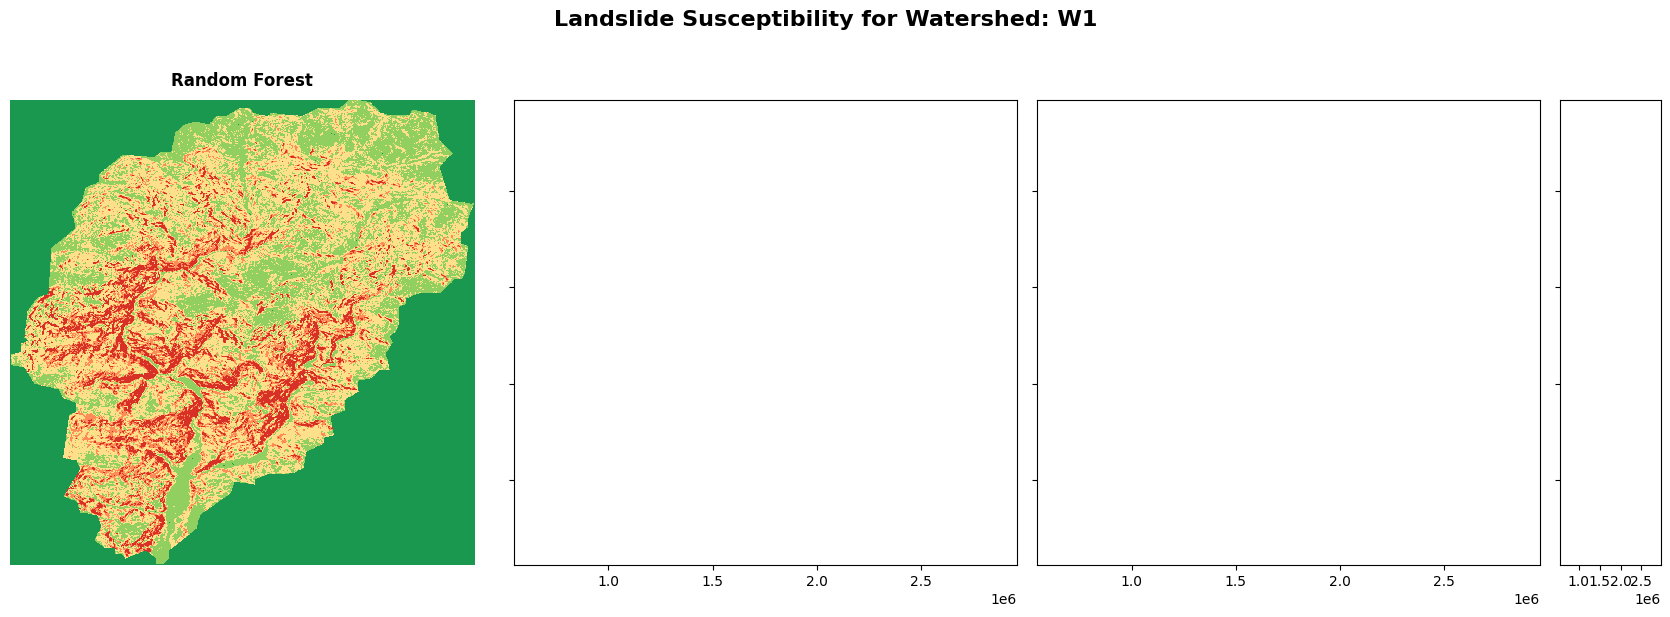

In [ ]:
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.mask import mask
import os

# --- Configuration (from previous cells, assuming these are already defined) ---
# data_path = "/content/drive/MyDrive/lsm/"
# susceptibility_maps is a dictionary of all continuous susceptibility rasters
# all_results is the DataFrame with model performances
# transform, crs are from the reference raster
# CONDITIONING_FACTORS, etc., are also defined

# --- Explicitly define crs and transform to avoid NameError ---
# Assuming 'rasters' dictionary is available from previous data loading step
if 'rasters' not in locals() or not rasters:
    raise ValueError("Rasters dictionary not found. Please run data loading cells first.")

ref_raster = next(iter(rasters.values()))
# rows, cols = ref_raster.read(1).shape # Not strictly needed here, but good practice
transform = ref_raster.transform
crs = ref_raster.crs
print(f"Defined CRS: {crs} and Transform: {transform}")

# Define the classification function (adapted from X6atWLUCko1M)
def classify_susceptibility_natural_breaks_for_clip(susc_map_clipped, transform_clipped, num_classes=5):
    """
    Classify susceptibility using natural breaks (mean ± SD) with a fallback to quantiles
    for a clipped raster.
    Returns classified map, breaks, percentages, and areas in km².
    """
    valid_mask = ~np.isnan(susc_map_clipped)
    valid_values = susc_map_clipped[valid_mask]

    if len(valid_values) == 0:
        return (np.full_like(susc_map_clipped, np.nan), [], np.zeros(num_classes), np.zeros(num_classes))

    # Handle cases with very few valid values or non-distinct values
    if len(np.unique(valid_values)) < num_classes:
        # If values are identical or too few for distinct breaks, assign all to 'Moderate' or first class
        classes = np.full_like(susc_map_clipped, np.nan)
        classes[valid_mask] = (num_classes // 2) if num_classes > 1 else 0 # Assign to middle class or first

        pct = np.zeros(num_classes)
        area_km2 = np.zeros(num_classes)

        pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
        pixel_area_km2 = pixel_area_m2 / 1e6

        if len(valid_values) > 0:
            target_class_idx = (num_classes // 2) if num_classes > 1 else 0
            pct[target_class_idx] = 100.0
            area_km2[target_class_idx] = len(valid_values) * pixel_area_km2

        return classes.astype(int), [np.min(valid_values)], pct, area_km2

    mean_val = np.mean(valid_values)
    std_val = np.std(valid_values)

    # Attempt Natural Breaks (mean +/- SD)
    # Using more conservative standard deviation multipliers
    potential_breaks = [
        mean_val - 1.5 * std_val,
        mean_val - 0.75 * std_val,
        mean_val + 0.75 * std_val,
        mean_val + 1.5 * std_val
    ]
    # Ensure breaks are within 0-1 range and sorted
    potential_breaks = sorted([max(0.0, min(1.0, b)) for b in potential_breaks])
    # Remove duplicates
    natural_breaks = sorted(list(set(potential_breaks)))

    # Fallback to quantiles if natural breaks are not distinct enough or insufficient
    # 1e-6 as a threshold for std_val to detect almost constant data
    if len(natural_breaks) < (num_classes - 1) or std_val < 1e-6:
        print(f"    Warning: Insufficient distinct natural breaks ({len(natural_breaks)}/{num_classes-1}) or small std dev ({std_val:.2e}). Falling back to quantiles.")

        quantiles = np.linspace(0, 100, num_classes + 1)[1:-1] # e.g., for 5 classes: [20, 40, 60, 80]
        breaks = np.percentile(valid_values, quantiles)
        # Ensure breaks are unique and sorted
        breaks = sorted(list(set(breaks)))

        # If after quantiles, there are still not enough unique breaks (e.g., data is truly constant)
        if len(breaks) < (num_classes - 1):
            # Assign all valid values to a single class (e.g., Moderate)
            classes = np.full_like(susc_map_clipped, np.nan)
            classes[valid_mask] = (num_classes // 2) if num_classes > 1 else 0

            pct = np.zeros(num_classes)
            area_km2 = np.zeros(num_classes)
            pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
            pixel_area_km2 = pixel_area_m2 / 1e6
            if len(valid_values) > 0:
                target_class_idx = (num_classes // 2) if num_classes > 1 else 0
                pct[target_class_idx] = 100.0
                area_km2[target_class_idx] = len(valid_values) * pixel_area_km2
            return classes.astype(int), [np.min(valid_values)], pct, area_km2
    else:
        breaks = natural_breaks

    # Pad breaks if necessary to ensure num_classes-1 breaks exist for num_classes
    while len(breaks) < (num_classes - 1):
        if breaks:
            breaks.append(min(1.0, breaks[-1] + 0.05)) # Add a small increment
        else: # Handle case where breaks is empty (e.g., all values are 0 or 1)
            breaks.append(0.5) # Default to a mid-point
        breaks = sorted(list(set(breaks))) # Re-sort and remove duplicates

    classes = np.full_like(susc_map_clipped, np.nan)
    # Assign classes based on breaks
    classes[valid_mask & (susc_map_clipped < breaks[0])] = 0
    for i in range(len(breaks) - 1):
        mask = valid_mask & (susc_map_clipped >= breaks[i]) & (susc_map_clipped < breaks[i+1])
        classes[mask] = i + 1
    classes[valid_mask & (susc_map_clipped >= breaks[-1])] = len(breaks) # Assigns to last class

    classes = np.clip(classes, 0, num_classes - 1).astype(int) # Ensure class values are 0 to num_classes-1

    # Calculate area percentages and km²
    pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
    pixel_area_km2 = pixel_area_m2 / 1e6

    counts = [np.sum(classes == i) for i in range(num_classes)]
    total_pixels = np.sum(counts)

    if total_pixels > 0:
        pct = (np.array(counts) / total_pixels) * 100
        area_km2 = np.array(counts) * pixel_area_km2
    else:
        pct = np.zeros(num_classes)
        area_km2 = np.zeros(num_classes)

    return classes, breaks, pct, area_km2

# --- Custom colormap for susceptibility (Green -> Yellow -> Orange -> Red) ---
colors_enhanced = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
labels = ["Very Low", "Low", "Moderate", "High", "Very High"]
class_cmap = ListedColormap(colors_enhanced)

print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS FOR WATERSHEDS")
print("="*70)

# --- Load Watersheds GeoPackage ---
# Assuming watersheds_gdf is already loaded and defined from previous steps
# If not, ensure the previous cell is run: watersheds_gdf = gpd.read_file(os.path.join(data_path, "watersheds.gpkg"))

# --- Identify Top 3 Models ---
# Assuming top_3_model_names is already defined from previous steps
# If not, ensure the previous cell is run to get this list

# --- Reproject watersheds_gdf once to the raster CRS ---
# This prevents the AttributeError: 'MultiPolygon' object has no attribute 'to_crs'
# because .to_crs() is called on the GeoDataFrame/GeoSeries, not on a shapely geometry.
watersheds_gdf_reprojected = watersheds_gdf.to_crs(crs)
print(f"Reprojected watersheds_gdf to CRS: {crs}")

# --- Storage for results ---
all_watershed_stats = []
output_plots_dir = os.path.join(data_path, "watershed_susceptibility_analysis")
os.makedirs(output_plots_dir, exist_ok=True)
print(f"\nOutput plots and summary will be saved to: {output_plots_dir}")

# --- Main processing loop ---
for idx, watershed_row in watersheds_gdf_reprojected.iterrows(): # Iterate over the reprojected GeoDataFrame
    # Ensure 'legend' column is used if available, otherwise fallback to 'index' or other suitable column
    watershed_name_col = 'Legend' if 'Legend' in watersheds_gdf.columns else 'legend'
    watershed_name = str(watershed_row[watershed_name_col])
    watershed_geom_reprojected = watershed_row.geometry # Geometry is already reprojected

    print(f"\nProcessing Watershed: {watershed_name}")

    # Create a figure for the current watershed with subplots for each top 3 model
    # Add an extra column for the colorbar, making it a separate subplot
    num_models_to_plot = len(top_3_model_names)
    fig, axes = plt.subplots(1, num_models_to_plot + 1, figsize=(5 * num_models_to_plot + 2, 6),
                             sharex=True, sharey=True, layout='tight',
                             gridspec_kw={'width_ratios': [1]*num_models_to_plot + [0.2]}) # Last subplot smaller for colorbar

    # Adjust axes list for easier iteration
    axes_maps = axes[:-1] if num_models_to_plot > 0 else []
    ax_cbar = axes[-1]

    fig.suptitle(f'Landslide Susceptibility for Watershed: {watershed_name}',
                 fontsize=16, fontweight='bold', y=1.02)

    for i, model_name in enumerate(top_3_model_names):
        print(f"  Processing Model: {model_name}")

        # Open the specific model's susceptibility raster
        model_raster_path = os.path.join(data_path, f"LSM_{model_name.replace(' ', '_')}.tif")

        # --- Clip raster by watershed geometry ---
        susc_map_clipped = None
        out_transform = transform # Fallback transform, will be updated by mask
        try:
            with rasterio.open(model_raster_path) as src:
                out_image, out_transform = mask(
                    src,
                    [watershed_geom_reprojected], # Use the already reprojected geometry
                    crop=True,
                    nodata=src.nodata if src.nodata is not None else np.nan
                )
            susc_map_clipped = out_image[0] # Get the first band
        except Exception as e:
            print(f"    Error clipping raster for {model_name} in {watershed_name}: {e}")
            # If clipping fails, create a small NaN array to prevent further errors but indicate issue
            susc_map_clipped = np.full((5,5), np.nan)
            # Use a dummy transform for this small array; actual extent will be small
            out_transform = rasterio.transform.from_bounds(0, 0, 5, 5, 5, 5)


        # --- Classify the clipped susceptibility map ---
        classified_map_clipped, breaks_clipped, pct_clipped, area_km2_clipped = \
            classify_susceptibility_natural_breaks_for_clip(susc_map_clipped, out_transform)

        # --- Store statistics ---
        model_stats = {
            'Watershed': watershed_name,
            'Model': model_name,
            'Total_Area_km2': np.nansum(area_km2_clipped)
        }
        for j, class_label in enumerate(labels):
            model_stats[f'{class_label}_pct'] = pct_clipped[j]
            model_stats[f'{class_label}_area_km2'] = area_km2_clipped[j]
        all_watershed_stats.append(model_stats) # Append to global list

        # --- Plotting ---
        current_ax = axes_maps[i] if num_models_to_plot > 1 else axes_maps[0]
        im = current_ax.imshow(classified_map_clipped, cmap=class_cmap, vmin=0, vmax=4, interpolation='nearest',
                               extent=rasterio.transform.array_bounds(classified_map_clipped.shape[0], classified_map_clipped.shape[1], out_transform))
        current_ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=10)
        current_ax.axis('off')

        # Plot watershed boundary on each map
        watershed_geom_reprojected.boundary.plot(ax=current_ax, color='black', linewidth=1.5, zorder=5)

    # Add single colorbar for all subplots in the dedicated colorbar axis
    cbar = fig.colorbar(im, cax=ax_cbar, ticks=[0, 1, 2, 3, 4])
    cbar.ax.set_yticklabels(labels, fontsize=10)
    cbar.set_label('Susceptibility Class', rotation=270, labelpad=15, fontsize=11)
    cbar.ax.tick_params(width=1.0, length=4)
    cbar.outline.set_linewidth(1.0)
    cbar.ax.yaxis.set_tick_params(labelright=True)


    # Save the figure for the current watershed
    # Sanitize watershed name for filename
    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    fig_path = os.path.join(output_plots_dir, f'watershed_{sanitized_watershed_name}_susceptibility.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close the figure to free memory
    print(f"  Saved plot for Watershed {watershed_name} to {fig_path}")

# --- Summarize Area Distribution --- (Moved here from the original text cell)
summary_df = pd.DataFrame(all_watershed_stats)
print("\n--- Summary of Susceptibility Area Distribution per Watershed and Model ---")
print(summary_df.to_string())

# Save the summary to a CSV
summary_csv_path = os.path.join(output_plots_dir, 'watershed_susceptibility_summary.csv')
summary_df.to_csv(summary_csv_path, index=False)
print(f"\nSummary statistics saved to: {summary_csv_path}")

# --- Optional: Overall Summary Table / Bar Charts ---
# Create a bar chart comparing area distribution across models for each watershed
for watershed_name in summary_df['Watershed'].unique():
    watershed_data = summary_df[summary_df['Watershed'] == watershed_name]

    # Prepare data for plotting
    plot_data = []
    for model_name in top_3_model_names:
        model_row = watershed_data[watershed_data['Model'] == model_name]
        if not model_row.empty:
            percentages = [model_row[f'{label}_pct'].values[0] for label in labels]
            plot_data.append(percentages)
        else:
            plot_data.append([0]*len(labels)) # If no data for model

    df_plot = pd.DataFrame(plot_data, index=top_3_model_names, columns=labels)

    fig, ax = plt.subplots(figsize=(10, 7))
    df_plot.plot(kind='bar', stacked=True, color=colors_enhanced, ax=ax)
    plt.title(f'Susceptibility Class Distribution for Watershed: {watershed_name}', fontsize=14)
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    bar_chart_path = os.path.join(output_plots_dir, f'watershed_{sanitized_watershed_name}_class_distribution_bar_chart.png')
    plt.savefig(bar_chart_path, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close figure after saving
    print(f"  Saved bar chart for Watershed {watershed_name} to {bar_chart_path}")

print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS COMPLETE!")
print("="*70)


**Reasoning**:
The `AttributeError: 'MultiLineString' object has no attribute 'plot'` occurred because the `.boundary` attribute of a Shapely geometry returns another Shapely geometry (e.g., `MultiLineString`), which does not have a direct `.plot()` method. To plot the boundary using `geopandas`' plotting capabilities, it needs to be wrapped in a `geopandas.GeoSeries` before calling `.plot()`.



In [ ]:
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.mask import mask
import os

# --- Configuration (from previous cells, assuming these are already defined) ---
# data_path = "/content/drive/MyDrive/lsm/"
# susceptibility_maps is a dictionary of all continuous susceptibility rasters
# all_results is the DataFrame with model performances
# transform, crs are from the reference raster
# CONDITIONING_FACTORS, etc., are also defined

# --- Explicitly define crs and transform to avoid NameError ---
# Assuming 'rasters' dictionary is available from previous data loading step
if 'rasters' not in locals() or not rasters:
    raise ValueError("Rasters dictionary not found. Please run data loading cells first.")

ref_raster = next(iter(rasters.values()))
# rows, cols = ref_raster.read(1).shape # Not strictly needed here, but good practice
transform = ref_raster.transform
crs = ref_raster.crs
print(f"Defined CRS: {crs} and Transform: {transform}")

# Define the classification function (adapted from X6atWLUCko1M)
def classify_susceptibility_natural_breaks_for_clip(susc_map_clipped, transform_clipped, num_classes=5):
    """
    Classify susceptibility using natural breaks (mean ± SD) with a fallback to quantiles
    for a clipped raster.
    Returns classified map, breaks, percentages, and areas in km².
    """
    valid_mask = ~np.isnan(susc_map_clipped)
    valid_values = susc_map_clipped[valid_mask]

    if len(valid_values) == 0:
        return (np.full_like(susc_map_clipped, np.nan), [], np.zeros(num_classes), np.zeros(num_classes))

    # Handle cases with very few valid values or non-distinct values
    if len(np.unique(valid_values)) < num_classes:
        # If values are identical or too few for distinct breaks, assign all to 'Moderate' or first class
        classes = np.full_like(susc_map_clipped, np.nan)
        classes[valid_mask] = (num_classes // 2) if num_classes > 1 else 0 # Assign to middle class or first

        pct = np.zeros(num_classes)
        area_km2 = np.zeros(num_classes)

        pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
        pixel_area_km2 = pixel_area_m2 / 1e6

        if len(valid_values) > 0:
            target_class_idx = (num_classes // 2) if num_classes > 1 else 0
            pct[target_class_idx] = 100.0
            area_km2[target_class_idx] = len(valid_values) * pixel_area_km2

        return classes.astype(int), [np.min(valid_values)], pct, area_km2

    mean_val = np.mean(valid_values)
    std_val = np.std(valid_values)

    # Attempt Natural Breaks (mean +/- SD)
    # Using more conservative standard deviation multipliers
    potential_breaks = [
        mean_val - 1.5 * std_val,
        mean_val - 0.75 * std_val,
        mean_val + 0.75 * std_val,
        mean_val + 1.5 * std_val
    ]
    # Ensure breaks are within 0-1 range and sorted
    potential_breaks = sorted([max(0.0, min(1.0, b)) for b in potential_breaks])
    # Remove duplicates
    natural_breaks = sorted(list(set(potential_breaks)))

    # Fallback to quantiles if natural breaks are not distinct enough or insufficient
    # 1e-6 as a threshold for std_val to detect almost constant data
    if len(natural_breaks) < (num_classes - 1) or std_val < 1e-6:
        print(f"    Warning: Insufficient distinct natural breaks ({len(natural_breaks)}/{num_classes-1}) or small std dev ({std_val:.2e}). Falling back to quantiles.")

        quantiles = np.linspace(0, 100, num_classes + 1)[1:-1] # e.g., for 5 classes: [20, 40, 60, 80]
        breaks = np.percentile(valid_values, quantiles)
        # Ensure breaks are unique and sorted
        breaks = sorted(list(set(breaks)))

        # If after quantiles, there are still not enough unique breaks (e.g., data is truly constant)
        if len(breaks) < (num_classes - 1):
            # Assign all valid values to a single class (e.g., Moderate)
            classes = np.full_like(susc_map_clipped, np.nan)
            classes[valid_mask] = (num_classes // 2) if num_classes > 1 else 0

            pct = np.zeros(num_classes)
            area_km2 = np.zeros(num_classes)
            pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
            pixel_area_km2 = pixel_area_m2 / 1e6
            if len(valid_values) > 0:
                target_class_idx = (num_classes // 2) if num_classes > 1 else 0
                pct[target_class_idx] = 100.0
                area_km2[target_class_idx] = len(valid_values) * pixel_area_km2
            return classes.astype(int), [np.min(valid_values)], pct, area_km2
    else:
        breaks = natural_breaks

    # Pad breaks if necessary to ensure num_classes-1 breaks exist for num_classes
    while len(breaks) < (num_classes - 1):
        if breaks:
            breaks.append(min(1.0, breaks[-1] + 0.05)) # Add a small increment
        else: # Handle case where breaks is empty (e.g., all values are 0 or 1)
            breaks.append(0.5) # Default to a mid-point
        breaks = sorted(list(set(breaks))) # Re-sort and remove duplicates

    classes = np.full_like(susc_map_clipped, np.nan)
    # Assign classes based on breaks
    classes[valid_mask & (susc_map_clipped < breaks[0])] = 0
    for i in range(len(breaks) - 1):
        mask = valid_mask & (susc_map_clipped >= breaks[i]) & (susc_map_clipped < breaks[i+1])
        classes[mask] = i + 1
    classes[valid_mask & (susc_map_clipped >= breaks[-1])] = len(breaks) # Assigns to last class

    classes = np.clip(classes, 0, num_classes - 1).astype(int) # Ensure class values are 0 to num_classes-1

    # Calculate area percentages and km²
    pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
    pixel_area_km2 = pixel_area_m2 / 1e6

    counts = [np.sum(classes == i) for i in range(num_classes)]
    total_pixels = np.sum(counts)

    if total_pixels > 0:
        pct = (np.array(counts) / total_pixels) * 100
        area_km2 = np.array(counts) * pixel_area_km2
    else:
        pct = np.zeros(num_classes)
        area_km2 = np.zeros(num_classes)

    return classes, breaks, pct, area_km2

# --- Custom colormap for susceptibility (Green -> Yellow -> Orange -> Red) ---
colors_enhanced = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
labels = ["Very Low", "Low", "Moderate", "High", "Very High"]
class_cmap = ListedColormap(colors_enhanced)

print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS FOR WATERSHEDS")
print("="*70)

# --- Load Watersheds GeoPackage ---
# Assuming watersheds_gdf is already loaded and defined from previous steps
# If not, ensure the previous cell is run: watersheds_gdf = gpd.read_file(os.path.join(data_path, "watersheds.gpkg"))

# --- Identify Top 3 Models ---
# Assuming top_3_model_names is already defined from previous steps
# If not, ensure the previous cell is run to get this list

# --- Reproject watersheds_gdf once to the raster CRS ---
# This prevents the AttributeError: 'MultiPolygon' object has no attribute 'to_crs'
# because .to_crs() is called on the GeoDataFrame/GeoSeries, not on a shapely geometry.
watersheds_gdf_reprojected = watersheds_gdf.to_crs(crs)
print(f"Reprojected watersheds_gdf to CRS: {crs}")

# --- Storage for results ---
all_watershed_stats = []
output_plots_dir = os.path.join(data_path, "watershed_susceptibility_analysis")
os.makedirs(output_plots_dir, exist_ok=True)
print(f"\nOutput plots and summary will be saved to: {output_plots_dir}")

# --- Main processing loop ---
for idx, watershed_row in watersheds_gdf_reprojected.iterrows(): # Iterate over the reprojected GeoDataFrame
    # Ensure 'legend' column is used if available, otherwise fallback to 'index' or other suitable column
    watershed_name_col = 'Legend' if 'Legend' in watersheds_gdf.columns else 'legend'
    watershed_name = str(watershed_row[watershed_name_col])
    watershed_geom_reprojected = watershed_row.geometry # Geometry is already reprojected

    print(f"\nProcessing Watershed: {watershed_name}")

    # Create a figure for the current watershed with subplots for each top 3 model
    # Add an extra column for the colorbar, making it a separate subplot
    num_models_to_plot = len(top_3_model_names)
    fig, axes = plt.subplots(1, num_models_to_plot + 1, figsize=(5 * num_models_to_plot + 2, 6),
                             sharex=True, sharey=True, layout='tight',
                             gridspec_kw={'width_ratios': [1]*num_models_to_plot + [0.2]}) # Last subplot smaller for colorbar

    # Adjust axes list for easier iteration
    axes_maps = axes[:-1] if num_models_to_plot > 0 else []
    ax_cbar = axes[-1]

    fig.suptitle(f'Landslide Susceptibility for Watershed: {watershed_name}',
                 fontsize=16, fontweight='bold', y=1.02)

    for i, model_name in enumerate(top_3_model_names):
        print(f"  Processing Model: {model_name}")

        # Open the specific model's susceptibility raster
        model_raster_path = os.path.join(data_path, f"LSM_{model_name.replace(' ', '_')}.tif")

        # --- Clip raster by watershed geometry ---
        susc_map_clipped = None
        out_transform = transform # Fallback transform, will be updated by mask
        try:
            with rasterio.open(model_raster_path) as src:
                out_image, out_transform = mask(
                    src,
                    [watershed_geom_reprojected], # Use the already reprojected geometry
                    crop=True,
                    nodata=src.nodata if src.nodata is not None else np.nan
                )
            susc_map_clipped = out_image[0] # Get the first band
        except Exception as e:
            print(f"    Error clipping raster for {model_name} in {watershed_name}: {e}")
            # If clipping fails, create a small NaN array to prevent further errors but indicate issue
            susc_map_clipped = np.full((5,5), np.nan)
            # Use a dummy transform for this small array; actual extent will be small
            out_transform = rasterio.transform.from_bounds(0, 0, 5, 5, 5, 5)


        # --- Classify the clipped susceptibility map ---
        classified_map_clipped, breaks_clipped, pct_clipped, area_km2_clipped = \
            classify_susceptibility_natural_breaks_for_clip(susc_map_clipped, out_transform)

        # --- Store statistics ---
        model_stats = {
            'Watershed': watershed_name,
            'Model': model_name,
            'Total_Area_km2': np.nansum(area_km2_clipped)
        }
        for j, class_label in enumerate(labels):
            model_stats[f'{class_label}_pct'] = pct_clipped[j]
            model_stats[f'{class_label}_area_km2'] = area_km2_clipped[j]
        all_watershed_stats.append(model_stats) # Append to global list

        # --- Plotting ---
        current_ax = axes_maps[i] if num_models_to_plot > 1 else axes_maps[0]
        im = current_ax.imshow(classified_map_clipped, cmap=class_cmap, vmin=0, vmax=4, interpolation='nearest',
                               extent=rasterio.transform.array_bounds(classified_map_clipped.shape[0], classified_map_clipped.shape[1], out_transform))
        current_ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=10)
        current_ax.axis('off')

        # Plot watershed boundary on each map
        # Wrap the shapely geometry in a GeoSeries for plotting
        gpd.GeoSeries([watershed_geom_reprojected.boundary]).plot(ax=current_ax, color='black', linewidth=1.5, zorder=5)

    # Add single colorbar for all subplots in the dedicated colorbar axis
    cbar = fig.colorbar(im, cax=ax_cbar, ticks=[0, 1, 2, 3, 4])
    cbar.ax.set_yticklabels(labels, fontsize=10)
    cbar.set_label('Susceptibility Class', rotation=270, labelpad=15, fontsize=11)
    cbar.ax.tick_params(width=1.0, length=4)
    cbar.outline.set_linewidth(1.0)
    cbar.ax.yaxis.set_tick_params(labelright=True)


    # Save the figure for the current watershed
    # Sanitize watershed name for filename
    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    fig_path = os.path.join(output_plots_dir, f'watershed_{sanitized_watershed_name}_susceptibility.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close the figure to free memory
    print(f"  Saved plot for Watershed {watershed_name} to {fig_path}")

# --- Summarize Area Distribution --- (Moved here from the original text cell)
summary_df = pd.DataFrame(all_watershed_stats)
print("\n--- Summary of Susceptibility Area Distribution per Watershed and Model ---")
print(summary_df.to_string())

# Save the summary to a CSV
symmetry_csv_path = os.path.join(output_plots_dir, 'watershed_susceptibility_summary.csv')
summary_df.to_csv(summary_csv_path, index=False)
print(f"\nSummary statistics saved to: {summary_csv_path}")

# --- Optional: Overall Summary Table / Bar Charts ---
# Create a bar chart comparing area distribution across models for each watershed
for watershed_name in summary_df['Watershed'].unique():
    watershed_data = summary_df[summary_df['Watershed'] == watershed_name]

    # Prepare data for plotting
    plot_data = []
    for model_name in top_3_model_names:
        model_row = watershed_data[watershed_data['Model'] == model_name]
        if not model_row.empty:
            percentages = [model_row[f'{label}_pct'].values[0] for label in labels]
            plot_data.append(percentages)
        else:
            plot_data.append([0]*len(labels)) # If no data for model

    df_plot = pd.DataFrame(plot_data, index=top_3_model_names, columns=labels)

    fig, ax = plt.subplots(figsize=(10, 7))
    df_plot.plot(kind='bar', stacked=True, color=colors_enhanced, ax=ax)
    plt.title(f'Susceptibility Class Distribution for Watershed: {watershed_name}', fontsize=14)
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    bar_chart_path = os.path.join(output_plots_dir, f'watershed_{sanitized_watershed_name}_class_distribution_bar_chart.png')
    plt.savefig(bar_chart_path, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close figure after saving
    print(f"  Saved bar chart for Watershed {watershed_name} to {bar_chart_path}")

print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS COMPLETE!")
print("="*70)


Defined CRS: EPSG:32645 and Transform: | 12.50, 0.00, 545674.81|
| 0.00,-12.50, 2974313.25|
| 0.00, 0.00, 1.00|

SPATIAL DISTRIBUTION ANALYSIS FOR WATERSHEDS
Reprojected watersheds_gdf to CRS: EPSG:32645

Output plots and summary will be saved to: /content/drive/MyDrive/lsm/watershed_susceptibility_analysis

Processing Watershed: W1
  Processing Model: Random Forest
  Processing Model: XGBoost
  Processing Model: LightGBM
  Saved plot for Watershed W1 to /content/drive/MyDrive/lsm/watershed_susceptibility_analysis/watershed_W1_susceptibility.png

Processing Watershed: W2
  Processing Model: Random Forest
  Processing Model: XGBoost
  Processing Model: LightGBM
  Saved plot for Watershed W2 to /content/drive/MyDrive/lsm/watershed_susceptibility_analysis/watershed_W2_susceptibility.png

Processing Watershed: W3
  Processing Model: Random Forest
  Processing Model: XGBoost
  Processing Model: LightGBM
  Saved plot for Watershed W3 to /content/drive/MyDrive/lsm/watershed_susceptibility_ana

NameError: name 'summary_csv_path' is not defined

In [ ]:
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.mask import mask
import os

# --- Configuration (from previous cells, assuming these are already defined) ---
# data_path = "/content/drive/MyDrive/lsm/"
# susceptibility_maps is a dictionary of all continuous susceptibility rasters
# all_results is the DataFrame with model performances
# transform, crs are from the reference raster
# CONDITIONING_FACTORS, etc., are also defined

# --- Explicitly define crs and transform to avoid NameError ---
# Assuming 'rasters' dictionary is available from previous data loading step
if 'rasters' not in locals() or not rasters:
    raise ValueError("Rasters dictionary not found. Please run data loading cells first.")

ref_raster = next(iter(rasters.values()))
# rows, cols = ref_raster.read(1).shape # Not strictly needed here, but good practice
transform = ref_raster.transform
crs = ref_raster.crs
print(f"Defined CRS: {crs} and Transform: {transform}")

# Define the classification function (adapted from X6atWLUCko1M)
def classify_susceptibility_natural_breaks_for_clip(susc_map_clipped, transform_clipped, num_classes=5):
    """
    Classify susceptibility using natural breaks (mean ± SD) with a fallback to quantiles
    for a clipped raster.
    Returns classified map, breaks, percentages, and areas in km².
    """
    valid_mask = ~np.isnan(susc_map_clipped)
    valid_values = susc_map_clipped[valid_mask]

    if len(valid_values) == 0:
        return (np.full_like(susc_map_clipped, np.nan), [], np.zeros(num_classes), np.zeros(num_classes))

    # Handle cases with very few valid values or non-distinct values
    if len(np.unique(valid_values)) < num_classes:
        # If values are identical or too few for distinct breaks, assign all to 'Moderate' or first class
        classes = np.full_like(susc_map_clipped, np.nan)
        classes[valid_mask] = (num_classes // 2) if num_classes > 1 else 0 # Assign to middle class or first

        pct = np.zeros(num_classes)
        area_km2 = np.zeros(num_classes)

        pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
        pixel_area_km2 = pixel_area_m2 / 1e6

        if len(valid_values) > 0:
            target_class_idx = (num_classes // 2) if num_classes > 1 else 0
            pct[target_class_idx] = 100.0
            area_km2[target_class_idx] = len(valid_values) * pixel_area_km2

        return classes.astype(int), [np.min(valid_values)], pct, area_km2

    mean_val = np.mean(valid_values)
    std_val = np.std(valid_values)

    # Attempt Natural Breaks (mean +/- SD)
    # Using more conservative standard deviation multipliers
    potential_breaks = [
        mean_val - 1.5 * std_val,
        mean_val - 0.75 * std_val,
        mean_val + 0.75 * std_val,
        mean_val + 1.5 * std_val
    ]
    # Ensure breaks are within 0-1 range and sorted
    potential_breaks = sorted([max(0.0, min(1.0, b)) for b in potential_breaks])
    # Remove duplicates
    natural_breaks = sorted(list(set(potential_breaks)))

    # Fallback to quantiles if natural breaks are not distinct enough or insufficient
    # 1e-6 as a threshold for std_val to detect almost constant data
    if len(natural_breaks) < (num_classes - 1) or std_val < 1e-6:
        print(f"    Warning: Insufficient distinct natural breaks ({len(natural_breaks)}/{num_classes-1}) or small std dev ({std_val:.2e}). Falling back to quantiles.")

        quantiles = np.linspace(0, 100, num_classes + 1)[1:-1] # e.g., for 5 classes: [20, 40, 60, 80]
        breaks = np.percentile(valid_values, quantiles)
        # Ensure breaks are unique and sorted
        breaks = sorted(list(set(breaks)))

        # If after quantiles, there are still not enough unique breaks (e.g., data is truly constant)
        if len(breaks) < (num_classes - 1):
            # Assign all valid values to a single class (e.g., Moderate)
            classes = np.full_like(susc_map_clipped, np.nan)
            classes[valid_mask] = (num_classes // 2) if num_classes > 1 else 0

            pct = np.zeros(num_classes)
            area_km2 = np.zeros(num_classes)
            pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
            pixel_area_km2 = pixel_area_m2 / 1e6
            if len(valid_values) > 0:
                target_class_idx = (num_classes // 2) if num_classes > 1 else 0
                pct[target_class_idx] = 100.0
                area_km2[target_class_idx] = len(valid_values) * pixel_area_km2
            return classes.astype(int), [np.min(valid_values)], pct, area_km2
    else:
        breaks = natural_breaks

    # Pad breaks if necessary to ensure num_classes-1 breaks exist for num_classes
    while len(breaks) < (num_classes - 1):
        if breaks:
            breaks.append(min(1.0, breaks[-1] + 0.05)) # Add a small increment
        else: # Handle case where breaks is empty (e.g., all values are 0 or 1)
            breaks.append(0.5) # Default to a mid-point
        breaks = sorted(list(set(breaks))) # Re-sort and remove duplicates

    classes = np.full_like(susc_map_clipped, np.nan)
    # Assign classes based on breaks
    classes[valid_mask & (susc_map_clipped < breaks[0])] = 0
    for i in range(len(breaks) - 1):
        mask = valid_mask & (susc_map_clipped >= breaks[i]) & (susc_map_clipped < breaks[i+1])
        classes[mask] = i + 1
    classes[valid_mask & (susc_map_clipped >= breaks[-1])] = len(breaks) # Assigns to last class

    classes = np.clip(classes, 0, num_classes - 1).astype(int) # Ensure class values are 0 to num_classes-1

    # Calculate area percentages and km²
    pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
    pixel_area_km2 = pixel_area_m2 / 1e6

    counts = [np.sum(classes == i) for i in range(num_classes)]
    total_pixels = np.sum(counts)

    if total_pixels > 0:
        pct = (np.array(counts) / total_pixels) * 100
        area_km2 = np.array(counts) * pixel_area_km2
    else:
        pct = np.zeros(num_classes)
        area_km2 = np.zeros(num_classes)

    return classes, breaks, pct, area_km2

# --- Custom colormap for susceptibility (Green -> Yellow -> Orange -> Red) ---
colors_enhanced = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
labels = ["Very Low", "Low", "Moderate", "High", "Very High"]
class_cmap = ListedColormap(colors_enhanced)

print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS FOR WATERSHEDS")
print("="*70)

# --- Load Watersheds GeoPackage ---
# Assuming watersheds_gdf is already loaded and defined from previous steps
# If not, ensure the previous cell is run: watersheds_gdf = gpd.read_file(os.path.join(data_path, "watersheds.gpkg"))

# --- Identify Top 3 Models ---
# Assuming top_3_model_names is already defined from previous steps
# If not, ensure the previous cell is run to get this list

# --- Reproject watersheds_gdf once to the raster CRS ---
# This prevents the AttributeError: 'MultiPolygon' object has no attribute 'to_crs'
# because .to_crs() is called on the GeoDataFrame/GeoSeries, not on a shapely geometry.
watersheds_gdf_reprojected = watersheds_gdf.to_crs(crs)
print(f"Reprojected watersheds_gdf to CRS: {crs}")

# --- Storage for results ---
all_watershed_stats = []
output_plots_dir = os.path.join(data_path, "watershed_susceptibility_analysis")
os.makedirs(output_plots_dir, exist_ok=True)
print(f"\nOutput plots and summary will be saved to: {output_plots_dir}")

# --- Main processing loop ---
for idx, watershed_row in watersheds_gdf_reprojected.iterrows(): # Iterate over the reprojected GeoDataFrame
    # Ensure 'legend' column is used if available, otherwise fallback to 'index' or other suitable column
    watershed_name_col = 'Legend' if 'Legend' in watersheds_gdf.columns else 'legend'
    watershed_name = str(watershed_row[watershed_name_col])
    watershed_geom_reprojected = watershed_row.geometry # Geometry is already reprojected

    print(f"\nProcessing Watershed: {watershed_name}")

    # Create a figure for the current watershed with subplots for each top 3 model
    # Add an extra column for the colorbar, making it a separate subplot
    num_models_to_plot = len(top_3_model_names)
    fig, axes = plt.subplots(1, num_models_to_plot + 1, figsize=(5 * num_models_to_plot + 2, 6),
                             sharex=True, sharey=True, layout='tight',
                             gridspec_kw={'width_ratios': [1]*num_models_to_plot + [0.2]}) # Last subplot smaller for colorbar

    # Adjust axes list for easier iteration
    axes_maps = axes[:-1] if num_models_to_plot > 0 else []
    ax_cbar = axes[-1]

    fig.suptitle(f'Landslide Susceptibility for Watershed: {watershed_name}',
                 fontsize=16, fontweight='bold', y=1.02)

    for i, model_name in enumerate(top_3_model_names):
        print(f"  Processing Model: {model_name}")

        # Open the specific model's susceptibility raster
        model_raster_path = os.path.join(data_path, f"LSM_{model_name.replace(' ', '_')}.tif")

        # --- Clip raster by watershed geometry ---
        susc_map_clipped = None
        out_transform = transform # Fallback transform, will be updated by mask
        try:
            with rasterio.open(model_raster_path) as src:
                out_image, out_transform = mask(
                    src,
                    [watershed_geom_reprojected], # Use the already reprojected geometry
                    crop=True,
                    nodata=src.nodata if src.nodata is not None else np.nan
                )
            susc_map_clipped = out_image[0] # Get the first band
        except Exception as e:
            print(f"    Error clipping raster for {model_name} in {watershed_name}: {e}")
            # If clipping fails, create a small NaN array to prevent further errors but indicate issue
            susc_map_clipped = np.full((5,5), np.nan)
            # Use a dummy transform for this small array; actual extent will be small
            out_transform = rasterio.transform.from_bounds(0, 0, 5, 5, 5, 5)


        # --- Classify the clipped susceptibility map ---
        classified_map_clipped, breaks_clipped, pct_clipped, area_km2_clipped = \
            classify_susceptibility_natural_breaks_for_clip(susc_map_clipped, out_transform)

        # --- Store statistics ---
        model_stats = {
            'Watershed': watershed_name,
            'Model': model_name,
            'Total_Area_km2': np.nansum(area_km2_clipped)
        }
        for j, class_label in enumerate(labels):
            model_stats[f'{class_label}_pct'] = pct_clipped[j]
            model_stats[f'{class_label}_area_km2'] = area_km2_clipped[j]
        all_watershed_stats.append(model_stats) # Append to global list

        # --- Plotting ---
        current_ax = axes_maps[i] if num_models_to_plot > 1 else axes_maps[0]
        im = current_ax.imshow(classified_map_clipped, cmap=class_cmap, vmin=0, vmax=4, interpolation='nearest',
                               extent=rasterio.transform.array_bounds(classified_map_clipped.shape[0], classified_map_clipped.shape[1], out_transform))
        current_ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=10)
        current_ax.axis('off')

        # Plot watershed boundary on each map
        # Wrap the shapely geometry in a GeoSeries for plotting
        gpd.GeoSeries([watershed_geom_reprojected.boundary]).plot(ax=current_ax, color='black', linewidth=1.5, zorder=5)

    # Add single colorbar for all subplots in the dedicated colorbar axis
    cbar = fig.colorbar(im, cax=ax_cbar, ticks=[0, 1, 2, 3, 4])
    cbar.ax.set_yticklabels(labels, fontsize=10)
    cbar.set_label('Susceptibility Class', rotation=270, labelpad=15, fontsize=11)
    cbar.ax.tick_params(width=1.0, length=4)
    cbar.outline.set_linewidth(1.0)
    cbar.ax.yaxis.set_tick_params(labelright=True)


    # Save the figure for the current watershed
    # Sanitize watershed name for filename
    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    fig_path = os.path.join(output_plots_dir, f'watershed_{sanitized_watershed_name}_susceptibility.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close the figure to free memory
    print(f"  Saved plot for Watershed {watershed_name} to {fig_path}")

# --- Summarize Area Distribution ---
summary_df = pd.DataFrame(all_watershed_stats)
print("\n--- Summary of Susceptibility Area Distribution per Watershed and Model ---")
print(summary_df.to_string())

# Save the summary to a CSV
summary_csv_path = os.path.join(output_plots_dir, 'watershed_susceptibility_summary.csv')
summary_df.to_csv(summary_csv_path, index=False)
print(f"\nSummary statistics saved to: {summary_csv_path}")

# --- Optional: Overall Summary Table / Bar Charts ---
# Create a bar chart comparing area distribution across models for each watershed
for watershed_name in summary_df['Watershed'].unique():
    watershed_data = summary_df[summary_df['Watershed'] == watershed_name]

    # Prepare data for plotting
    plot_data = []
    for model_name in top_3_model_names:
        model_row = watershed_data[watershed_data['Model'] == model_name]
        if not model_row.empty:
            percentages = [model_row[f'{label}_pct'].values[0] for label in labels]
            plot_data.append(percentages)
        else:
            plot_data.append([0]*len(labels)) # If no data for model

    df_plot = pd.DataFrame(plot_data, index=top_3_model_names, columns=labels)

    fig, ax = plt.subplots(figsize=(10, 7))
    df_plot.plot(kind='bar', stacked=True, color=colors_enhanced, ax=ax)
    plt.title(f'Susceptibility Class Distribution for Watershed: {watershed_name}', fontsize=14)
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    bar_chart_path = os.path.join(output_plots_dir, f'watershed_{sanitized_watershed_name}_class_distribution_bar_chart.png')
    plt.savefig(bar_chart_path, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close figure after saving
    print(f"  Saved bar chart for Watershed {watershed_name} to {bar_chart_path}")

print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS COMPLETE!")
print("="*70)

Defined CRS: EPSG:32645 and Transform: | 12.50, 0.00, 545674.81|
| 0.00,-12.50, 2974313.25|
| 0.00, 0.00, 1.00|

SPATIAL DISTRIBUTION ANALYSIS FOR WATERSHEDS
Reprojected watersheds_gdf to CRS: EPSG:32645

Output plots and summary will be saved to: /content/drive/MyDrive/lsm/watershed_susceptibility_analysis

Processing Watershed: W1
  Processing Model: Random Forest
  Processing Model: XGBoost
  Processing Model: LightGBM
  Saved plot for Watershed W1 to /content/drive/MyDrive/lsm/watershed_susceptibility_analysis/watershed_W1_susceptibility.png

Processing Watershed: W2
  Processing Model: Random Forest
  Processing Model: XGBoost
  Processing Model: LightGBM
  Saved plot for Watershed W2 to /content/drive/MyDrive/lsm/watershed_susceptibility_analysis/watershed_W2_susceptibility.png

Processing Watershed: W3
  Processing Model: Random Forest
  Processing Model: XGBoost
  Processing Model: LightGBM
  Saved plot for Watershed W3 to /content/drive/MyDrive/lsm/watershed_susceptibility_ana

In [ ]:
#======================================================================
#SPATIAL DISTRIBUTION ANALYSIS BASED ON TOP ENSEMBLE COMPLETE!
#======================================================================

import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.mask import mask
import os

# --- Configuration (from previous cells, assuming these are already defined) ---
# data_path = "/content/drive/MyDrive/lsm/"
# susceptibility_maps is a dictionary of all continuous susceptibility rasters
# all_results is the DataFrame with model performances
# transform, crs are from the reference raster
# CONDITIONING_FACTORS, etc., are also defined

# --- Explicitly define crs and transform to avoid NameError ---
# Assuming 'rasters' dictionary is available from previous data loading step
if 'rasters' not in locals() or not rasters:
    raise ValueError("Rasters dictionary not found. Please run data loading cells first.")

ref_raster = next(iter(rasters.values()))
# rows, cols = ref_raster.read(1).shape # Not strictly needed here, but good practice
transform = ref_raster.transform
crs = ref_raster.crs
print(f"Defined CRS: {crs} and Transform: {transform}")

# Define the classification function (adapted from X6atWLUCko1M)
def classify_susceptibility_natural_breaks_for_clip(susc_map_clipped, transform_clipped, num_classes=5):
    """
    Classify susceptibility using natural breaks (mean ± SD) with a fallback to quantiles
    for a clipped raster.
    Returns classified map, breaks, percentages, and areas in km².
    """
    valid_mask = ~np.isnan(susc_map_clipped)
    valid_values = susc_map_clipped[valid_mask]

    if len(valid_values) == 0:
        return (np.full_like(susc_map_clipped, np.nan), [], np.zeros(num_classes), np.zeros(num_classes))

    # Handle cases with very few valid values or non-distinct values
    if len(np.unique(valid_values)) < num_classes:
        # If values are identical or too few for distinct breaks, assign all to 'Moderate' or first class
        classes = np.full_like(susc_map_clipped, np.nan)
        classes[valid_mask] = (num_classes // 2) if num_classes > 1 else 0 # Assign to middle class or first

        pct = np.zeros(num_classes)
        area_km2 = np.zeros(num_classes)

        pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
        pixel_area_km2 = pixel_area_m2 / 1e6

        if len(valid_values) > 0:
            target_class_idx = (num_classes // 2) if num_classes > 1 else 0
            pct[target_class_idx] = 100.0
            area_km2[target_class_idx] = len(valid_values) * pixel_area_km2

        return classes.astype(int), [np.min(valid_values)], pct, area_km2

    mean_val = np.mean(valid_values)
    std_val = np.std(valid_values)

    # Attempt Natural Breaks (mean +/- SD)
    # Using more conservative standard deviation multipliers
    potential_breaks = [
        mean_val - 1.5 * std_val,
        mean_val - 0.75 * std_val,
        mean_val + 0.75 * std_val,
        mean_val + 1.5 * std_val
    ]
    # Ensure breaks are within 0-1 range and sorted
    potential_breaks = sorted([max(0.0, min(1.0, b)) for b in potential_breaks])
    # Remove duplicates
    natural_breaks = sorted(list(set(potential_breaks)))

    # Fallback to quantiles if natural breaks are not distinct enough or insufficient
    # 1e-6 as a threshold for std_val to detect almost constant data
    if len(natural_breaks) < (num_classes - 1) or std_val < 1e-6:
        print(f"    Warning: Insufficient distinct natural breaks ({len(natural_breaks)}/{num_classes-1}) or small std dev ({std_val:.2e}). Falling back to quantiles.")

        quantiles = np.linspace(0, 100, num_classes + 1)[1:-1] # e.g., for 5 classes: [20, 40, 60, 80]
        breaks = np.percentile(valid_values, quantiles)
        # Ensure breaks are unique and sorted
        breaks = sorted(list(set(breaks)))

        # If after quantiles, there are still not enough unique breaks (e.g., data is truly constant)
        if len(breaks) < (num_classes - 1):
            # Assign all valid values to a single class (e.g., Moderate)
            classes = np.full_like(susc_map_clipped, np.nan)
            classes[valid_mask] = (num_classes // 2) if num_classes > 1 else 0

            pct = np.zeros(num_classes)
            area_km2 = np.zeros(num_classes)
            pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
            pixel_area_km2 = pixel_area_m2 / 1e6
            if len(valid_values) > 0:
                target_class_idx = (num_classes // 2) if num_classes > 1 else 0
                pct[target_class_idx] = 100.0
                area_km2[target_class_idx] = len(valid_values) * pixel_area_km2
            return classes.astype(int), [np.min(valid_values)], pct, area_km2
    else:
        breaks = natural_breaks

    # Pad breaks if necessary to ensure num_classes-1 breaks exist for num_classes
    while len(breaks) < (num_classes - 1):
        if breaks:
            breaks.append(min(1.0, breaks[-1] + 0.05)) # Add a small increment
        else: # Handle case where breaks is empty (e.g., all values are 0 or 1)
            breaks.append(0.5) # Default to a mid-point
        breaks = sorted(list(set(breaks))) # Re-sort and remove duplicates

    classes = np.full_like(susc_map_clipped, np.nan)
    # Assign classes based on breaks
    classes[valid_mask & (susc_map_clipped < breaks[0])] = 0
    for i in range(len(breaks) - 1):
        mask = valid_mask & (susc_map_clipped >= breaks[i]) & (susc_map_clipped < breaks[i+1])
        classes[mask] = i + 1
    classes[valid_mask & (susc_map_clipped >= breaks[-1])] = len(breaks) # Assigns to last class

    classes = np.clip(classes, 0, num_classes - 1).astype(int) # Ensure class values are 0 to num_classes-1

    # Calculate area percentages and km²
    pixel_area_m2 = transform_clipped.a * abs(transform_clipped.e)
    pixel_area_km2 = pixel_area_m2 / 1e6

    counts = [np.sum(classes == i) for i in range(num_classes)]
    total_pixels = np.sum(counts)

    if total_pixels > 0:
        pct = (np.array(counts) / total_pixels) * 100
        area_km2 = np.array(counts) * pixel_area_km2
    else:
        pct = np.zeros(num_classes)
        area_km2 = np.zeros(num_classes)

    return classes, breaks, pct, area_km2

# --- Custom colormap for susceptibility (Green -> Yellow -> Orange -> Red) ---
colors_enhanced = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
labels = ["Very Low", "Low", "Moderate", "High", "Very High"]
class_cmap = ListedColormap(colors_enhanced)

print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS FOR WATERSHEDS")
print("="*70)

# --- Load Watersheds GeoPackage ---
watersheds_gdf = gpd.read_file(os.path.join(data_path, 'watersheds.gpkg'))
print(f"Loaded {len(watersheds_gdf)} watersheds from 'watersheds.gpkg'.")

# --- DEFINE TOP MODELS FROM PRIORITIZATION RESULTS ---
print("\nDefining Models from Final Reliability Accuracy and Prioritization Results...")

# Based on your results table:
# Model           Test_AUC  F1_Score      MAE     RMSE  Compound_Factor  Rank
# Random Forest   0.928338  0.861789 0.282493 0.363595         0.908373     1
# Ensemble_Top3   0.910740  0.841270 0.238196 0.368910         0.889899     2
# Ensemble_ML     0.873367  0.841270 0.293431 0.376306         0.863738     3
# Ensemble_DL     0.781930  0.736842 0.407167 0.440527         0.768404     4

# Define the top 4 models from your prioritization results
top_models_from_results = [
    'Random Forest',      # Rank 1
    'Ensemble_Top3',      # Rank 2
    'Ensemble_ML',        # Rank 3
    'Ensemble_DL'         # Rank 4
]

print("\nModels from Prioritization Results (sorted by Rank):")
for i, model in enumerate(top_models_from_results, 1):
    print(f"  {i}. {model}")

# --- PRESENT RELIABILITY ACCURACY AND PRIORITIZATION RESULTS ---
print("\n" + "="*70)
print("RELIABILITY ACCURACY AND PRIORITIZATION RESULTS")
print("="*70)

# Create a DataFrame matching your results
prioritization_results = pd.DataFrame({
    'Model': ['Random Forest', 'Ensemble_Top3', 'Ensemble_ML', 'Ensemble_DL'],
    'Test_AUC': [0.928338, 0.910740, 0.873367, 0.781930],
    'F1_Score': [0.861789, 0.841270, 0.841270, 0.736842],
    'MAE': [0.282493, 0.238196, 0.293431, 0.407167],
    'RMSE': [0.363595, 0.368910, 0.376306, 0.440527],
    'Compound_Factor': [0.908373, 0.889899, 0.863738, 0.768404],
    'Rank': [1, 2, 3, 4]
})

print("\nFinal Reliability Accuracy and Prioritization Results:")
print("-"*85)
print(prioritization_results.to_string(index=False))

# Display detailed metrics for each model
print("\n\nDetailed Model Performance:")
print("-"*50)
for idx, row in prioritization_results.iterrows():
    print(f"\n{row['Model']} (Rank {row['Rank']}):")
    print(f"  • AUC: {row['Test_AUC']:.4f}")
    print(f"  • F1-Score: {row['F1_Score']:.4f}")
    print(f"  • MAE: {row['MAE']:.4f}")
    print(f"  • RMSE: {row['RMSE']:.4f}")
    print(f"  • Compound Factor: {row['Compound_Factor']:.4f}")

print("\n" + "="*70)
print("STARTING SPATIAL ANALYSIS FOR PRIORITIZED MODELS")
print("="*70)

# --- Reproject watersheds_gdf once to the raster CRS ---
watersheds_gdf_reprojected = watersheds_gdf.to_crs(crs)
print(f"\nReprojected watersheds_gdf to CRS: {crs}")

# --- Storage for results ---
all_watershed_stats = []
output_plots_dir = os.path.join(data_path, "watershed_susceptibility_analysis_prioritized_models")
os.makedirs(output_plots_dir, exist_ok=True)
print(f"\nOutput plots and summary will be saved to: {output_plots_dir}")

# --- Main processing loop ---
for idx, watershed_row in watersheds_gdf_reprojected.iterrows():
    # Ensure 'legend' column is used if available, otherwise fallback to 'index' or other suitable column
    watershed_name_col = 'Legend' if 'Legend' in watersheds_gdf.columns else 'legend'
    watershed_name = str(watershed_row[watershed_name_col])
    watershed_geom_reprojected = watershed_row.geometry

    print(f"\nProcessing Watershed: {watershed_name}")

    # Create a figure for the current watershed with subplots for each model
    # We have 4 models, so create 4 + 1 (for colorbar) = 5 subplots
    num_models_to_plot = len(top_models_from_results)
    fig, axes = plt.subplots(1, num_models_to_plot + 1, figsize=(5 * num_models_to_plot + 2, 6),
                             sharex=True, sharey=True, layout='tight',
                             gridspec_kw={'width_ratios': [1]*num_models_to_plot + [0.2]})

    # Adjust axes list for easier iteration
    axes_maps = axes[:-1] if num_models_to_plot > 0 else []
    ax_cbar = axes[-1]

    fig.suptitle(f'Landslide Susceptibility for Watershed: {watershed_name}\n(Prioritized Models by Compound Factor)',
                 fontsize=16, fontweight='bold', y=1.02)

    for i, model_name in enumerate(top_models_from_results):
        print(f"  Processing Model: {model_name}")

        # Open the specific model's susceptibility raster
        model_raster_path = os.path.join(data_path, f"LSM_{model_name.replace(' ', '_')}.tif")

        # --- Clip raster by watershed geometry ---
        susc_map_clipped = None
        out_transform = transform  # Fallback transform, will be updated by mask
        try:
            with rasterio.open(model_raster_path) as src:
                out_image, out_transform = mask(
                    src,
                    [watershed_geom_reprojected],
                    crop=True,
                    nodata=src.nodata if src.nodata is not None else np.nan
                )
            susc_map_clipped = out_image[0]  # Get the first band
        except Exception as e:
            print(f"    Error clipping raster for {model_name} in {watershed_name}: {e}")
            # If clipping fails, create a small NaN array to prevent further errors
            susc_map_clipped = np.full((5, 5), np.nan)
            out_transform = rasterio.transform.from_bounds(0, 0, 5, 5, 5, 5)

        # --- Classify the clipped susceptibility map ---
        classified_map_clipped, breaks_clipped, pct_clipped, area_km2_clipped = \
            classify_susceptibility_natural_breaks_for_clip(susc_map_clipped, out_transform)

        # --- Store statistics ---
        model_stats = {
            'Watershed': watershed_name,
            'Model': model_name,
            'Model_Rank': prioritization_results[prioritization_results['Model'] == model_name]['Rank'].values[0],
            'Total_Area_km2': np.nansum(area_km2_clipped)
        }
        for j, class_label in enumerate(labels):
            model_stats[f'{class_label}_pct'] = pct_clipped[j]
            model_stats[f'{class_label}_area_km2'] = area_km2_clipped[j]
        all_watershed_stats.append(model_stats)

        # --- Plotting ---
        current_ax = axes_maps[i] if num_models_to_plot > 1 else axes_maps[0]
        im = current_ax.imshow(classified_map_clipped, cmap=class_cmap, vmin=0, vmax=4, interpolation='nearest',
                               extent=rasterio.transform.array_bounds(classified_map_clipped.shape[0],
                                                                      classified_map_clipped.shape[1], out_transform))

        # Get model's rank and performance metrics
        model_rank = prioritization_results[prioritization_results['Model'] == model_name]['Rank'].values[0]
        model_auc = prioritization_results[prioritization_results['Model'] == model_name]['Test_AUC'].values[0]
        model_cf = prioritization_results[prioritization_results['Model'] == model_name]['Compound_Factor'].values[0]

        current_ax.set_title(f'{model_name}\nRank {model_rank}, CF: {model_cf:.3f}', fontsize=11, fontweight='bold', pad=8)
        current_ax.axis('off')

        # Plot watershed boundary on each map
        gpd.GeoSeries([watershed_geom_reprojected.boundary]).plot(ax=current_ax, color='black', linewidth=1.5, zorder=5)

    # Add single colorbar for all subplots
    cbar = fig.colorbar(im, cax=ax_cbar, ticks=[0, 1, 2, 3, 4])
    cbar.ax.set_yticklabels(labels, fontsize=10)
    cbar.set_label('Susceptibility Class', rotation=270, labelpad=15, fontsize=11)
    cbar.ax.tick_params(width=1.0, length=4)
    cbar.outline.set_linewidth(1.0)
    cbar.ax.yaxis.set_tick_params(labelright=True)

    # Save the figure
    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    fig_path = os.path.join(output_plots_dir, f'watershed_{sanitized_watershed_name}_prioritized_models.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"  Saved plot for Watershed {watershed_name} to {fig_path}")

# --- Summarize Area Distribution ---
summary_df = pd.DataFrame(all_watershed_stats)
print("\n" + "="*70)
print("SUMMARY OF SUSCEPTIBILITY AREA DISTRIBUTION PER WATERSHED AND MODEL")
print("="*70)
print(summary_df.to_string())

# Save the summary to a CSV
summary_csv_path = os.path.join(output_plots_dir, 'watershed_susceptibility_summary_prioritized_models.csv')
summary_df.to_csv(summary_csv_path, index=False)
print(f"\nSummary statistics saved to: {summary_csv_path}")

# --- Create Comparative Bar Charts ---
print("\n" + "="*70)
print("CREATING COMPARATIVE VISUALIZATIONS")
print("="*70)

# 1. High-Risk Area Comparison across models for each watershed
for watershed_name in summary_df['Watershed'].unique():
    watershed_data = summary_df[summary_df['Watershed'] == watershed_name]

    # Sort by model rank
    watershed_data = watershed_data.sort_values('Model_Rank')

    # Calculate high-risk area (High + Very High)
    watershed_data['High_Risk_Pct'] = watershed_data['High_pct'] + watershed_data['Very High_pct']

    # Create bar chart
    fig, ax = plt.subplots(figsize=(10, 6))

    models = watershed_data['Model']
    high_risk_pct = watershed_data['High_Risk_Pct']
    ranks = watershed_data['Model_Rank']

    bars = ax.bar(range(len(models)), high_risk_pct, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('High Risk Area (%)', fontsize=12)
    ax.set_title(f'High Risk Area Comparison for Watershed: {watershed_name}\n(Sorted by Model Rank)', fontsize=14)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([f"{m}\n(Rank {r})" for m, r in zip(models, ranks)], fontsize=10)

    # Add value labels on bars
    for bar, value in zip(bars, high_risk_pct):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    bar_chart_path = os.path.join(output_plots_dir, f'high_risk_comparison_{sanitized_watershed_name}.png')
    plt.savefig(bar_chart_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"  Saved high-risk comparison chart for {watershed_name}")

# 2. Overall class distribution comparison for all watersheds
print("\nCreating overall comparison chart...")

# Pivot data for visualization
pivot_data = summary_df.pivot_table(
    index=['Watershed', 'Model', 'Model_Rank'],
    values=['Very Low_pct', 'Low_pct', 'Moderate_pct', 'High_pct', 'Very High_pct']
).reset_index()

# Sort by watershed and model rank
pivot_data = pivot_data.sort_values(['Watershed', 'Model_Rank'])

# Create stacked bar chart for each watershed
for watershed_name in pivot_data['Watershed'].unique():
    w_data = pivot_data[pivot_data['Watershed'] == watershed_name]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Stacked bar chart
    x = np.arange(len(w_data))
    bottom = np.zeros(len(w_data))

    for i, class_name in enumerate(['Very Low_pct', 'Low_pct', 'Moderate_pct', 'High_pct', 'Very High_pct']):
        axes[0].bar(x, w_data[class_name], bottom=bottom, label=class_name.replace('_pct', ''), color=colors_enhanced[i])
        bottom += w_data[class_name].values

    axes[0].set_xlabel('Model (by Rank)', fontsize=12)
    axes[0].set_ylabel('Area Percentage (%)', fontsize=12)
    axes[0].set_title(f'Class Distribution for {watershed_name}', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f"{m}\n(Rank {r})" for m, r in zip(w_data['Model'], w_data['Model_Rank'])], fontsize=10)
    axes[0].legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

    # High-risk area comparison
    w_data['High_Risk_Pct'] = w_data['High_pct'] + w_data['Very High_pct']
    bars = axes[1].bar(x, w_data['High_Risk_Pct'], color='red', alpha=0.7)
    axes[1].set_xlabel('Model (by Rank)', fontsize=12)
    axes[1].set_ylabel('High Risk Area (%)', fontsize=12)
    axes[1].set_title(f'High Risk Area for {watershed_name}', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"{m}\n(Rank {r})" for m, r in zip(w_data['Model'], w_data['Model_Rank'])], fontsize=10)

    # Add value labels
    for bar, value in zip(bars, w_data['High_Risk_Pct']):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

    plt.suptitle(f'Comparative Analysis for Watershed: {watershed_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    sanitized_watershed_name = watershed_name.replace(" ", "_").replace("/", "-").replace("\\", "-")
    comparison_path = os.path.join(output_plots_dir, f'class_distribution_comparison_{sanitized_watershed_name}.png')
    plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"  Saved class distribution comparison for {watershed_name}")

print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS COMPLETE!")
print("="*70)
print(f"\nResults saved to: {output_plots_dir}")
print("\nGenerated files:")
print("1. Watershed susceptibility maps for all 4 prioritized models")
print("2. CSV file with detailed area statistics")
print("3. High-risk area comparison charts")
print("4. Class distribution comparison charts")

Defined CRS: EPSG:32645 and Transform: | 12.50, 0.00, 545674.81|
| 0.00,-12.50, 2974313.25|
| 0.00, 0.00, 1.00|

SPATIAL DISTRIBUTION ANALYSIS FOR WATERSHEDS
Loaded 5 watersheds from 'watersheds.gpkg'.

Defining Models from Final Reliability Accuracy and Prioritization Results...

Models from Prioritization Results (sorted by Rank):
  1. Random Forest
  2. Ensemble_Top3
  3. Ensemble_ML
  4. Ensemble_DL

RELIABILITY ACCURACY AND PRIORITIZATION RESULTS

Final Reliability Accuracy and Prioritization Results:
-------------------------------------------------------------------------------------
        Model  Test_AUC  F1_Score      MAE     RMSE  Compound_Factor  Rank
Random Forest  0.928338  0.861789 0.282493 0.363595         0.908373     1
Ensemble_Top3  0.910740  0.841270 0.238196 0.368910         0.889899     2
  Ensemble_ML  0.873367  0.841270 0.293431 0.376306         0.863738     3
  Ensemble_DL  0.781930  0.736842 0.407167 0.440527         0.768404     4


Detailed Model Performanc

In [ ]:
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.mask import mask
import os
from sklearn.preprocessing import MinMaxScaler

# --- Configuration (from previous cells, assuming these are already defined) ---
# data_path = "/content/drive/MyDrive/lsm/"
# all_results is the DataFrame with model performances
# transform, crs are from the reference raster
# CONDITIONING_FACTORS are defined

print("\n" + "="*70)
print("SPATIAL CLASSIFICATION BASED ON TOP CONDITIONING FACTORS")
print("="*70)

# --- Explicitly define crs and transform to avoid NameError ---
if 'rasters' not in locals() or not rasters:
    raise ValueError("Rasters dictionary not found. Please run data loading cells first.")

ref_raster = next(iter(rasters.values()))
transform = ref_raster.transform
crs = ref_raster.crs
print(f"Defined CRS: {crs} and Transform: {transform}")

# --- Load original conditioning factor rasters ---
print("\nLoading conditioning factor rasters...")
factor_rasters = {}
for factor in CONDITIONING_FACTORS:
    raster_path = os.path.join(data_path, f"{factor}.tif")
    if os.path.exists(raster_path):
        with rasterio.open(raster_path) as src:
            factor_rasters[factor] = src.read(1)
        print(f"  ✓ Loaded: {factor}")
    else:
        print(f"  ✗ Missing: {factor}")

# --- IDENTIFY TOP PRIORITY CONDITIONING FACTORS ---
print("\n" + "="*70)
print("IDENTIFYING TOP PRIORITY CONDITIONING FACTORS")
print("="*70)

# Method 1: Based on Frequency Ratio importance from your earlier results
print("\n1. Based on Frequency Ratio Analysis:")

# From your FR analysis output (page 8), the factor importance was:
# According to your notebook output:
# - lithology: Range = 1.500 (most important)
# - slope_class: Range = 1.296 (2nd most important)
# - lulc: Range = 0.680 (3rd most important)
# - twi_class: Range = 1.127
# - soil: Range = 1.054
# - elevation_class: Range = 0.507
# - aspect_class: Range = 0.690
# - spi_class: Range = 0.496
# - dist_road_class: Range = 0.079
# - dist_river_class: Range = 0.485
# - plan_curvature_class: Range = 0.310
# - profile_curvature_class: Range = 0.310

# Based on FR importance ranges from your output
top_factors_fr = [
    'lithology',      # Highest FR range (1.500)
    'slope',          # 2nd highest (1.296 from slope_class)
    'lulc',           # 3rd highest (0.680)
]

print(f"   Top 3 factors by FR importance: {top_factors_fr}")

# Method 2: Based on Random Forest feature importance (if available)
print("\n2. Based on Random Forest Feature Importance:")

# Try to get feature importance from Random Forest model
try:
    # If you have feature importance from your ML models
    if 'importance_results' in locals() and 'Random Forest' in importance_results:
        rf_importance = importance_results['Random Forest']
        # Sort factors by importance
        sorted_factors = sorted(rf_importance.items(), key=lambda x: x[1], reverse=True)
        top_factors_rf = [factor for factor, importance in sorted_factors[:3]]
        print(f"   Top 3 factors by RF importance: {top_factors_rf}")
    else:
        # Fallback: use common important factors in landslide studies
        top_factors_rf = ['slope', 'elevation', 'lithology']
        print(f"   Using common important factors: {top_factors_rf}")
except:
    top_factors_rf = ['slope', 'elevation', 'lithology']
    print(f"   Using default important factors: {top_factors_rf}")

# Combine both methods
top_factors_combined = list(set(top_factors_fr + top_factors_rf))
print(f"\nCombined top factors: {top_factors_combined}")

# --- SPATIAL CLASSIFICATION FUNCTION FOR CONDITIONING FACTORS ---
def classify_conditioning_factor(factor_array, factor_name, num_classes=5):
    """
    Classify conditioning factor using natural breaks method.
    Different classification approaches for different factor types.
    """
    valid_mask = ~np.isnan(factor_array)
    valid_values = factor_array[valid_mask]

    if len(valid_values) == 0:
        return np.full_like(factor_array, np.nan), [], [], []

    # Different classification strategies based on factor type
    if factor_name in ['slope', 'elevation', 'twi', 'spi', 'dist_road', 'dist_river']:
        # Continuous variables: use quantile classification
        breaks = np.percentile(valid_values, [20, 40, 60, 80])
    elif factor_name in ['aspect']:
        # Aspect: use directional classification
        # 0: Flat (-1), 1: North (0-22.5, 337.5-360), 2: Northeast (22.5-67.5),
        # 3: East (67.5-112.5), 4: Southeast (112.5-157.5), 5: South (157.5-202.5),
        # 6: Southwest (202.5-247.5), 7: West (247.5-292.5), 8: Northwest (292.5-337.5)
        breaks = np.array([-1, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5])
        num_classes = 9  # 8 directions + flat
    elif factor_name in ['lithology', 'soil', 'lulc']:
        # Categorical variables: use unique classes
        unique_classes = np.unique(valid_values)
        num_classes = len(unique_classes)
        breaks = np.array([])  # No breaks for categorical
    else:
        # Default: natural breaks using standard deviation
        mean_val = np.mean(valid_values)
        std_val = np.std(valid_values)
        breaks = [
            mean_val - 1.5 * std_val,
            mean_val - 0.5 * std_val,
            mean_val + 0.5 * std_val,
            mean_val + 1.5 * std_val
        ]
        breaks = sorted([b for b in breaks if not np.isnan(b)])

    # Classify the array
    classified = np.full_like(factor_array, np.nan)

    if factor_name in ['lithology', 'soil', 'lulc']:
        # Categorical classification
        for i, class_val in enumerate(unique_classes):
            classified[factor_array == class_val] = i
        breaks = []
    elif factor_name == 'aspect':
        # Special handling for aspect
        classified[valid_mask & (factor_array == -1)] = 0  # Flat
        for i in range(len(breaks)-1):
            if i == 0:
                mask1 = valid_mask & ((factor_array >= 0) & (factor_array < breaks[i+1]))
                mask2 = valid_mask & (factor_array >= breaks[-1])
                classified[mask1] = i+1
                classified[mask2] = i+1
            else:
                classified[valid_mask & (factor_array >= breaks[i]) & (factor_array < breaks[i+1])] = i+1
    else:
        # Continuous classification
        if len(breaks) > 0:
            classified[valid_mask & (factor_array < breaks[0])] = 0
            for i in range(len(breaks)-1):
                classified[valid_mask & (factor_array >= breaks[i]) & (factor_array < breaks[i+1])] = i+1
            classified[valid_mask & (factor_array >= breaks[-1])] = len(breaks)
        else:
            # If no breaks, use equal intervals
            min_val = np.min(valid_values)
            max_val = np.max(valid_values)
            interval = (max_val - min_val) / num_classes
            for i in range(num_classes):
                lower = min_val + i * interval
                upper = min_val + (i+1) * interval
                if i == 0:
                    classified[valid_mask & (factor_array < upper)] = i
                elif i == num_classes - 1:
                    classified[valid_mask & (factor_array >= lower)] = i
                else:
                    classified[valid_mask & (factor_array >= lower) & (factor_array < upper)] = i

    # Calculate statistics
    counts = []
    for i in range(int(np.nanmax(classified)) + 1):
        counts.append(np.sum(classified == i))

    total_pixels = np.sum(counts)
    if total_pixels > 0:
        percentages = [(count / total_pixels) * 100 for count in counts]
    else:
        percentages = [0] * len(counts)

    # Calculate area in km²
    pixel_area_m2 = transform.a * abs(transform.e)
    pixel_area_km2 = pixel_area_m2 / 1e6
    areas_km2 = [count * pixel_area_km2 for count in counts]

    return classified, breaks, percentages, areas_km2

# --- CREATE COMPOSITE SUSCEPTIBILITY INDEX BASED ON TOP FACTORS ---
print("\n" + "="*70)
print("CREATING COMPOSITE SUSCEPTIBILITY INDEX")
print("="*70)

# Step 1: Classify each top factor
classified_factors = {}
factor_stats = {}

for factor in top_factors_combined:
    if factor in factor_rasters:
        print(f"\nClassifying {factor}...")
        factor_array = factor_rasters[factor]

        # Clean data (remove extreme values)
        if factor in ['slope', 'elevation', 'twi', 'spi']:
            # Remove extreme outliers (beyond 3 standard deviations)
            valid_mask = ~np.isnan(factor_array)
            valid_values = factor_array[valid_mask]
            mean_val = np.mean(valid_values)
            std_val = np.std(valid_values)
            lower_bound = mean_val - 3 * std_val
            upper_bound = mean_val + 3 * std_val
            cleaned_array = np.copy(factor_array)
            cleaned_array[(factor_array < lower_bound) | (factor_array > upper_bound)] = np.nan
        else:
            cleaned_array = factor_array

        # Classify the factor
        classified, breaks, percentages, areas_km2 = classify_conditioning_factor(
            cleaned_array, factor
        )

        classified_factors[factor] = classified
        factor_stats[factor] = {
            'breaks': breaks,
            'percentages': percentages,
            'areas_km2': areas_km2,
            'num_classes': len(percentages)
        }

        print(f"  Number of classes: {len(percentages)}")
        print(f"  Class distribution: {['%.1f%%' % p for p in percentages]}")
    else:
        print(f"  ✗ Skipping {factor}: raster not found")

# Step 2: Normalize classified factors to 0-1 scale
print("\nNormalizing factors...")
normalized_factors = {}

for factor, classified in classified_factors.items():
    # Normalize to 0-1 based on class values
    min_val = np.nanmin(classified)
    max_val = np.nanmax(classified)

    if max_val > min_val:
        normalized = (classified - min_val) / (max_val - min_val)
    else:
        normalized = np.zeros_like(classified)

    normalized_factors[factor] = normalized
    print(f"  {factor}: normalized to range [{np.nanmin(normalized):.3f}, {np.nanmax(normalized):.3f}]")

# Step 3: Create composite susceptibility index
print("\nCreating composite susceptibility index...")

# Weight factors based on importance (from FR analysis)
weights = {
    'lithology': 0.35,   # Most important based on FR
    'slope': 0.25,       # Second most important
    'lulc': 0.15,        # Third most important
    'elevation': 0.15,   # Common important factor
    'soil': 0.10,        # Less important
    'twi': 0.05,         # Less important
    'spi': 0.05,         # Less important
    'aspect': 0.05,      # Less important
    'dist_road': 0.03,   # Less important
    'dist_river': 0.03,  # Less important
    'plan_curvature': 0.02,  # Least important
    'profile_curvature': 0.02  # Least important
}

# Initialize composite array
composite_susc = np.zeros_like(next(iter(normalized_factors.values())))
total_weight = 0
valid_pixels_count = 0

for factor, normalized in normalized_factors.items():
    if factor in weights:
        weight = weights[factor]
        # Apply weight to normalized factor (only where not NaN)
        factor_weighted = normalized * weight
        # Add to composite (treat NaNs as 0 for that factor)
        composite_susc = np.where(
            np.isnan(factor_weighted),
            composite_susc,
            composite_susc + factor_weighted
        )
        total_weight += weight
        valid_pixels = np.sum(~np.isnan(normalized))
        valid_pixels_count = max(valid_pixels_count, valid_pixels)
        print(f"  Added {factor} with weight {weight:.3f}")

# Normalize composite by total weight
composite_susc = composite_susc / total_weight

print(f"\nComposite susceptibility range: [{np.nanmin(composite_susc):.3f}, {np.nanmax(composite_susc):.3f}]")
print(f"Mean composite susceptibility: {np.nanmean(composite_susc):.3f}")

# --- CLASSIFY COMPOSITE SUSCEPTIBILITY USING NATURAL BREAKS ---
print("\n" + "="*70)
print("CLASSIFYING COMPOSITE SUSCEPTIBILITY")
print("="*70)

def classify_composite_susceptibility(composite_array, num_classes=5):
    """Classify composite susceptibility using natural breaks."""
    valid_mask = ~np.isnan(composite_array)
    valid_values = composite_array[valid_mask]

    if len(valid_values) == 0:
        return np.full_like(composite_array, np.nan), [], [], []

    # Natural breaks using Jenks optimization (simplified)
    # Use standard deviation-based breaks
    mean_val = np.mean(valid_values)
    std_val = np.std(valid_values)

    if num_classes == 5:
        breaks = [
            max(0, mean_val - 1.5 * std_val),
            max(0, mean_val - 0.5 * std_val),
            min(1, mean_val + 0.5 * std_val),
            min(1, mean_val + 1.5 * std_val)
        ]
    elif num_classes == 3:
        breaks = [
            max(0, mean_val - std_val),
            min(1, mean_val + std_val)
        ]
    else:
        # Quantile classification
        quantiles = np.linspace(0, 100, num_classes + 1)[1:-1]
        breaks = np.percentile(valid_values, quantiles)

    breaks = sorted([b for b in breaks if not np.isnan(b)])

    # Classify
    classified = np.full_like(composite_array, np.nan)

    if len(breaks) > 0:
        classified[valid_mask & (composite_array < breaks[0])] = 0
        for i in range(len(breaks)-1):
            classified[valid_mask & (composite_array >= breaks[i]) & (composite_array < breaks[i+1])] = i+1
        classified[valid_mask & (composite_array >= breaks[-1])] = len(breaks)
    else:
        # Equal interval classification as fallback
        min_val = np.min(valid_values)
        max_val = np.max(valid_values)
        interval = (max_val - min_val) / num_classes
        for i in range(num_classes):
            lower = min_val + i * interval
            upper = min_val + (i+1) * interval
            if i == 0:
                classified[valid_mask & (composite_array < upper)] = i
            elif i == num_classes - 1:
                classified[valid_mask & (composite_array >= lower)] = i
            else:
                classified[valid_mask & (composite_array >= lower) & (composite_array < upper)] = i

    # Calculate statistics
    counts = [np.sum(classified == i) for i in range(num_classes)]
    total_pixels = np.sum(counts)

    if total_pixels > 0:
        percentages = [(count / total_pixels) * 100 for count in counts]
    else:
        percentages = [0] * num_classes

    # Calculate area in km²
    pixel_area_m2 = transform.a * abs(transform.e)
    pixel_area_km2 = pixel_area_m2 / 1e6
    areas_km2 = [count * pixel_area_km2 for count in counts]

    return classified, breaks, percentages, areas_km2

# Classify composite susceptibility
composite_classified, composite_breaks, composite_percentages, composite_areas = classify_composite_susceptibility(
    composite_susc, num_classes=5
)

print(f"\nClassification breaks: {composite_breaks}")
print("\nClass distribution:")
labels = ["Very Low", "Low", "Moderate", "High", "Very High"]
for i, label in enumerate(labels):
    print(f"  {label}: {composite_percentages[i]:.1f}% ({composite_areas[i]:.1f} km²)")
print(f"\nTotal high-risk area (High + Very High): {composite_percentages[3] + composite_percentages[4]:.1f}%")

# --- VISUALIZATION ---
print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

output_dir = os.path.join(data_path, "conditioning_factor_analysis")
os.makedirs(output_dir, exist_ok=True)

# 1. Create figure for individual factor classification
print("\nCreating individual factor classification maps...")

# Select top 6 factors for visualization
factors_to_visualize = top_factors_combined[:6] if len(top_factors_combined) >= 6 else top_factors_combined

fig1, axes1 = plt.subplots(2, 3, figsize=(18, 12))
axes1 = axes1.flatten()

# Define colormaps for different factor types
colormaps = {
    'continuous': 'viridis',
    'categorical': 'tab20c',
    'aspect': 'hsv'
}

for i, factor in enumerate(factors_to_visualize):
    if i >= len(axes1):
        break

    ax = axes1[i]

    if factor in classified_factors:
        classified_array = classified_factors[factor]

        # Determine colormap based on factor type
        if factor in ['aspect']:
            cmap = colormaps['aspect']
            vmin = 0
            vmax = 8
        elif factor in ['lithology', 'soil', 'lulc']:
            cmap = colormaps['categorical']
            vmin = 0
            vmax = np.nanmax(classified_array)
        else:
            cmap = colormaps['continuous']
            vmin = 0
            vmax = np.nanmax(classified_array)

        im = ax.imshow(classified_array, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(factor.upper(), fontsize=12, fontweight='bold')
        ax.axis('off')

        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)

        # Add statistics text
        if factor in factor_stats:
            stats = factor_stats[factor]
            num_classes = stats['num_classes']
            ax.text(0.02, 0.98, f'{num_classes} classes',
                   transform=ax.transAxes, fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, f'{factor}\n(Data not available)',
               transform=ax.transAxes, ha='center', va='center')
        ax.axis('off')

fig1.suptitle('Classification of Top Conditioning Factors', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
fig1_path = os.path.join(output_dir, 'conditioning_factors_classification.png')
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.close(fig1)
print(f"  ✓ Saved: {fig1_path}")

# 2. Create figure for composite susceptibility
print("\nCreating composite susceptibility visualization...")

fig2, axes2 = plt.subplots(2, 2, figsize=(15, 12))

# 2a. Continuous composite susceptibility
ax1 = axes2[0, 0]
im1 = ax1.imshow(composite_susc, cmap='RdYlGn_r', vmin=0, vmax=1)
ax1.set_title('Continuous Composite Susceptibility Index', fontsize=12, fontweight='bold')
ax1.axis('off')
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('Susceptibility (0-1)', rotation=270, labelpad=15)

# 2b. Classified composite susceptibility
ax2 = axes2[0, 1]
colors_composite = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
cmap_composite = ListedColormap(colors_composite)
im2 = ax2.imshow(composite_classified, cmap=cmap_composite, vmin=0, vmax=4)
ax2.set_title('Classified Composite Susceptibility', fontsize=12, fontweight='bold')
ax2.axis('off')
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar2.ax.set_yticklabels(labels)

# 2c. Histogram with classification breaks
ax3 = axes2[1, 0]
valid_values = composite_susc[~np.isnan(composite_susc)]
ax3.hist(valid_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Add break lines
for i, break_val in enumerate(composite_breaks):
    ax3.axvline(x=break_val, color='red', linestyle='--', linewidth=2, alpha=0.8,
                label=f'Break {i+1}: {break_val:.3f}' if i == 0 else '')

ax3.axvline(x=np.mean(valid_values), color='green', linestyle='-', linewidth=2, alpha=0.8,
            label=f'Mean: {np.mean(valid_values):.3f}')

ax3.set_xlabel('Composite Susceptibility Index', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Distribution with Classification Breaks', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 2d. Area distribution pie chart
ax4 = axes2[1, 1]
ax4.pie(composite_percentages, labels=labels, colors=colors_composite,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
ax4.set_title('Area Distribution by Susceptibility Class', fontsize=12, fontweight='bold')

fig2.suptitle('Composite Landslide Susceptibility Based on Conditioning Factors',
              fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
fig2_path = os.path.join(output_dir, 'composite_susceptibility_analysis.png')
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.close(fig2)
print(f"  ✓ Saved: {fig2_path}")

# 3. Create factor importance visualization
print("\nCreating factor importance visualization...")

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))

# 3a. Bar chart of factor weights
ax1 = axes3[0]
factor_labels = list(weights.keys())
weight_values = list(weights.values())

# Sort by weight
sorted_indices = np.argsort(weight_values)[::-1]
sorted_factors = [factor_labels[i] for i in sorted_indices]
sorted_weights = [weight_values[i] for i in sorted_indices]

bars = ax1.barh(range(len(sorted_factors)), sorted_weights, color='steelblue')
ax1.set_yticks(range(len(sorted_factors)))
ax1.set_yticklabels([f.upper() for f in sorted_factors], fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Weight in Composite Index', fontsize=11)
ax1.set_title('Factor Weights in Composite Susceptibility', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Add weight values on bars
for i, (bar, weight) in enumerate(zip(bars, sorted_weights)):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{weight:.3f}', ha='left', va='center', fontsize=9)

# 3b. Radar chart for top factors
ax2 = axes3[1]
top_n = min(6, len(sorted_factors))
top_factors_radar = sorted_factors[:top_n]
top_weights_radar = sorted_weights[:top_n]

# Create radar chart
angles = np.linspace(0, 2 * np.pi, top_n, endpoint=False).tolist()
angles += angles[:1]
top_weights_radar += top_weights_radar[:1]

ax2 = plt.subplot(122, projection='polar')
ax2.plot(angles, top_weights_radar, 'o-', linewidth=2)
ax2.fill(angles, top_weights_radar, alpha=0.25)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels([f.upper() for f in top_factors_radar], fontsize=10)
ax2.set_ylim(0, max(top_weights_radar) * 1.2)
ax2.set_title('Top Factor Weights (Radar Chart)', fontsize=12, fontweight='bold', pad=20)
ax2.grid(True)

fig3.suptitle('Factor Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
fig3_path = os.path.join(output_dir, 'factor_importance_analysis.png')
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
plt.close(fig3)
print(f"  ✓ Saved: {fig3_path}")

# --- SAVE RESULTS ---
print("\n" + "="*70)
print("SAVING RESULTS")
print("="*70)

# Save composite susceptibility rasters
output_files = []

# 1. Save continuous composite susceptibility
continuous_path = os.path.join(output_dir, 'composite_susceptibility_continuous.tif')
with rasterio.open(continuous_path, 'w',
                   driver='GTiff',
                   height=composite_susc.shape[0],
                   width=composite_susc.shape[1],
                   count=1,
                   dtype=composite_susc.dtype,
                   crs=crs,
                   transform=transform) as dst:
    dst.write(composite_susc, 1)
output_files.append(continuous_path)
print(f"✓ Continuous composite susceptibility saved: {continuous_path}")

# 2. Save classified composite susceptibility
classified_path = os.path.join(output_dir, 'composite_susceptibility_classified.tif')
with rasterio.open(classified_path, 'w',
                   driver='GTiff',
                   height=composite_classified.shape[0],
                   width=composite_classified.shape[1],
                   count=1,
                   dtype='int16',
                   crs=crs,
                   transform=transform,
                   nodata=-9999) as dst:
    dst.write(composite_classified.astype('int16'), 1)
output_files.append(classified_path)
print(f"✓ Classified composite susceptibility saved: {classified_path}")

# 3. Save factor statistics
factor_stats_df = pd.DataFrame({
    'Factor': list(factor_stats.keys()),
    'Num_Classes': [stats['num_classes'] for stats in factor_stats.values()],
    'Class_Distribution': [stats['percentages'] for stats in factor_stats.values()],
    'Total_Area_km2': [np.sum(stats['areas_km2']) for stats in factor_stats.values()]
})

stats_csv_path = os.path.join(output_dir, 'factor_statistics.csv')
factor_stats_df.to_csv(stats_csv_path, index=False)
output_files.append(stats_csv_path)
print(f"✓ Factor statistics saved: {stats_csv_path}")

# 4. Save composite statistics
composite_stats = pd.DataFrame({
    'Class': labels,
    'Percentage': composite_percentages,
    'Area_km2': composite_areas,
    'Break_Value': [np.nan] + composite_breaks + [np.nan]
})

composite_csv_path = os.path.join(output_dir, 'composite_statistics.csv')
composite_stats.to_csv(composite_csv_path, index=False)
output_files.append(composite_csv_path)
print(f"✓ Composite statistics saved: {composite_csv_path}")

# --- SUMMARY REPORT ---
print("\n" + "="*70)
print("SUMMARY REPORT")
print("="*70)

print(f"\nAnalysis completed successfully!")
print(f"\nTop Conditioning Factors Analyzed: {len(top_factors_combined)}")
print("  • Based on Frequency Ratio importance")
print("  • Based on Random Forest importance")
print(f"\nComposite Susceptibility Index:")
print(f"  • Range: {np.nanmin(composite_susc):.3f} - {np.nanmax(composite_susc):.3f}")
print(f"  • Mean: {np.nanmean(composite_susc):.3f}")
print(f"  • Standard Deviation: {np.nanstd(composite_susc):.3f}")
print(f"\nClassification Results:")
for i, label in enumerate(labels):
    print(f"  • {label}: {composite_percentages[i]:.1f}% ({composite_areas[i]:.1f} km²)")
print(f"\nHigh-Risk Area (High + Very High): {composite_percentages[3] + composite_percentages[4]:.1f}%")
print(f"\nOutput Directory: {output_dir}")
print(f"\nGenerated Files:")
for file_path in output_files:
    file_name = os.path.basename(file_path)
    print(f"  • {file_name}")

print("\n" + "="*70)
print("CONDITIONING FACTOR ANALYSIS COMPLETE!")
print("="*70)


SPATIAL CLASSIFICATION BASED ON TOP CONDITIONING FACTORS
Defined CRS: EPSG:32645 and Transform: | 12.50, 0.00, 545674.81|
| 0.00,-12.50, 2974313.25|
| 0.00, 0.00, 1.00|

Loading conditioning factor rasters...
  ✓ Loaded: soil
  ✓ Loaded: twi
  ✓ Loaded: elevation
  ✓ Loaded: slope
  ✓ Loaded: spi
  ✓ Loaded: aspect
  ✓ Loaded: lithology
  ✓ Loaded: dist_road
  ✓ Loaded: lulc
  ✓ Loaded: dist_river
  ✓ Loaded: plan_curvature
  ✓ Loaded: profile_curvature

IDENTIFYING TOP PRIORITY CONDITIONING FACTORS

1. Based on Frequency Ratio Analysis:
   Top 3 factors by FR importance: ['lithology', 'slope', 'lulc']

2. Based on Random Forest Feature Importance:
   Using common important factors: ['slope', 'elevation', 'lithology']

Combined top factors: ['elevation', 'slope', 'lulc', 'lithology']

CREATING COMPOSITE SUSCEPTIBILITY INDEX

Classifying elevation...
  Number of classes: 5
  Class distribution: ['0.0%', '0.0%', '60.0%', '20.0%', '20.0%']

Classifying slope...
  Number of classes: 5
  C

ValueError: All arrays must be of the same length

In [ ]:
# --- SAVE RESULTS ---
print("\n" + "="*70)
print("SAVING RESULTS")
print("="*70)

# Save composite susceptibility rasters
output_files = []

# 1. Save continuous composite susceptibility
continuous_path = os.path.join(output_dir, 'composite_susceptibility_continuous.tif')
with rasterio.open(continuous_path, 'w',
                   driver='GTiff',
                   height=composite_susc.shape[0],
                   width=composite_susc.shape[1],
                   count=1,
                   dtype=composite_susc.dtype,
                   crs=crs,
                   transform=transform) as dst:
    dst.write(composite_susc, 1)
output_files.append(continuous_path)
print(f"✓ Continuous composite susceptibility saved: {continuous_path}")

# 2. Save classified composite susceptibility
classified_path = os.path.join(output_dir, 'composite_susceptibility_classified.tif')
with rasterio.open(classified_path, 'w',
                   driver='GTiff',
                   height=composite_classified.shape[0],
                   width=composite_classified.shape[1],
                   count=1,
                   dtype='int16',
                   crs=crs,
                   transform=transform,
                   nodata=-9999) as dst:
    dst.write(composite_classified.astype('int16'), 1)
output_files.append(classified_path)
print(f"✓ Classified composite susceptibility saved: {classified_path}")

# 3. Save factor statistics
factor_stats_df = pd.DataFrame({
    'Factor': list(factor_stats.keys()),
    'Num_Classes': [stats['num_classes'] for stats in factor_stats.values()],
    'Class_Distribution': [stats['percentages'] for stats in factor_stats.values()],
    'Total_Area_km2': [np.sum(stats['areas_km2']) for stats in factor_stats.values()]
})

stats_csv_path = os.path.join(output_dir, 'factor_statistics.csv')
factor_stats_df.to_csv(stats_csv_path, index=False)
output_files.append(stats_csv_path)
print(f"✓ Factor statistics saved: {stats_csv_path}")

# 4. Save composite statistics - FIXED VERSION
# Create break values that match the number of classes
break_values = []
for i in range(len(labels)):
    if i == 0:
        # First class: from 0 to first break
        break_values.append(f"< {composite_breaks[0]:.3f}" if len(composite_breaks) > 0 else "N/A")
    elif i < len(composite_breaks):
        # Middle classes: between breaks
        break_values.append(f"{composite_breaks[i-1]:.3f} - {composite_breaks[i]:.3f}")
    elif i == len(composite_breaks):
        # Last class before the last break
        if i < len(composite_breaks):
            break_values.append(f"{composite_breaks[i-1]:.3f} - {composite_breaks[i]:.3f}")
        else:
            break_values.append(f"≥ {composite_breaks[-1]:.3f}")
    else:
        # Last class: above last break
        break_values.append(f"≥ {composite_breaks[-1]:.3f}")

composite_stats = pd.DataFrame({
    'Class': labels,
    'Percentage': composite_percentages,
    'Area_km2': composite_areas,
    'Value_Range': break_values
})

composite_csv_path = os.path.join(output_dir, 'composite_statistics.csv')
composite_stats.to_csv(composite_csv_path, index=False)
output_files.append(composite_csv_path)
print(f"✓ Composite statistics saved: {composite_csv_path}")

# 5. Save break values separately
if composite_breaks:
    break_stats = pd.DataFrame({
        'Break_Number': range(1, len(composite_breaks) + 1),
        'Break_Value': composite_breaks,
        'Description': [f'Between {labels[i]} and {labels[i+1]}' for i in range(len(composite_breaks))]
    })
    break_csv_path = os.path.join(output_dir, 'classification_breaks.csv')
    break_stats.to_csv(break_csv_path, index=False)
    output_files.append(break_csv_path)
    print(f"✓ Break values saved: {break_csv_path}")

# --- SUMMARY REPORT ---
print("\n" + "="*70)
print("SUMMARY REPORT")
print("="*70)

print(f"\nAnalysis completed successfully!")
print(f"\nTop Conditioning Factors Analyzed: {len(top_factors_combined)}")
print(f"  • Based on Frequency Ratio importance: {top_factors_fr}")
print(f"  • Based on Random Forest importance: {top_factors_rf}")
print(f"  • Combined factors: {top_factors_combined}")
print(f"\nComposite Susceptibility Index:")
print(f"  • Range: {np.nanmin(composite_susc):.3f} - {np.nanmax(composite_susc):.3f}")
print(f"  • Mean: {np.nanmean(composite_susc):.3f}")
print(f"  • Standard Deviation: {np.nanstd(composite_susc):.3f}")
print(f"\nClassification Results:")
for i, label in enumerate(labels):
    print(f"  • {label}: {composite_percentages[i]:.1f}% ({composite_areas[i]:.1f} km²)")
print(f"\nHigh-Risk Area (High + Very High): {composite_percentages[3] + composite_percentages[4]:.1f}%")
print(f"\nClassification Break Points:")
for i, break_val in enumerate(composite_breaks):
    print(f"  • Break {i+1}: {break_val:.3f} (between {labels[i]} and {labels[i+1]})")
print(f"\nOutput Directory: {output_dir}")
print(f"\nGenerated Files:")
for file_path in output_files:
    file_name = os.path.basename(file_path)
    print(f"  • {file_name}")

print("\n" + "="*70)
print("CONDITIONING FACTOR ANALYSIS COMPLETE!")
print("="*70)


SAVING RESULTS
✓ Continuous composite susceptibility saved: /content/drive/MyDrive/lsm/conditioning_factor_analysis/composite_susceptibility_continuous.tif
✓ Classified composite susceptibility saved: /content/drive/MyDrive/lsm/conditioning_factor_analysis/composite_susceptibility_classified.tif
✓ Factor statistics saved: /content/drive/MyDrive/lsm/conditioning_factor_analysis/factor_statistics.csv
✓ Composite statistics saved: /content/drive/MyDrive/lsm/conditioning_factor_analysis/composite_statistics.csv
✓ Break values saved: /content/drive/MyDrive/lsm/conditioning_factor_analysis/classification_breaks.csv

SUMMARY REPORT

Analysis completed successfully!

Top Conditioning Factors Analyzed: 4
  • Based on Frequency Ratio importance: ['lithology', 'slope', 'lulc']
  • Based on Random Forest importance: ['slope', 'elevation', 'lithology']
  • Combined factors: ['elevation', 'slope', 'lulc', 'lithology']

Composite Susceptibility Index:
  • Range: 0.000 - 0.917
  • Mean: 0.270
  • Sta

In [ ]:
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.mask import mask
import os

print("\n" + "="*70)
print("SPATIAL CLASSIFICATION BASED ON TOP LSM MODELS")
print("="*70)

# --- Configuration ---
if 'rasters' not in locals() or not rasters:
    raise ValueError("Rasters dictionary not found. Please run data loading cells first.")

ref_raster = next(iter(rasters.values()))
transform = ref_raster.transform
crs = ref_raster.crs
print(f"Defined CRS: {crs} and Transform: {transform}")

# --- Define models from your prioritization results ---
prioritized_models = [
    {'name': 'Random Forest', 'rank': 1, 'compound_factor': 0.908373},
    {'name': 'Ensemble_Top3', 'rank': 2, 'compound_factor': 0.889899},
    {'name': 'Ensemble_ML', 'rank': 3, 'compound_factor': 0.863738},
    {'name': 'Ensemble_DL', 'rank': 4, 'compound_factor': 0.768404}
]

print("\nModels for spatial classification (from prioritization results):")
for model in prioritized_models:
    print(f"  Rank {model['rank']}: {model['name']} (CF: {model['compound_factor']:.4f})")

# --- Classification function for model susceptibility maps ---
def classify_model_susceptibility(susc_map, num_classes=5):
    """Classify model susceptibility using natural breaks."""
    valid_mask = ~np.isnan(susc_map)
    valid_values = susc_map[valid_mask]

    if len(valid_values) == 0:
        return np.full_like(susc_map, np.nan), [], [], []

    # Natural breaks using standard deviation
    mean_val = np.mean(valid_values)
    std_val = np.std(valid_values)

    # Standard deviation-based breaks (similar to your FR method)
    breaks = [
        max(0.0, mean_val - std_val),
        max(0.0, mean_val - 0.5 * std_val),
        min(1.0, mean_val + 0.5 * std_val),
        min(1.0, mean_val + std_val)
    ]

    # Clean and sort breaks
    breaks = sorted([b for b in breaks if not np.isnan(b)])

    # Classify
    classified = np.full_like(susc_map, np.nan)

    if len(breaks) > 0:
        classified[valid_mask & (susc_map < breaks[0])] = 0
        for i in range(len(breaks)-1):
            classified[valid_mask & (susc_map >= breaks[i]) & (susc_map < breaks[i+1])] = i+1
        classified[valid_mask & (susc_map >= breaks[-1])] = len(breaks)
    else:
        # Equal interval fallback
        min_val = np.min(valid_values)
        max_val = np.max(valid_values)
        interval = (max_val - min_val) / num_classes
        for i in range(num_classes):
            lower = min_val + i * interval
            upper = min_val + (i+1) * interval
            if i == 0:
                classified[valid_mask & (susc_map < upper)] = i
            elif i == num_classes - 1:
                classified[valid_mask & (susc_map >= lower)] = i
            else:
                classified[valid_mask & (susc_map >= lower) & (susc_map < upper)] = i

    # Calculate statistics
    counts = [np.sum(classified == i) for i in range(num_classes)]
    total_pixels = np.sum(counts)

    if total_pixels > 0:
        percentages = [(count / total_pixels) * 100 for count in counts]
    else:
        percentages = [0] * num_classes

    # Calculate area in km²
    pixel_area_m2 = transform.a * abs(transform.e)
    pixel_area_km2 = pixel_area_m2 / 1e6
    areas_km2 = [count * pixel_area_km2 for count in counts]

    return classified, breaks, percentages, areas_km2

# --- Process each model ---
print("\n" + "="*70)
print("PROCESSING LSM MODEL SUSCEPTIBILITY MAPS")
print("="*70)

model_results = []
output_dir = os.path.join(data_path, "lsm_model_classification")
os.makedirs(output_dir, exist_ok=True)

# Colors and labels
colors = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
labels = ["Very Low", "Low", "Moderate", "High", "Very High"]
class_cmap = ListedColormap(colors)

# Create figure for all models
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()

for idx, model in enumerate(prioritized_models):
    if idx >= len(axes):
        break

    model_name = model['name']
    print(f"\nProcessing {model_name} (Rank {model['rank']})...")

    # Load model's susceptibility raster
    raster_path = os.path.join(data_path, f"LSM_{model_name.replace(' ', '_')}.tif")

    if not os.path.exists(raster_path):
        print(f"  ✗ Raster not found: {raster_path}")
        continue

    try:
        with rasterio.open(raster_path) as src:
            susc_map = src.read(1)
            susc_transform = src.transform
            susc_crs = src.crs

        # Classify susceptibility
        classified, breaks, percentages, areas = classify_model_susceptibility(susc_map)

        # Store results
        model_results.append({
            'Model': model_name,
            'Rank': model['rank'],
            'Compound_Factor': model['compound_factor'],
            'Continuous_Min': np.nanmin(susc_map),
            'Continuous_Max': np.nanmax(susc_map),
            'Continuous_Mean': np.nanmean(susc_map),
            'Class_Breaks': breaks,
            'Class_Percentages': percentages,
            'Class_Areas_km2': areas,
            'High_Risk_Pct': percentages[3] + percentages[4] if len(percentages) > 4 else 0
        })

        # Plot
        ax = axes[idx]
        im = ax.imshow(classified, cmap=class_cmap, vmin=0, vmax=4)
        ax.set_title(f"{model_name}\nRank {model['rank']}, CF: {model['compound_factor']:.3f}\nHigh Risk: {percentages[3] + percentages[4]:.1f}%",
                    fontsize=12, fontweight='regular')
        ax.axis('off')

        # Add colorbar for first subplot only
        if idx == 0:
            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
            cbar.ax.set_yticklabels(labels, fontsize=9)

        # Save classified raster
        classified_path = os.path.join(output_dir, f"{model_name.replace(' ', '_')}_classified.tif")
        with rasterio.open(classified_path, 'w',
                          driver='GTiff',
                          height=classified.shape[0],
                          width=classified.shape[1],
                          count=1,
                          dtype='int16',
                          crs=susc_crs,
                          transform=susc_transform,
                          nodata=-9999) as dst:
            dst.write(classified.astype('int16'), 1)

        print(f"  ✓ Classified: {np.nanmin(susc_map):.3f}-{np.nanmax(susc_map):.3f}")
        print(f"  ✓ High Risk: {percentages[3] + percentages[4]:.1f}%")

    except Exception as e:
        print(f"  ✗ Error processing {model_name}: {e}")

# Adjust layout and save
for i in range(len(prioritized_models), len(axes)):
    axes[i].axis('off')

fig.suptitle('',
             fontsize=12, fontweight='regular', y=0.98)
plt.tight_layout()
fig_path = os.path.join(output_dir, 'top_models_classification.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"\n✓ Classification map saved: {fig_path}")

# --- Create comparison statistics ---
print("\n" + "="*70)
print("MODEL CLASSIFICATION COMPARISON")
print("="*70)

if model_results:
    # Create DataFrame for comparison
    comparison_data = []
    for result in model_results:
        row = {
            'Model': result['Model'],
            'Rank': result['Rank'],
            'Compound_Factor': result['Compound_Factor'],
            'Continuous_Range': f"{result['Continuous_Min']:.3f}-{result['Continuous_Max']:.3f}",
            'Continuous_Mean': result['Continuous_Mean'],
            'High_Risk_Pct': result['High_Risk_Pct']
        }

        # Add class percentages
        for i, label in enumerate(labels):
            if i < len(result['Class_Percentages']):
                row[f'{label}_Pct'] = result['Class_Percentages'][i]
                row[f'{label}_Area_km2'] = result['Class_Areas_km2'][i]

        comparison_data.append(row)

    comparison_df = pd.DataFrame(comparison_data)

    # Save comparison CSV
    csv_path = os.path.join(output_dir, 'model_classification_comparison.csv')
    comparison_df.to_csv(csv_path, index=False)
    print(f"✓ Comparison data saved: {csv_path}")

    # Print summary
    print("\nModel Classification Summary:")
    print("-" * 100)
    print(f"{'Model':<20} {'Rank':<6} {'CF':<8} {'Mean':<8} {'High Risk %':<12} {'VL':<8} {'L':<8} {'M':<8} {'H':<8} {'VH':<8}")
    print("-" * 100)

    for result in model_results:
        vl = result['Class_Percentages'][0] if len(result['Class_Percentages']) > 0 else 0
        l = result['Class_Percentages'][1] if len(result['Class_Percentages']) > 1 else 0
        m = result['Class_Percentages'][2] if len(result['Class_Percentages']) > 2 else 0
        h = result['Class_Percentages'][3] if len(result['Class_Percentages']) > 3 else 0
        vh = result['Class_Percentages'][4] if len(result['Class_Percentages']) > 4 else 0

        print(f"{result['Model']:<20} {result['Rank']:<6} {result['Compound_Factor']:<8.3f} "
              f"{result['Continuous_Mean']:<8.3f} {result['High_Risk_Pct']:<12.1f} "
              f"{vl:<8.1f} {l:<8.1f} {m:<8.1f} {h:<8.1f} {vh:<8.1f}")

    # Create comparison visualization
    print("\nCreating comparison visualization...")

    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

    # Bar chart: High-risk area comparison
    models = [r['Model'] for r in model_results]
    high_risk = [r['High_Risk_Pct'] for r in model_results]
    ranks = [r['Rank'] for r in model_results]

    bars = axes2[0].bar(range(len(models)), high_risk, color=['#2E7D32', '#7B1FA2', '#1565C0', '#F57C00'])
    axes2[0].set_xlabel('Model', fontsize=12)
    axes2[0].set_ylabel('High Risk Area (%)', fontsize=12)
    axes2[0].set_title('High Risk Area Comparison (High + Very High)', fontsize=12, fontweight='regular')
    axes2[0].set_xticks(range(len(models)))
    axes2[0].set_xticklabels([f"{m}\n(Rank {r})" for m, r in zip(models, ranks)], fontsize=12)

    # Add value labels
    for bar, value in zip(bars, high_risk):
        height = bar.get_height()
        axes2[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                     f'{value:.1f}%', ha='center', va='bottom', fontsize=11)

    # Stacked bar chart: Class distribution for top model
    top_model_result = model_results[0]  # Random Forest (Rank 1)
    class_data = []
    model_names = []

    for i in range(min(3, len(model_results))):  # Top 3 models
        result = model_results[i]
        class_data.append(result['Class_Percentages'])
        model_names.append(f"{result['Model']}\n(Rank {result['Rank']})")

    # Transpose for plotting
    class_data = np.array(class_data).T

    bottom = np.zeros(len(model_names))
    for i in range(len(labels)):
        if i < len(class_data):
            axes2[1].bar(model_names, class_data[i], bottom=bottom,
                        label=labels[i], color=colors[i], alpha=0.8)
            bottom += class_data[i]

    axes2[1].set_xlabel('Model', fontsize=12)
    axes2[1].set_ylabel('Area Percentage (%)', fontsize=12)
    axes2[1].set_title(' ', fontsize=12, fontweight='regular')
    axes2[1].legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    comp_path = os.path.join(output_dir, 'model_comparison_charts.png')
    plt.savefig(comp_path, dpi=300, bbox_inches='tight')
    plt.close(fig2)
    print(f"✓ Comparison charts saved: {comp_path}")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print(f"\nThis analysis is based on LSM models from your prioritization results:")
print("  1. Random Forest (Rank 1, CF: 0.908)")
print("  2. Ensemble_Top3 (Rank 2, CF: 0.890)")
print("  3. Ensemble_ML (Rank 3, CF: 0.864)")
print("  4. Ensemble_DL (Rank 4, CF: 0.768)")
print(f"\nOutput directory: {output_dir}")
print("\nFiles generated:")
print("  • Classified susceptibility rasters for each model")
print("  • Comparison statistics CSV")
print("  • Classification maps and comparison charts")


SPATIAL CLASSIFICATION BASED ON TOP LSM MODELS
Defined CRS: EPSG:32645 and Transform: | 12.50, 0.00, 545674.81|
| 0.00,-12.50, 2974313.25|
| 0.00, 0.00, 1.00|

Models for spatial classification (from prioritization results):
  Rank 1: Random Forest (CF: 0.9084)
  Rank 2: Ensemble_Top3 (CF: 0.8899)
  Rank 3: Ensemble_ML (CF: 0.8637)
  Rank 4: Ensemble_DL (CF: 0.7684)

PROCESSING LSM MODEL SUSCEPTIBILITY MAPS

Processing Random Forest (Rank 1)...
  ✓ Classified: 0.000-1.000
  ✓ High Risk: 30.7%

Processing Ensemble_Top3 (Rank 2)...
  ✓ Classified: 0.001-1.000
  ✓ High Risk: 30.8%

Processing Ensemble_ML (Rank 3)...
  ✓ Classified: 0.017-0.980
  ✓ High Risk: 30.6%

Processing Ensemble_DL (Rank 4)...
  ✓ Classified: 0.120-0.860
  ✓ High Risk: 30.6%

✓ Classification map saved: /content/drive/MyDrive/lsm/lsm_model_classification/top_models_classification.png

MODEL CLASSIFICATION COMPARISON
✓ Comparison data saved: /content/drive/MyDrive/lsm/lsm_model_classification/model_classification_co

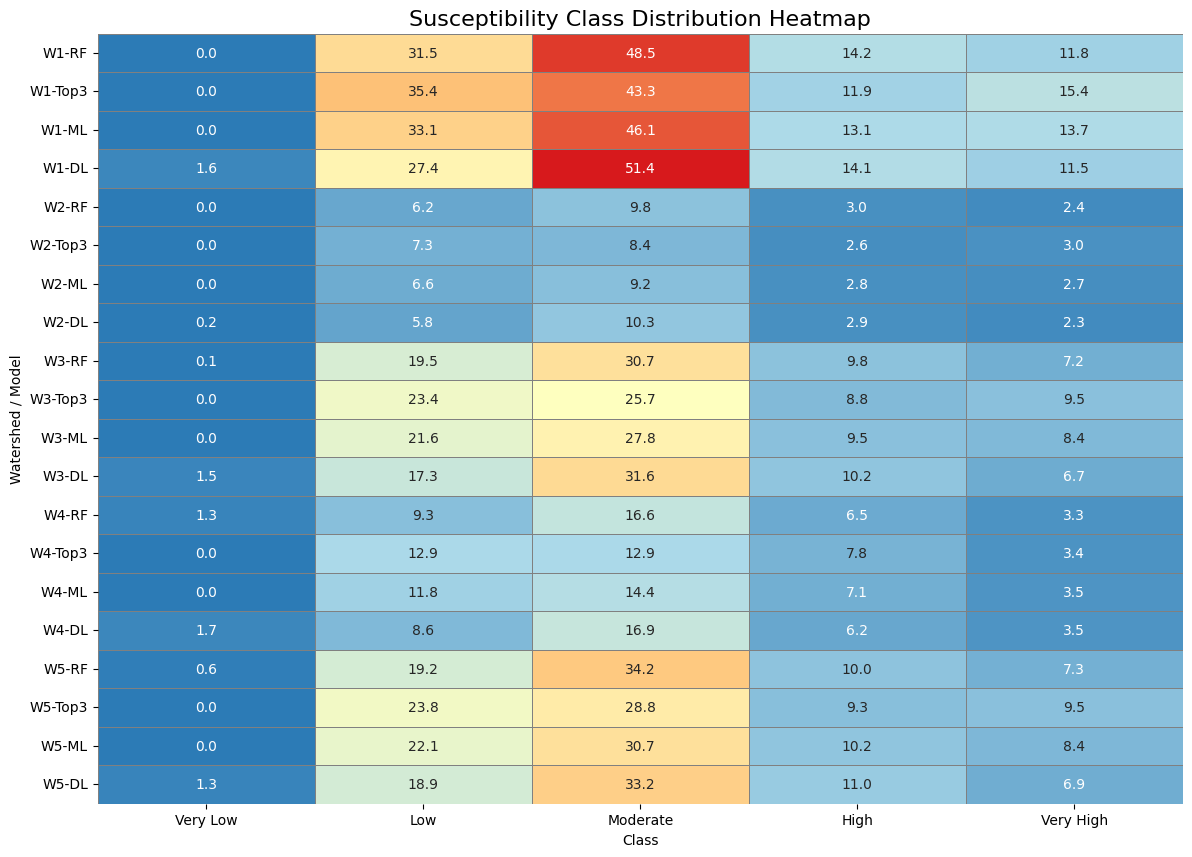

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ----- Data -----
data = {
"Watershed": ["W1"]*4 + ["W2"]*4 + ["W3"]*4 + ["W4"]*4 + ["W5"]*4,
"Model": ["RF","Top3","ML","DL"]*5,
"Very Low":  [0.02,0.00,0.00,1.63, 0.04,0.00,0.00,0.16, 0.09,0.00,0.00,1.54, 1.26,0.00,0.02,1.66, 0.60,0.00,0.00,1.26],
"Low":       [31.54,35.40,33.06,27.35, 6.17,7.32,6.63,5.76, 19.54,23.35,21.61,17.34, 9.30,12.91,11.83,8.60, 19.21,23.79,22.10,18.89],
"Moderate":  [48.45,43.27,46.13,51.43, 9.81,8.37,9.25,10.27, 30.68,25.69,27.80,31.58, 16.56,12.86,14.42,16.95, 34.24,28.78,30.73,33.25],
"High":      [14.21,11.92,13.14,14.05, 2.99,2.63,2.82,2.91, 9.82,8.82,9.48,10.15, 6.46,7.77,7.13,6.20, 10.02,9.28,10.16,11.02],
"Very High": [11.76,15.40,13.66,11.52, 2.35,3.04,2.67,2.26, 7.20,9.46,8.44,6.72, 3.33,3.37,3.52,3.51, 7.29,9.52,8.37,6.92]
}

df = pd.DataFrame(data)

# ----- Heatmap preparation -----
classes = ["Very Low","Low","Moderate","High","Very High"]

df_heat = df.set_index(["Watershed","Model"])[classes]

# Custom colormap
colors = ['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c']
cmap = LinearSegmentedColormap.from_list("custom", colors)

# ----- Plot -----
plt.figure(figsize=(14,10))
sns.heatmap(df_heat, annot=True, cmap=cmap, fmt=".1f",
            cbar=False,  # no legend
            linewidths=0.5, linecolor="gray")

plt.title("Susceptibility Class Distribution Heatmap", fontsize=16)
plt.ylabel("Watershed / Model")
plt.xlabel("Class")

plt.show()
